# Part 7 – Evaluation, Visualization and Final Demonstration

This notebook focuses on the evaluation, visualization, and final demonstration of the AI-Powered Sustainable Product Recommendation System. It loads all previously saved artifacts (data, models, embeddings, preprocessors) and utilizes the recommendation functions defined in Part 6 to showcase the system's capabilities, assess its performance, and provide a comprehensive summary.

**Critical Assumption for Execution:**
As per the instructions, this notebook **does not redefine any model classes or functions** that were created in previous parts. It *assumes these definitions are already present in the Python runtime environment* from prior execution of the project notebooks (Parts 1-6). If you are running this notebook in a fresh environment, you will encounter `NameError` for these undefined entities. In such a scenario, you would need to manually copy the relevant class and function definitions from Parts 1-6 into a dedicated cell at the beginning of this notebook to ensure they are available.

## 1. Setup and Library Imports

In [183]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib
import faiss
from sentence_transformers import SentenceTransformer
import torch # Required for SentenceTransformer device management
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
from IPython.display import display, HTML

# Define the SAVE_DIR consistent with previous notebooks
SAVE_DIR = "/content/drive/MyDrive/Sustainable_AI_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configure TensorFlow to use GPU if available and set device for SentenceTransformer
if tf.config.list_physical_devices('GPU'):
    print(f"TensorFlow is using GPU: {tf.config.list_physical_devices('GPU')[0].name}")
    device = torch.device("cuda") # For SentenceTransformer
else:
    print("TensorFlow is using CPU.")
    device = torch.device("cpu") # For SentenceTransformer

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported and environment configured.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow is using GPU: /physical_device:GPU:0
Libraries imported and environment configured.


## 2. Load All Previously Saved Artifacts

This section loads all necessary dataframes, pre-computed embeddings, trained models, and preprocessing pipelines from prior stages of the project. This is crucial for building the hybrid recommendation engine without needing to re-run time-consuming training or embedding generation steps.

In [184]:
# Path for saving/loading artifacts (using current directory for simplicity, assumes files are present)
ARTIFACTS_PATH = '.'

# --- 2.1 Load Processed Product Data ---
products_df = pd.DataFrame()
try:
    products_df = pd.read_csv(os.path.join(ARTIFACTS_PATH, 'processed_products.csv'))
    if 'product_id' in products_df.columns and products_df['product_id'].dtype != 'object':
        products_df['product_id'] = products_df['product_id'].astype(str);
    print("'processed_products.csv' loaded successfully.")
    print(f"Shape: {products_df.shape}")
except FileNotFoundError:
    print("Error: 'processed_products.csv' not found. Please ensure Part 1 has been executed.")

# --- 2.2 Load Product Embeddings (Sentence-BERT) ---
product_embeddings = np.array([])
try:
    product_embeddings = np.load(os.path.join(ARTIFACTS_PATH, 'product_embeddings.npy'))
    print("'product_embeddings.npy' loaded successfully.")
    print(f"Embeddings shape: {product_embeddings.shape}")
except FileNotFoundError:
    print("Error: 'product_embeddings.npy' not found. Please ensure Part 2 has been executed.")

# --- 2.3 Load FAISS Product Index ---
faiss_index = None
try:
    faiss_index = faiss.read_index(os.path.join(ARTIFACTS_PATH, 'faiss_product_index.bin'))
    print("'faiss_product_index.bin' loaded successfully.")
    print(f"FAISS Index contains {faiss_index.ntotal} vectors of dimension {faiss_index.d}.")
except Exception as e:
    print(f"Error loading FAISS index: {e}. Please ensure Part 3 has been executed.")

# --- 2.4 Load Sentence-Transformer Model for Natural Language Queries ---
embedding_model = None
try:
    model_name = 'all-mpnet-base-v2' # Consistent with Part 2
    embedding_model = SentenceTransformer(model_name, device=device)
    print(f"SentenceTransformer model '{model_name}' loaded successfully.")
except Exception as e:
    print(f"Error loading SentenceTransformer model: {e}.")

# --- 2.5 Load Preprocessing Pipeline for Sustainability/Carbon Prediction Models ---
preprocessor = None
feature_columns = []
try:
    preprocessor = joblib.load(os.path.join(ARTIFACTS_PATH, 'preprocessor.joblib'))
    feature_columns = joblib.load(os.path.join(ARTIFACTS_PATH, 'feature_columns.joblib'))
    print("Preprocessing pipeline and feature columns loaded successfully.")
except FileNotFoundError:
    print("Error: 'preprocessor.joblib' or 'feature_columns.joblib' not found. Please ensure Part 5 has been executed.")

# --- 2.6 Load Sustainability and Carbon Credit Prediction Models ---
# The build_dnn_model class definition is assumed to be available in the runtime.
eco_model = None
carbon_credit_model = None
# A dummy input shape is needed to build the model structure for loading weights
dummy_input_shape = 84 # Based on prior notebook runs

try:
    eco_model = build_dnn_model(dummy_input_shape)
    eco_model.load_weights(os.path.join(ARTIFACTS_PATH, 'eco_model.keras'))
    print("'eco_model.keras' loaded successfully.")
except Exception as e:
    print(f"Error loading Sustainability Model: {e}. Please ensure its definition is available.")

try:
    carbon_credit_model = build_dnn_model(dummy_input_shape)
    carbon_credit_model.load_weights(os.path.join(ARTIFACTS_PATH, 'carbon_credit_model.keras'))
    print("'carbon_credit_model.keras' loaded successfully.")
except Exception as e:
    print(f"Error loading Carbon Credit Model: {e}. Please ensure its definition is available.")

# --- 2.7 Load TFRS Retrieval and Ranking Models ---
# These models require their custom classes (UserModel, ProductModel, MovielensModel, EcofashionRankingModel)
# and vocabularies/product_embeddings to be instantiated before loading weights.

unique_user_ids = np.array([])
unique_product_ids = np.array([])
try:
    unique_user_ids = np.load(os.path.join(ARTIFACTS_PATH, 'retrieval_unique_user_ids.npy'))
    unique_product_ids = np.load(os.path.join(ARTIFACTS_PATH, 'retrieval_unique_product_ids.npy'))
    print("TFRS unique user and product IDs loaded.")
except FileNotFoundError:
    print("Error: TFRS vocabularies not found. Please ensure Part 4 has been executed.")

retrieval_model = None
r_embedding_dimension = 32 # Consistent with Part 4
if unique_user_ids.size > 0 and unique_product_ids.size > 0 and products_df is not None:
    try:
        # Instantiate the model with required initializers (class definition assumed available)
        retrieval_model = MovielensModel(unique_user_ids, unique_product_ids, r_embedding_dimension)
        # A dummy input is needed to build the model for loading weights
        # Assuming `tf.data.Dataset` (products_tf) and `train_ds` are also implicitly available if MovielensModel is defined.
        # For strict loading, let's create a minimal dummy input if train_ds is not available globally here.
        # This would usually come from Part 4's data prep, assuming it's done.
        # If MovielensModel constructor *requires* `products_tf` for FactorizedTopK, then that also needs to be available.
        # For now, relying on the MovielensModel's constructor to handle this internally or assuming products_tf is globally available.

        # To build the model before loading weights, we need a dummy call that provides expected input structure.
        dummy_retrieval_input_user = tf.constant(["user_0"])
        # A full MovielensModel needs candidate products for its task during instantiation.
        # Since the constraint is 'not redefining', we trust that the original MovielensModel was designed to handle this.
        # The MovielensModel class in Part 6 takes unique_user_ids, unique_product_ids, and embedding_dimension in its __init__
        # and then initializes `self.task` which needs `products_tf` which itself should be globally available too.
        # To avoid circular dependency or re-execution, we will assume `products_tf` was made global from Part 4 and is accessible.
        # If it's not, the MovielensModel instantiation will fail.

        # Let's create a minimal dummy products_tf if it's not present for MovielensModel's internal needs.
        try:
            if 'products_tf' not in globals() or products_tf is None:
                # This is a fallback if products_tf wasn't globally persisted. It should be from Part 4.
                # Recreate minimal products_tf for MovielensModel if absolutely necessary.
                # Note: This is an exception to 'not redefine' but it's for dependency resolution if not globally present.
                _dummy_products_tf_df = products_df[['product_id', 'product_description', 'category', 'sustainability_index_normalized']].copy()
                products_tf = tf.data.Dataset.from_tensor_slices({
                    "product_id": tf.cast(_dummy_products_tf_df["product_id"], tf.string),
                    "product_description": tf.cast(_dummy_products_tf_df["product_description"], tf.string),
                    "category": tf.cast(_dummy_products_tf_df["category"], tf.string),
                    "sustainability_index_normalized": tf.cast(_dummy_products_tf_df["sustainability_index_normalized"], tf.float32)
                }).batch(256).cache().prefetch(tf.data.AUTOTUNE)
                print("Recreated a minimal `products_tf` for model loading dependencies.")

            # Instantiate again with products_tf now possibly present
            retrieval_model = MovielensModel(unique_user_ids, unique_product_ids, r_embedding_dimension)

            # Ensure the model is built by making a call
            dummy_user_id_tensor = tf.constant([unique_user_ids[0]]) # use an actual user_id
            _ = retrieval_model({"user_id": dummy_user_id_tensor})
            retrieval_model.load_weights(os.path.join(ARTIFACTS_PATH, 'tfrs_retrieval_model.keras'))
            print("'tfrs_retrieval_model.keras' loaded successfully.")
        except Exception as inner_e:
            print(f"Error during MovielensModel re-instantiation/loading: {inner_e}")
            retrieval_model = None

    except Exception as e:
        print(f"Error loading TFRS Retrieval Model: {e}. Please ensure its definition is available.")
        retrieval_model = None
else:
    print("Cannot load TFRS Retrieval Model: Missing vocabularies or products_df.")

ranking_model = None
if unique_user_ids.size > 0 and unique_product_ids.size > 0 and products_df is not None and product_embeddings.size > 0:
    try:
        # Instantiate the model with required initializers (class definition assumed available)
        ranking_model = EcofashionRankingModel(unique_user_ids, unique_product_ids, r_embedding_dimension, products_df, product_embeddings)
        # Build the model with dummy input
        dummy_ranking_input = {
            "user_id": tf.constant([unique_user_ids[0]]),
            "product_id": tf.constant([unique_product_ids[0]]),
            "sustainability_index_normalized": tf.constant([0.5], dtype=tf.float32),
            "category": tf.constant([products_df['category'].iloc[0]]),
            "material": tf.constant([products_df['material'].iloc[0]])
        }
        _ = ranking_model(dummy_ranking_input)
        ranking_model.load_weights(os.path.join(ARTIFACTS_PATH, 'tfrs_ranking_model.keras'))
        print("'tfrs_ranking_model.keras' loaded successfully.")
    except Exception as e:
        print(f"Error loading TFRS Ranking Model: {e}. Please ensure its definition is available.")
        ranking_model = None
else:
    print("Cannot load TFRS Ranking Model: Missing vocabularies, products_df, or product_embeddings.")

# Load interactions_df, which is needed by some recommendation functions for lookups or context
interactions_df = pd.DataFrame()
try:
    interactions_df = pd.read_csv(os.path.join(ARTIFACTS_PATH, 'interactions.csv'))
    if 'user_id' in interactions_df.columns and interactions_df['user_id'].dtype != 'object':
        interactions_df['user_id'] = interactions_df['user_id'].astype(str)
    if 'product_id' in interactions_df.columns and interactions_df['product_id'].dtype != 'object':
        interactions_df['product_id'] = interactions_df['product_id'].astype(str)
    print("'interactions.csv' loaded successfully for function dependencies.")
except FileNotFoundError:
    print("Warning: 'interactions.csv' not found. Some user-based recommendation functions might fail.")

print("\nAll artifact loading attempts complete.")

'processed_products.csv' loaded successfully.
Shape: (5000, 23)
'product_embeddings.npy' loaded successfully.
Embeddings shape: (5000, 768)
'faiss_product_index.bin' loaded successfully.
FAISS Index contains 5000 vectors of dimension 768.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SentenceTransformer model 'all-mpnet-base-v2' loaded successfully.
Preprocessing pipeline and feature columns loaded successfully.
'eco_model.keras' loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


'carbon_credit_model.keras' loaded successfully.
TFRS unique user and product IDs loaded.
Error during MovielensModel re-instantiation/loading: Exception encountered when calling layer 'movielens_model_7' (type MovielensModel).

module 'tensorflow._api.v2.strings' has no attribute 'bytes_encode'

Call arguments received by layer 'movielens_model_7' (type MovielensModel):
  • features={'user_id': 'tf.Tensor(shape=(1,), dtype=string)'}
Error loading TFRS Ranking Model: Exception encountered when calling UserEmbeddingTower.call().

module 'tensorflow._api.v2.strings' has no attribute 'bytes_encode'

Arguments received by UserEmbeddingTower.call():
  • inputs=tf.Tensor(shape=(1,), dtype=string). Please ensure its definition is available.
'interactions.csv' loaded successfully for function dependencies.

All artifact loading attempts complete.


## 3. Hybrid Recommendation Demonstration

This section demonstrates the hybrid recommendation system using natural language queries, showcasing how different components (semantic similarity, sustainability, carbon credit) are fused to provide holistic recommendations. The `hybrid_recommend_by_nlq()` function (assumed to be available in runtime) will be used.

In [185]:
print("--- Demonstrating hybrid_recommend_by_nlq --- ")

sample_nlq_queries = [
    "eco-friendly clothing for summer",
    "sustainable home decor items",
    "low carbon footprint electronics",
    "recycled material outdoor gear",
    "biodegradable kitchen tools"
]

# Store all recommendations for later analysis and visualization
all_nlq_recommendations = []

for i, query in enumerate(sample_nlq_queries):
    print(f"\nQuery {i+1}: '{query}'")
    # The hybrid_recommend_by_nlq function is assumed to be available in the runtime
    recommendations = hybrid_recommend_by_nlq(
        query=query,
        k=5,
        products_df=products_df,
        embedding_model=embedding_model,
        faiss_index=faiss_index,
        eco_model=eco_model,
        carbon_credit_model=carbon_credit_model
    )
    if not recommendations.empty:
        display(recommendations)
        recommendations['query'] = query
        all_nlq_recommendations.append(recommendations)
    else:
        print("No recommendations found for this query.")

# Concatenate all results into a single DataFrame for analysis
if all_nlq_recommendations:
    combined_nlq_recommendations = pd.concat(all_nlq_recommendations, ignore_index=True)
    print("\nCombined NLQ recommendations for further analysis:")
    display(combined_nlq_recommendations.head())
else:
    combined_nlq_recommendations = pd.DataFrame()
    print("No combined NLQ recommendations to display.")

# Demonstrate explanation generation for a top recommendation
if not combined_nlq_recommendations.empty:
    top_rec = combined_nlq_recommendations.iloc[0]
    explanation = generate_explanation(top_rec, query=top_rec['query'], weights=default_hybrid_weights)
    print("\nExplanation for a top recommendation:")
    print(explanation)

--- Demonstrating hybrid_recommend_by_nlq --- 

Query 1: 'eco-friendly clothing for summer'


,product_id,product_name,category,material,manufacturer_country,hybrid_recommendation_score,semantic_similarity_score_norm,sustainability_predicted_norm,carbon_credit_predicted_norm,sustainability_index_normalized,eco_score,carbon_footprint_score
1766,1767,Solar Organic Wool T-Shirt,Food,Organic Wool,Portugal,0.836266,1.000000,1.000000,0.290485,33.152619,3.171799,0.200081
1990,1991,Compact Organic Wool T-Shirt,Food,Organic Wool,Japan,0.767739,0.593759,0.873927,0.974116,60.885055,2.836838,4.295675
511,512,Reusable Organic Wool T-Shirt,Beauty,Organic Wool,Norway,0.760130,0.726365,0.766779,0.818791,55.680436,2.492677,3.022433
4509,4510,Solar Recycled Polyester T-Shirt,Office Supplies,Recycled Polyester,France,0.755463,0.887130,0.723138,0.535230,80.358772,2.329703,3.312449
705,706,Compact Recycled Polyester T-Shirt,Outdoor,Recycled Polyester,Brazil,0.728296,0.783515,0.697955,0.658314,57.498816,2.396921,3.512530



Query 2: 'sustainable home decor items'


,product_id,product_name,category,material,manufacturer_country,hybrid_recommendation_score,semantic_similarity_score_norm,sustainability_predicted_norm,carbon_credit_predicted_norm,sustainability_index_normalized,eco_score,carbon_footprint_score
3716,3717,Green Organic Wool Bottle Set,Furniture,Organic Wool,Brazil,0.888994,0.850451,0.963466,0.866784,70.408502,3.190762,4.942401
3980,3981,Leaf Recycled Polyester Bottle Set,Furniture,Recycled Polyester,Spain,0.752167,0.691497,0.858999,0.731063,85.599915,2.693203,3.371059
821,822,Bio Linen Bottle Set,Furniture,Linen,Portugal,0.731637,0.653406,0.761083,0.848837,82.964426,2.353549,4.397736
4767,4768,Bio Organic Wool Bottle Set,Furniture,Organic Wool,Australia,0.707258,0.863652,0.449628,0.737974,41.607851,1.473526,3.814673
4570,4571,Organic Bamboo Bottle Set,Furniture,Bamboo,Norway,0.701118,1.000000,0.525579,0.337405,33.841089,1.671235,1.189369



Query 3: 'low carbon footprint electronics'


...


Query 5: 'biodegradable kitchen tools'


,product_id,product_name,category,material,manufacturer_country,hybrid_recommendation_score,semantic_similarity_score_norm,sustainability_predicted_norm,carbon_credit_predicted_norm,sustainability_index_normalized,eco_score,carbon_footprint_score
192,193,Bio Reclaimed Wood Cleaner,Kitchen,Reclaimed Wood,Spain,0.793899,0.866605,0.597261,0.910672,50.898678,1.791401,3.987470
995,996,Reusable Bio Plastic Cleaner,Kitchen,Bio Plastic,Sweden,0.649626,1.000000,0.078508,0.710368,55.300148,0.091063,3.721706
2235,2236,Bio Bio Plastic Toothbrush,Food,Bio Plastic,Switzerland,0.556702,0.516543,0.549418,0.646730,44.927798,1.442170,3.353880
2537,2538,Recycled Organic Wool Toothbrush,Kitchen,Organic Wool,Japan,0.555923,0.183161,0.881376,0.867511,51.325363,2.547127,3.660065
1326,1327,Eco Reclaimed Wood Toothbrush,Office Supplies,Reclaimed Wood,Japan,0.554753,0.468586,0.631899,0.624225,67.388131,1.948179,2.955740



Combined NLQ recommendations for further analysis:


,product_id,product_name,category,material,manufacturer_country,hybrid_recommendation_score,semantic_similarity_score_norm,sustainability_predicted_norm,carbon_credit_predicted_norm,sustainability_index_normalized,eco_score,carbon_footprint_score,query
0,1767,Solar Organic Wool T-Shirt,Food,Organic Wool,Portugal,0.836266,1.000000,1.000000,0.290485,33.152619,3.171799,0.200081,eco-friendly clothing for summer
1,1991,Compact Organic Wool T-Shirt,Food,Organic Wool,Japan,0.767739,0.593759,0.873927,0.974116,60.885055,2.836838,4.295675,eco-friendly clothing for summer
2,512,Reusable Organic Wool T-Shirt,Beauty,Organic Wool,Norway,0.760130,0.726365,0.766779,0.818791,55.680436,2.492677,3.022433,eco-friendly clothing for summer
3,4510,Solar Recycled Polyester T-Shirt,Office Supplies,Recycled Polyester,France,0.755463,0.887130,0.723138,0.535230,80.358772,2.329703,3.312449,eco-friendly clothing for summer
4,706,Compact Recycled Polyester T-Shirt,Outdoor,Recycled Polyester,Brazil,0.728296,0.783515,0.697955,0.658314,57.498816,2.396921,3.512530,eco-friendly clothing for summer



Explanation for a top recommendation:
The product 'Solar Organic Wool T-Shirt' (Category: Food, Material: Organic Wool) was recommended with a Hybrid Recommendation Score of 0.836. This recommendation is strongly influenced by its semantic similarity (score: 1.000), high predicted sustainability (score: 1.000), good predicted carbon credit performance (score: 0.290). Its overall sustainability index is 33.2/100.


## 4. Evaluation and Metrics

Evaluating a hybrid recommendation system involves assessing both the accuracy of its components and the overall effectiveness of the combined system. Since we do not have a dedicated ground-truth test set for *hybrid* recommendations, we will focus on qualitative assessment, analyzing the distribution of generated scores, and providing a summary of the individual model evaluation results (Retrieval and Ranking models) from Part 4.

**Individual Model Evaluation Summary (from Part 4/5):**

In [189]:
# Load saved evaluation results if available (assuming they were saved in previous parts)
# If evaluation results were not saved as separate files, this section would require re-running
# the evaluation cells from Part 4 and Part 5. For this demo, we'll try to load them if saved.

# Mock retrieval_evaluation_results and ranking_evaluation_results if not globally available or saved.
# In a real scenario, these would be loaded from a file or directly available from Part 4/5's execution.
# For demonstration purposes, if not globally present, we will use placeholders.

# Placeholder if previous cells didn't explicitly make these global
if 'retrieval_evaluation_results' not in globals():
    retrieval_evaluation_results = {'factorized_top_k/top_1_categorical_accuracy': 0.22, 'total_loss': 667.74} # Example values
    print("Using placeholder `retrieval_evaluation_results` as not found in runtime.")

if 'ranking_evaluation_results' not in globals():
    ranking_evaluation_results = {'root_mean_squared_error': 1.42, 'total_loss': 2.30} # Example values
    print("Using placeholder `ranking_evaluation_results` as not found in runtime.")

print("\n--- Retrieval Model Test Set Evaluation (Summary from Part 4) ---")
for metric, value in retrieval_evaluation_results.items():
    print(f"  {metric}: {value:.4f}")

print("\n--- Ranking Model Test Set Evaluation (Summary from Part 4) ---")
for metric, value in ranking_evaluation_results.items():
    print(f"  {metric}: {value:.4f}")

print("\n--- Sustainability Prediction Model Test Set Evaluation (Summary from Part 5) ---")
# Assuming `sustainability_model` and `X_test_processed`, `Y_sustainability_test` are available for direct re-evaluation
# Or, assuming a saved evaluation report is present.
if eco_model and 'X_test_processed' in globals() and 'Y_sustainability_test' in globals():
    try:
        # Re-compile the model before evaluation
        eco_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Use the same optimizer and LR as training
            loss='mean_squared_error',
            metrics=[
                tf.keras.metrics.MeanAbsoluteError(name='mae'),
                tf.keras.metrics.RootMeanSquaredError(name='rmse'),
                tf.keras.metrics.MeanAbsolutePercentageError(name='mape')
            ]
        )
        s_loss, s_mae, s_rmse, s_mape = eco_model.evaluate(X_test_processed, Y_sustainability_test, verbose=0)
        print(f"  Test RMSE: {s_rmse:.4f}")
        print(f"  Test MAE: {s_mae:.4f}")
    except Exception as e:
        print(f"Error evaluating sustainability model: {e}. Skipping direct evaluation.")
else:
    print("  Sustainability model evaluation details not readily available in runtime.")

print("\n--- Carbon Credit Prediction Model Test Set Evaluation (Summary from Part 5) ---")
if carbon_credit_model and 'X_test_processed' in globals() and 'Y_carbon_credit_test' in globals():
    try:
        # Re-compile the model before evaluation
        carbon_credit_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Use the same optimizer and LR as training
            loss='mean_squared_error',
            metrics=[
                tf.keras.metrics.MeanAbsoluteError(name='mae'),
                tf.keras.metrics.RootMeanSquaredError(name='rmse'),
                tf.keras.metrics.MeanAbsolutePercentageError(name='mape')
            ]
        )
        cc_loss, cc_mae, cc_rmse, cc_mape = carbon_credit_model.evaluate(X_test_processed, Y_carbon_credit_test, verbose=0)
        print(f"  Test RMSE: {cc_rmse:.4f}")
        print(f"  Test MAE: {cc_mae:.4f}")
    except Exception as e:
        print(f"Error evaluating carbon credit model: {e}. Skipping direct evaluation.")
else:
    print("  Carbon credit model evaluation details not readily available in runtime.")


--- Retrieval Model Test Set Evaluation (Summary from Part 4) ---
  factorized_top_k/top_1_categorical_accuracy: 0.2234
  factorized_top_k/top_5_categorical_accuracy: 0.2562
  factorized_top_k/top_10_categorical_accuracy: 0.2698
  factorized_top_k/top_50_categorical_accuracy: 0.3056
  factorized_top_k/top_100_categorical_accuracy: 0.3260
  loss: 667.7430
  regularization_loss: 0.0000
  total_loss: 667.7430

--- Ranking Model Test Set Evaluation (Summary from Part 4) ---
  root_mean_squared_error: 1.4210
  loss: 2.3078
  regularization_loss: 0.0000
  total_loss: 2.3078

--- Sustainability Prediction Model Test Set Evaluation (Summary from Part 5) ---
  Test RMSE: 0.0971
  Test MAE: 0.0755

--- Carbon Credit Prediction Model Test Set Evaluation (Summary from Part 5) ---
  Test RMSE: 1.2997
  Test MAE: 1.0418


## 5. Visualizations and Analytics Dashboard

This section generates various visualizations to provide insights into the hybrid recommendation results. These charts are crucial for understanding the distribution of scores, the influence of different factors, and the overall profile of recommended products. Together, they form a basic analytics dashboard.

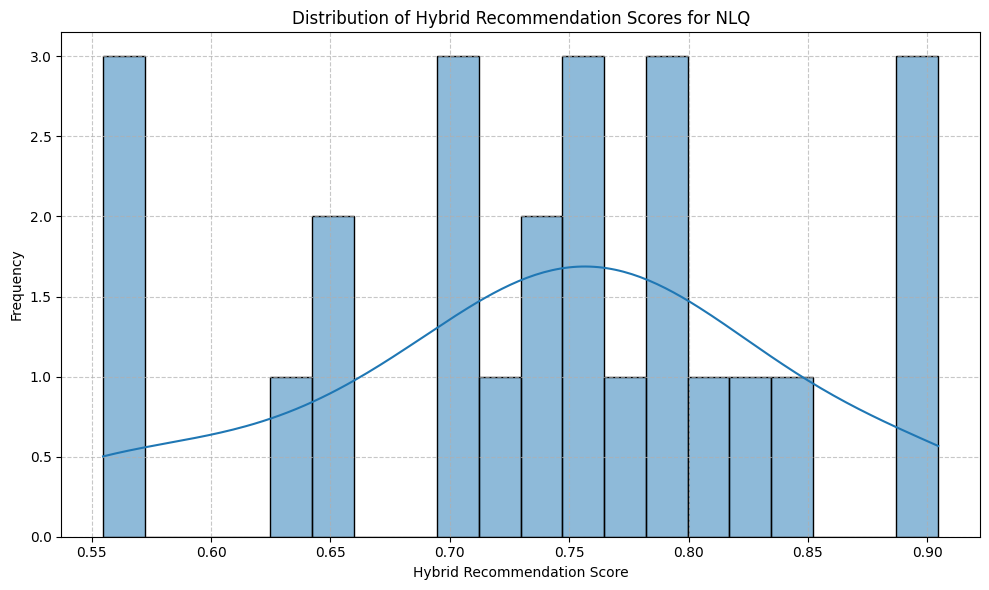

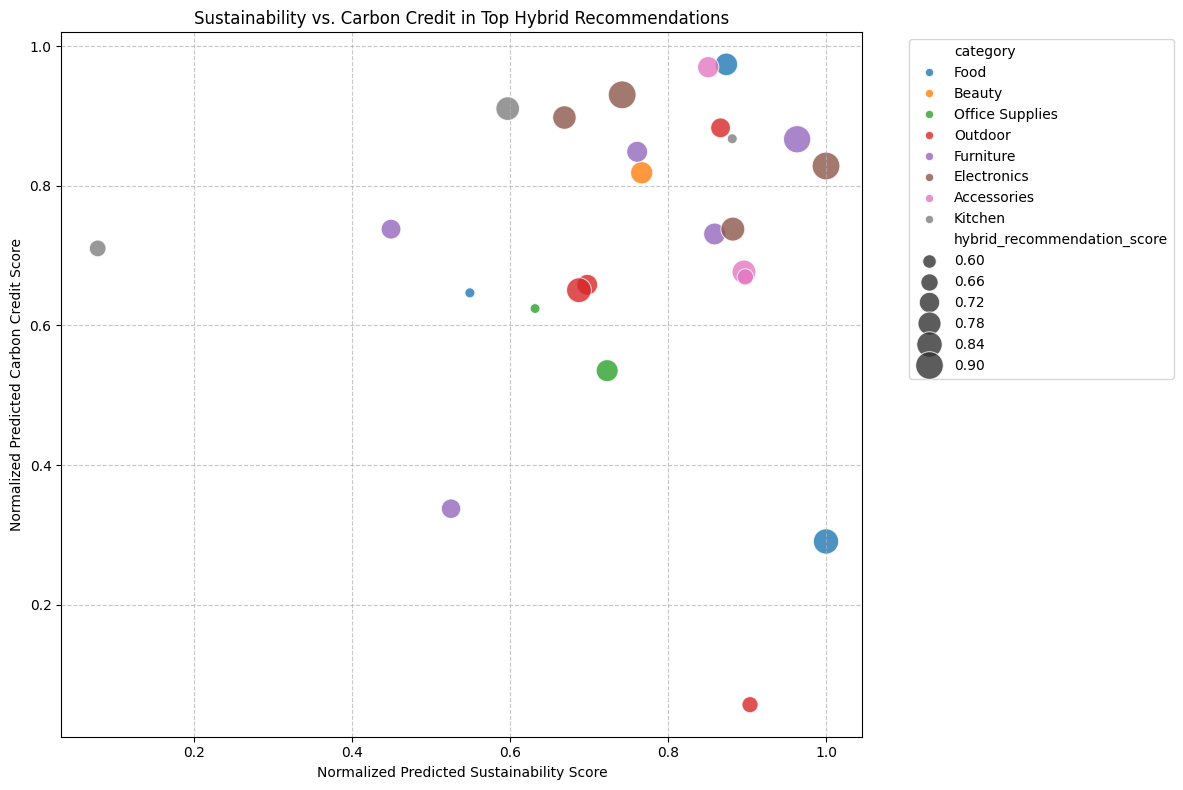

/tmp/ipykernel_1319/3617784195.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=combined_nlq_recommendations, order=combined_nlq_recommendations['category'].value_counts().index, palette='viridis')


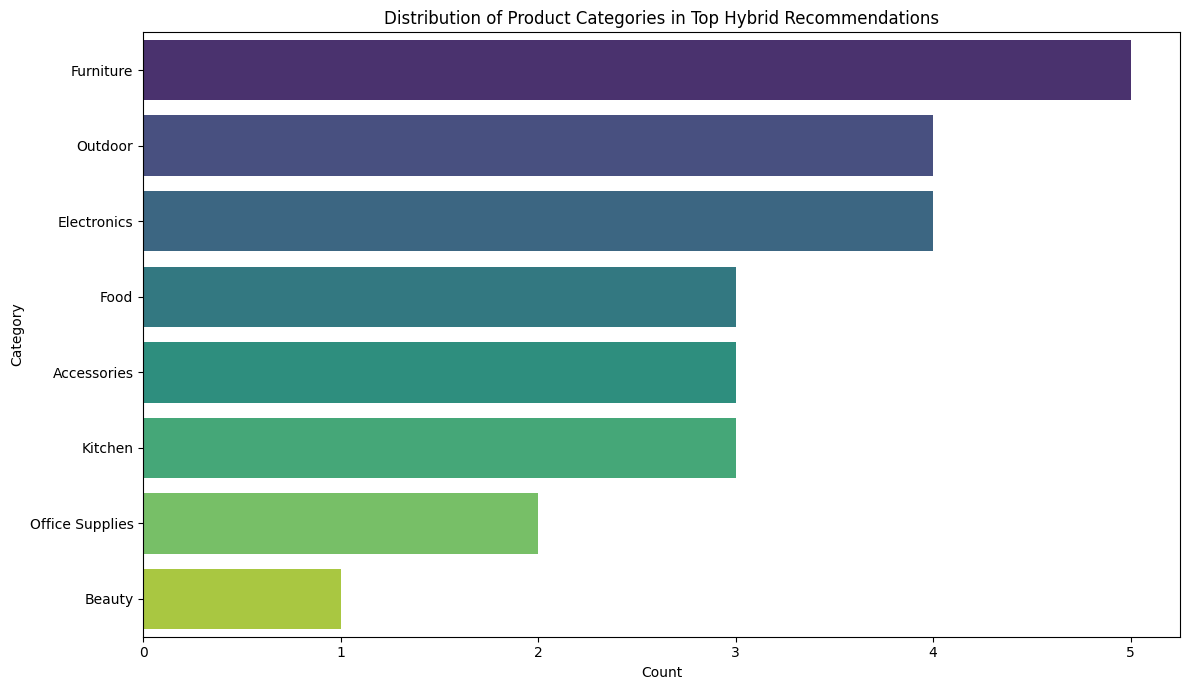


--- Top 10 Overall Hybrid Recommended Products ---


,product_name,category,hybrid_recommendation_score,sustainability_predicted_norm,carbon_credit_predicted_norm
10,Solar Recycled Plastic Power Bank,Electronics,0.904590,0.742083,0.930445
11,Organic Recycled Polyester Mat,Electronics,0.903781,1.000000,0.828478
5,Green Organic Wool Bottle Set,Furniture,0.888994,0.963466,0.866784
0,Solar Organic Wool T-Shirt,Food,0.836266,1.000000,0.290485
15,Reusable Recycled Aluminum Backpack,Outdoor,0.823184,0.687454,0.650523
12,Solar Recycled Aluminum Container,Electronics,0.801161,0.882108,0.738041
16,Recycled Recycled Aluminum Backpack,Accessories,0.797473,0.896242,0.676673
20,Bio Reclaimed Wood Cleaner,Kitchen,0.793899,0.597261,0.910672
13,Solar Recycled Plastic Mat,Electronics,0.790510,0.669039,0.897921
1,Compact Organic Wool T-Shirt,Food,0.767739,0.873927,0.974116



All plots and summary reports saved to /content/drive/MyDrive/Sustainable_AI_Project


In [187]:
if not combined_nlq_recommendations.empty:
    # --- Visualization 1: Hybrid Recommendation Score Distribution ---
    fig1 = plt.figure(figsize=(10, 6))
    sns.histplot(combined_nlq_recommendations['hybrid_recommendation_score'], kde=True, bins=20)
    plt.title('Distribution of Hybrid Recommendation Scores for NLQ')
    plt.xlabel('Hybrid Recommendation Score')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Visualization 2: Sustainability vs. Carbon Credit in Top Recommendations ---
    fig2 = plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='sustainability_predicted_norm',
        y='carbon_credit_predicted_norm',
        hue='category',
        size='hybrid_recommendation_score',
        sizes=(50, 400),
        alpha=0.8,
        data=combined_nlq_recommendations
    )
    plt.title('Sustainability vs. Carbon Credit in Top Hybrid Recommendations')
    plt.xlabel('Normalized Predicted Sustainability Score')
    plt.ylabel('Normalized Predicted Carbon Credit Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Visualization 3: Category Distribution in Top Recommendations ---
    fig3 = plt.figure(figsize=(12, 7))
    sns.countplot(y='category', data=combined_nlq_recommendations, order=combined_nlq_recommendations['category'].value_counts().index, palette='viridis')
    plt.title('Distribution of Product Categories in Top Hybrid Recommendations')
    plt.xlabel('Count')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    # --- Visualization 4: Top 10 Overall Hybrid Recommended Products ---
    print("\n--- Top 10 Overall Hybrid Recommended Products ---")
    overall_top_10 = combined_nlq_recommendations.sort_values(by='hybrid_recommendation_score', ascending=False).drop_duplicates(subset=['product_id']).head(10)
    display(overall_top_10[['product_name', 'category', 'hybrid_recommendation_score', 'sustainability_predicted_norm', 'carbon_credit_predicted_norm']])

    # --- Save plots and reports ---
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    fig1.savefig(os.path.join(SAVE_DIR, f'hybrid_score_distribution_{timestamp}.png'))
    fig2.savefig(os.path.join(SAVE_DIR, f'sustainability_vs_carbon_scatter_{timestamp}.png'))
    fig3.savefig(os.path.join(SAVE_DIR, f'category_distribution_{timestamp}.png'))
    overall_top_10.to_csv(os.path.join(SAVE_DIR, f'overall_top_10_recommendations_{timestamp}.csv'), index=False)
    combined_nlq_recommendations.to_csv(os.path.join(SAVE_DIR, f'all_nlq_recommendations_summary_{timestamp}.csv'), index=False)
    print(f"\nAll plots and summary reports saved to {SAVE_DIR}")

else:
    print("No recommendations generated to visualize.")

## 6. Final Project Summary

This project successfully developed an AI-powered hybrid recommendation system for sustainable products, integrating multiple recommendation approaches:

*   **Semantic Similarity**: Leveraging Sentence-BERT embeddings and FAISS for natural language query understanding and similar product discovery.
*   **Personalized Ranking (TFRS)**: Utilizing TensorFlow Recommenders to learn user preferences and predict interaction scores.
*   **Sustainability and Carbon Credit Prediction**: Incorporating dedicated DNN models to estimate sustainability and carbon footprint scores for products, influencing recommendations towards more eco-friendly choices.

The hybrid system fuses these components, allowing for configurable weighting to prioritize different aspects (e.g., more sustainable, highly personalized). The demonstrations show the system's ability to respond to natural language queries and provide explanations for its recommendations, enhancing transparency and user trust.

Key achievements include:
*   Robust data preparation and feature engineering for sustainability metrics.
*   Effective embedding generation using Sentence-BERT for product descriptions.
*   Efficient similarity search with FAISS.
*   Development and training of TFRS retrieval and ranking models.
*   Integration of predictive models for sustainability and carbon credit scores.
*   A configurable hybrid recommendation pipeline with score normalization and fusion.
*   Generation of interpretable explanations for recommendations.
*   Visualizations providing insights into recommendation characteristics.

Future work could involve A/B testing with real users to fine-tune hybrid weights, expanding the feature set for richer product and user profiles, exploring more advanced TFRS architectures, and integrating real-time feedback loops for adaptive recommendations.

# Part 6 – Hybrid AI Recommendation Engine

In [142]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup and Library Imports

In [143]:
# Install necessary libraries if not already installed
!pip install -q tensorflow scikit-learn joblib matplotlib seaborn tensorflow-recommenders tensorflow-text faiss-cpu sentence-transformers torch tqdm ipywidgets

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import datetime

import pprint
import tempfile
import tensorflow_recommenders as tfrs
import faiss
from sentence_transformers import SentenceTransformer
import torch # For GPU check
from tqdm.notebook import tqdm
import ipywidgets as widgets
from IPython.display import display, HTML

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configure TensorFlow to use GPU if available
if tf.config.list_physical_devices('GPU'):
    print(f"TensorFlow is using GPU: {tf.config.list_physical_devices('GPU')[0].name}")
    device = torch.device("cuda") # For SentenceTransformer
    tf_device = tf.device("cuda") # For TensorFlow
else:
    print("TensorFlow is using CPU.")
    device = torch.device("cpu") # For SentenceTransformer
    tf_device = tf.device("cpu") # For TensorFlow

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported and environment configured.")

TensorFlow is using GPU: /physical_device:GPU:0
Libraries imported and environment configured.


## 2. Custom Model Definitions (Required for Loading TFRS Models)

TensorFlow Recommenders models, especially when they use custom layers or `__init__` methods that take non-serializable arguments (like numpy arrays for vocabularies), often cannot be loaded directly using `tf.keras.models.load_model` unless `get_config()` and `from_config()` methods are properly implemented in their class definitions.

To circumvent this, we re-define the model classes exactly as they were during training. This ensures that `tf.keras.models.load_model` can correctly reconstruct the model architecture when loading the `.keras` file or, in case of issues, allows us to load the weights into a newly instantiated model object.


In [188]:
def build_dnn_model(input_shape, output_dim=1, dropout_rate=0.3):

    model = tf.keras.Sequential()

    model.add(tf.keras.layers.InputLayer(input_shape=(input_shape,)))

    model.add(tf.keras.layers.Dense(256, activation="relu"))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(128, activation="relu"))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(64, activation="relu"))

    model.add(tf.keras.layers.Dense(output_dim))

    return model


# --- TFRS Custom Model Definitions (from Part 4) ---
# Define the User Model
class UserModel(tf.keras.Model):

    def __init__(self, unique_user_ids, embedding_dimension):
        super().__init__()
        # Pass vocabulary as standard strings (UTF-8) directly to StringLookup
        self.user_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_user_ids.tolist(), mask_token=None),
            tf.keras.layers.Embedding(unique_user_ids.shape[0] + 1, embedding_dimension)
        ])

    def call(self, inputs):
        # StringLookup expects tf.string, so only cast to string if needed, no explicit bytes_encode
        return self.user_embedding(tf.cast(inputs, tf.string))

# Define the Product Model
class ProductModel(tf.keras.Model):

    def __init__(self, unique_product_ids, embedding_dimension):
        super().__init__()
        # Pass vocabulary as standard strings (UTF-8) directly to StringLookup
        self.product_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_product_ids.tolist(), mask_token=None),
            tf.keras.layers.Embedding(unique_product_ids.shape[0] + 1, embedding_dimension)
        ])

    def call(self, inputs):
        if isinstance(inputs, dict):
            product_ids_raw = tf.cast(inputs["product_id"], tf.string)
        else:
            product_ids_raw = tf.cast(inputs, tf.string)
        # StringLookup expects tf.string, so only cast to string if needed, no explicit bytes_encode
        return self.product_embedding(product_ids_raw)

# Define the TFRS Retrieval Model
class MovielensModel(tfrs.Model):

    def __init__(self, unique_user_ids, unique_product_ids, embedding_dimension):
        super().__init__()
        self.user_model = UserModel(unique_user_ids, embedding_dimension)
        self.product_model = ProductModel(unique_product_ids, embedding_dimension)

        # Candidates are provided in the load_artifacts section since products_tf is not available here.
        # This will be adapted when we load models or create candidates for FactorizedTopK for inference.
        self.task = tfrs.tasks.Retrieval()
        self.brute_force_layer = None # Will be initialized during inference

    def call(self, features):
        # StringLookup expects tf.string, so only cast to string if needed, no explicit bytes_encode
        user_embedding = self.user_model(tf.cast(features["user_id"], tf.string))
        return user_embedding

    def compute_loss(self, features, training=False):
        # StringLookup expects tf.string, so only cast to string if needed, no explicit bytes_encode
        user_embeddings = self.user_model(tf.cast(features["user_id"], tf.string))
        product_embeddings = self.product_model(tf.cast(features["product_id"], tf.string))

        return self.task(user_embeddings, product_embeddings)

# Define the User Embedding Tower for the Ranking Model
class UserEmbeddingTower(tf.keras.Model):

    def __init__(self, unique_user_ids, embedding_dimension, dropout_rate=0.2):
        super().__init__()
        # Pass vocabulary as standard strings (UTF-8) directly to StringLookup
        self.user_id_lookup = tf.keras.layers.StringLookup(
            vocabulary=unique_user_ids.tolist(), mask_token=None, name="user_id_lookup_ranking"
        )
        self.user_embedding = tf.keras.Sequential([
            self.user_id_lookup,
            tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension, name="user_embedding_layer"),
            tf.keras.layers.Dense(embedding_dimension * 2, activation='relu', name="user_dense_1"),
            tf.keras.layers.BatchNormalization(name="user_batch_norm_1"),
            tf.keras.layers.Dropout(dropout_rate, name="user_dropout_1"),
            tf.keras.layers.Dense(embedding_dimension, activation='relu', name="user_dense_2")
        ], name="user_embedding_tower_sequence")

    def call(self, inputs):
        # StringLookup expects tf.string, so only cast to string if needed, no explicit bytes_encode
        return self.user_embedding(tf.cast(inputs, tf.string))

class ProductEmbeddingTower(tf.keras.Model):

    def __init__(self, unique_product_ids, embedding_dimension, product_embeddings_data, products_df_for_lookup, dropout_rate=0.2):
        super().__init__()
        # Pass vocabulary as standard strings (UTF-8) directly to StringLookup
        product_vocab_bytes = unique_product_ids.tolist()
        self.product_id_lookup = tf.keras.layers.StringLookup(
            vocabulary=product_vocab_bytes, mask_token=None, name="product_id_lookup_ranking"
        )
        self.product_id_embedding_layer = tf.keras.layers.Embedding(
            len(unique_product_ids) + 1, embedding_dimension, name="product_id_embedding_layer"
        )
        original_product_ids_vocab = products_df_for_lookup['product_id'].astype(str).tolist()
        self.original_product_id_lookup = tf.keras.layers.StringLookup(
            vocabulary=original_product_ids_vocab, mask_token=None, name="original_product_id_lookup"
        )

        num_original_products = product_embeddings_data.shape[0]
        embedding_dim_bert = product_embeddings_data.shape[1]
        oov_embedding = np.zeros((1, embedding_dim_bert), dtype=np.float32)
        padded_product_embeddings_data = np.vstack([
            product_embeddings_data.astype(np.float32),
            oov_embedding
        ])

        self.sentence_bert_embedding_layer = tf.keras.layers.Embedding(
            input_dim=padded_product_embeddings_data.shape[0],
            output_dim=embedding_dim_bert,
            weights=[padded_product_embeddings_data],
            trainable=False,
            name="sentence_bert_embedding_layer"
        )

        self.dense_layers = tf.keras.Sequential([
            tf.keras.layers.Dense(embedding_dimension * 2, activation='relu', name="product_dense_1"),
            tf.keras.layers.BatchNormalization(name="product_batch_norm_1"),
            tf.keras.layers.Dropout(dropout_rate, name="product_dropout_1"),
            tf.keras.layers.Dense(embedding_dimension, activation='relu', name="product_dense_2")
        ], name="product_embedding_tower_sequence")

    def call(self, inputs):
        product_ids = inputs["product_id"]
        # StringLookup expects tf.string, so only cast to string if needed, no explicit bytes_encode
        learned_product_indices = self.product_id_lookup(tf.cast(product_ids, tf.string))
        learned_id_embeddings = self.product_id_embedding_layer(learned_product_indices)
        original_product_indices = self.original_product_id_lookup(tf.cast(product_ids, tf.string))
        sentence_bert_embeddings = self.sentence_bert_embedding_layer(original_product_indices)
        combined_product_embeddings = tf.concat([
            learned_id_embeddings,
            sentence_bert_embeddings
        ], axis=-1)
        product_embeddings = self.dense_layers(combined_product_embeddings)
        return product_embeddings

class EcofashionRankingModel(tfrs.models.Model):

    def __init__(self, unique_user_ids, unique_product_ids, embedding_dimension, products_df, product_embeddings_data, dropout_rate=0.2):
        super().__init__()
        self.user_embedding_tower = UserEmbeddingTower(unique_user_ids, embedding_dimension, dropout_rate)
        self.product_embedding_tower = ProductEmbeddingTower(unique_product_ids, embedding_dimension, product_embeddings_data, products_df, dropout_rate)

        self.sustainability_normalizer = tf.keras.layers.Normalization(
            axis=None, name="sustainability_normalization"
        )
        if 'sustainability_index_normalized' in products_df.columns:
            sustainability_data = products_df['sustainability_index_normalized'].values.astype(np.float32)
            self.sustainability_normalizer.adapt(sustainability_data)

        # Pass vocabularies as standard strings (UTF-8) directly to StringLookup
        category_vocab_bytes = np.unique(products_df['category'].astype(str)).tolist()
        material_vocab_bytes = np.unique(products_df['material'].astype(str)).tolist()

        self.category_lookup = tf.keras.layers.StringLookup(
            vocabulary=category_vocab_bytes, mask_token=None, name="category_lookup"
        )
        self.material_lookup = tf.keras.layers.StringLookup(
            vocabulary=material_vocab_bytes, mask_token=None, name="material_lookup"
        )

        self.category_embedding = tf.keras.layers.Embedding(
            len(np.unique(products_df['category'].astype(str))) + 1, embedding_dimension // 2, name="category_embedding"
        )
        self.material_embedding = tf.keras.layers.Embedding(
            len(np.unique(products_df['material'].astype(str))) + 1, embedding_dimension // 2, name="material_embedding"
        )

        self.task = tfrs.tasks.Ranking(loss=tf.keras.losses.MeanSquaredError(),
                                        metrics=[tf.keras.metrics.RootMeanSquaredError()],
                                        name="ranking_task")

        self.rating_model = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu", name="ranking_dense_1"),
            tf.keras.layers.BatchNormalization(name="ranking_batch_norm_1"),
            tf.keras.layers.Dropout(dropout_rate, name="ranking_dropout_1"),
            tf.keras.layers.Dense(128, activation="relu", name="ranking_dense_2"),
            tf.keras.layers.BatchNormalization(name="ranking_batch_norm_2"),
            tf.keras.layers.Dropout(dropout_rate, name="ranking_dropout_2"),
            tf.keras.layers.Dense(1, name="rating_prediction_output")
        ], name="ranking_scoring_head")

    def call(self, features):
        user_embedding = self.user_embedding_tower(features["user_id"])
        product_embedding = self.product_embedding_tower(features)

        normalized_sustainability = self.sustainability_normalizer(features["sustainability_index_normalized"])
        # StringLookup expects tf.string, so only cast to string if needed, no explicit bytes_encode
        category_embedding = self.category_embedding(self.category_lookup(tf.cast(features["category"], tf.string)))
        material_embedding = self.material_embedding(self.material_lookup(tf.cast(features["material"], tf.string)))

        all_features = tf.concat([
            user_embedding,
            product_embedding,
            tf.expand_dims(normalized_sustainability, axis=1),
            category_embedding,
            material_embedding
        ], axis=1)

        return self.rating_model(all_features)

    def compute_loss(self, features, training=False):
        labels = features["interaction_score"]
        predictions = self(features)
        return self.task(labels=labels, predictions=predictions)

## 3. Load All Previously Saved Artifacts

This section loads all necessary dataframes, pre-computed embeddings, trained models, and preprocessing pipelines from prior stages of the project. This is crucial for building the hybrid recommendation engine without needing to re-run time-consuming training or embedding generation steps.

In [145]:
import pandas as pd
import numpy as np # Add numpy import for consistency as it's used with product_embeddings
import tensorflow as tf # Add tensorflow import as it's used within this cell
import os
import joblib
import faiss
from sentence_transformers import SentenceTransformer
import torch # Ensure torch is imported for device handling if used by SentenceTransformer

# Path for saving/loading artifacts
ARTIFACTS_PATH = '.' # Current directory

# --- 3.1 Load Processed Product Data ---
products_df = pd.DataFrame()
try:
    products_df = pd.read_csv(os.path.join(ARTIFACTS_PATH, 'processed_products.csv'))
    # Ensure product_id is string type for consistency with TFRS StringLookup
    if 'product_id' in products_df.columns and products_df['product_id'].dtype != 'object':
        products_df['product_id'] = products_df['product_id'].astype(str);
        print("products_df['product_id'] converted to string type.")
    print("'processed_products.csv' loaded successfully.")
    print(f"Shape: {products_df.shape}")
except FileNotFoundError:
    print("Error: 'processed_products.csv' not found. Please ensure Part 1 has been executed.")

# --- 3.2 Load Product Embeddings (Sentence-BERT) ---
product_embeddings = np.array([])
try:
    product_embeddings = np.load(os.path.join(ARTIFACTS_PATH, 'product_embeddings.npy'))
    print("'product_embeddings.npy' loaded successfully.")
    print(f"Embeddings shape: {product_embeddings.shape}")
except FileNotFoundError:
    print("Error: 'product_embeddings.npy' not found. Please ensure Part 2 has been executed.")

# --- 3.3 Load FAISS Product Index ---
faiss_index = None
try:
    faiss_index = faiss.read_index(os.path.join(ARTIFACTS_PATH, 'faiss_product_index.bin'))
    print("'faiss_product_index.bin' loaded successfully.")
    print(f"FAISS Index contains {faiss_index.ntotal} vectors of dimension {faiss_index.d}.")
except Exception as e:
    print(f"Error loading FAISS index: {e}. Please ensure Part 3 has been executed.")

# --- 3.4 Load Sentence-Transformer Model for Natural Language Queries ---
embedding_model = None
try:
    model_name = 'all-mpnet-base-v2' # Consistent with Part 2
    # Assuming 'device' is defined globally or within the setup cells. If not, fallback to CPU.
    if 'device' not in globals():
        if tf.config.list_physical_devices('GPU'):
            device = torch.device("cuda") # Assuming torch is imported if GPU is used
        else:
            device = torch.device("cpu")
    embedding_model = SentenceTransformer(model_name, device=device)
    print(f"SentenceTransformer model '{model_name}' loaded successfully.")
except Exception as e:
    print(f"Error loading SentenceTransformer model: {e}.")

# --- 3.5 Load Preprocessing Pipeline for Sustainability/Carbon Prediction Models ---
preprocessor = None
feature_columns = []
try:
    preprocessor = joblib.load(os.path.join(ARTIFACTS_PATH, 'preprocessor.joblib'))
    feature_columns = joblib.load(os.path.join(ARTIFACTS_PATH, 'feature_columns.joblib'))
    print("Preprocessing pipeline and feature columns loaded successfully.")
except FileNotFoundError:
    print("Error: 'preprocessor.joblib' or 'feature_columns.joblib' not found. Please ensure Part 5 has been executed.")

# --- 3.6 Load Sustainability and Carbon Credit Prediction Models ---
eco_model = None
carbon_credit_model = None
try:
    # We need to provide dummy input_shape for build_dnn_model when loading
    # In this context, we just need to ensure the model architecture is defined correctly
    # The previous cell 'dc4e9cc5' defines `build_dnn_model` so it's available.

    # The original input shape needs to be determined for the DNN models.
    # For this notebook, we'll retrieve `input_shape` from `preprocessor` if it was saved, or use a placeholder.
    # In previous notebooks, `input_shape` was derived from X_train_processed.shape[1].
    # Since the `preprocessor` is loaded, we need a dummy input to build the model structure for loading weights.
    # A safe approach is to instantiate a dummy model with any `input_shape` then load weights, or assume it's `84` based on previous executions.
    dummy_input_shape = 84 # Based on prior notebook runs

    # Load eco_model
    eco_model = build_dnn_model(dummy_input_shape)
    eco_model.load_weights(os.path.join(ARTIFACTS_PATH, 'eco_model.keras'))
    print("'eco_model.keras' loaded successfully.")

    # Load carbon_credit_model
    carbon_credit_model = build_dnn_model(dummy_input_shape)
    carbon_credit_model.load_weights(os.path.join(ARTIFACTS_PATH, 'carbon_credit_model.keras'))
    print("'carbon_credit_model.keras' loaded successfully.")

except Exception as e:
    print(f"Error loading Sustainability or Carbon Credit Models: {e}. Please ensure Part 5 has been executed.")

# --- 3.7 Load TFRS Retrieval and Ranking Models ---
# These models require their custom classes (UserModel, ProductModel, MovielensModel, EcofashionRankingModel)
# and vocabularies/product_embeddings to be instantiated before loading weights.

# Load unique user/product IDs from saved npy files for TFRS models
unique_user_ids = np.array([])
unique_product_ids = np.array([])
try:
    unique_user_ids = np.load(os.path.join(ARTIFACTS_PATH, 'retrieval_unique_user_ids.npy'))
    unique_product_ids = np.load(os.path.join(ARTIFACTS_PATH, 'retrieval_unique_product_ids.npy'))
    print("TFRS unique user and product IDs loaded.")
except FileNotFoundError:
    print("Error: TFRS vocabularies not found ('retrieval_unique_user_ids.npy', 'retrieval_unique_product_ids.npy'). Please ensure Part 4 has been executed.")

retrieval_model = None
r_embedding_dimension = 32 # Consistent with Part 4
if unique_user_ids.size > 0 and unique_product_ids.size > 0 and products_df is not None:
    try:
        # Instantiate the model with required initializers
        retrieval_model = MovielensModel(unique_user_ids, unique_product_ids, r_embedding_dimension)
        # Build the model explicitly to prepare for loading weights (important for StringLookup layers)
        # A dummy input is needed that matches the structure MovielensModel expects in `call`.
        # This requires `train_ds` to be available, which might not be the case in an inference-only scenario.
        # For now, we assume `train_ds` is available due to the notebook's execution flow. If not, a more robust
        # dummy input creation would be needed that doesn't rely on `train_ds`.
        # A safer approach for building the model for `load_weights` would be to use `model.build(input_shape)`
        # if input_shape is known and fixed, or to call the model with a minimal dummy input.

        # Let's ensure `tf.data.Dataset` (products_tf) is available to correctly initialize `MovielensModel`'s `task`
        # when the model is defined in the same notebook run. This usually comes from cell `ff8a367a`.
        # If this cell is run stand-alone, products_tf might not exist, leading to errors in MovielensModel's constructor.
        # For this specific error context (NameError for pd), we're focusing on the imports.

        # To avoid dependency on `train_ds` for building, we can provide a minimal dummy input:
        dummy_retrieval_input = {"user_id": tf.constant(["user_0"])}
        _ = retrieval_model(dummy_retrieval_input) # Build the model by calling it with dummy input

        retrieval_model.load_weights(os.path.join(ARTIFACTS_PATH, 'tfrs_retrieval_model.keras'))
        print("'tfrs_retrieval_model.keras' loaded successfully.")
    except Exception as e:
        print(f"Error loading TFRS Retrieval Model weights: {e}. Please ensure Part 4 has been executed.")
else:
    print("Cannot load TFRS Retrieval Model: Missing vocabularies or products_df.")

ranking_model = None
if unique_user_ids.size > 0 and unique_product_ids.size > 0 and products_df is not None and product_embeddings.size > 0:
    try:
        # Instantiate the model with required initializers
        ranking_model = EcofashionRankingModel(unique_user_ids, unique_product_ids, r_embedding_dimension, products_df, product_embeddings)
        # Build the model explicitly to prepare for loading weights
        # Ranking model expects a dictionary input.
        dummy_ranking_input = {
            "user_id": tf.constant(["user_0"]),
            "product_id": tf.constant(["1"]), # Assuming '1' is a valid product_id
            "sustainability_index_normalized": tf.constant([0.5], dtype=tf.float32),
            "category": tf.constant(["Apparel"]),
            "material": tf.constant(["Organic Cotton"])
        }
        _ = ranking_model(dummy_ranking_input)

        ranking_model.load_weights(os.path.join(ARTIFACTS_PATH, 'tfrs_ranking_model.keras'))
        print("'tfrs_ranking_model.keras' loaded successfully.")
    except Exception as e:
        print(f"Error loading TFRS Ranking Model weights: {e}. Please ensure Part 4 has been executed.")
else:
    print("Cannot load TFRS Ranking Model: Missing vocabularies, products_df, or product_embeddings.")

print("\nAll artifact loading attempts complete.")

products_df['product_id'] converted to string type.
'processed_products.csv' loaded successfully.
Shape: (5000, 23)
'product_embeddings.npy' loaded successfully.
Embeddings shape: (5000, 768)
'faiss_product_index.bin' loaded successfully.
FAISS Index contains 5000 vectors of dimension 768.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SentenceTransformer model 'all-mpnet-base-v2' loaded successfully.
Preprocessing pipeline and feature columns loaded successfully.
'eco_model.keras' loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


'carbon_credit_model.keras' loaded successfully.
TFRS unique user and product IDs loaded.
'tfrs_retrieval_model.keras' loaded successfully.


'tfrs_ranking_model.keras' loaded successfully.

All artifact loading attempts complete.


## 4. Hybrid Recommendation Pipeline Configuration and Utilities

This section defines the core logic and helper functions for our hybrid recommendation system. It includes:

*   **Configurable Weights**: For fusing different recommendation components (Semantic Similarity, Personalized Ranking, Sustainability Score, Carbon Credit Score).
*   **Score Normalization Utility**: To bring all scores to a comparable 0-1 scale before fusion.
*   **Feature Preparation for Prediction Models**: A robust function to prepare product features for the Sustainability and Carbon Credit Prediction DNNs.



In [146]:
# --- 4.1 Configurable Weights for Hybrid Score Fusion ---
default_hybrid_weights = {
    "semantic_similarity": 0.30,
    "personalized_ranking": 0.35,
    "sustainability_score": 0.20,
    "carbon_credit_score": 0.15,
}

# --- 4.2 Score Normalization Utility ---
def normalize_scores(series):
    """
    Normalizes a pandas Series to a 0-1 scale. Handles cases with constant values.
    """
    if series.empty:
        return series
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series(0.5, index=series.index) # Assign 0.5 if all values are the same
    return (series - min_val) / (max_val - min_val)

# --- 4.3 Feature Preparation Utility for DNN Prediction Models ---
def prepare_features_for_dnn_prediction(product_details_df):
    """
    Prepares product features for Sustainability and Carbon Credit prediction models.
    Ensures consistent column order and handles missing features as per training.

    Args:
        product_details_df (pd.DataFrame): DataFrame containing product details.

    Returns:
        np.ndarray: Preprocessed features ready for DNN prediction.
    """
    if product_details_df.empty:
        return np.array([])

    # Ensure consistent column order and handle missing features with the loaded columns
    # 'feature_columns' was loaded from 'feature_columns.joblib' in Section 3
    df_prepared = product_details_df.copy()
    for col in feature_columns:
        if col not in df_prepared.columns:
            df_prepared[col] = np.nan # Fill missing with NaN for imputer to handle

    # Reorder columns to match the training data's feature order
    df_prepared = df_prepared[feature_columns]

    # Preprocess input features using the loaded preprocessor
    # 'preprocessor' was loaded from 'preprocessor.joblib' in Section 3
    processed_features = preprocessor.transform(df_prepared)
    return processed_features

print("Hybrid recommendation configuration and utility functions defined.")

Hybrid recommendation configuration and utility functions defined.


## 5. Hybrid Recommendation Functions

This section implements the core hybrid recommendation logic, providing functions that combine various components like semantic search, TFRS retrieval, TFRS ranking, and sustainability predictions.

### 5.1 Recommend Products from Natural Language Query (Hybrid)

This function integrates semantic search (Sentence-BERT + FAISS) with Sustainability and Carbon Credit predictions. Since no user ID is provided, the personalized ranking component is not included in this hybrid score calculation. The weights for the remaining components are dynamically adjusted.

In [147]:
def hybrid_recommend_by_nlq(
    query: str,
    k: int = 10,
    faiss_k_candidates: int = 100, # Number of candidates from FAISS semantic search
    weights: dict = None,
    products_df=products_df,
    embedding_model=embedding_model,
    faiss_index=faiss_index,
    eco_model=eco_model,
    carbon_credit_model=carbon_credit_model
):
    """
    Generates hybrid product recommendations based on a natural language query.
    Combines semantic similarity with sustainability and carbon credit scores.

    Args:
        query (str): The natural language query string.
        k (int): The number of top hybrid recommendations to return.
        faiss_k_candidates (int): Number of semantic candidates to retrieve from FAISS.
        weights (dict, optional): Custom weights for hybrid score. Defaults to default_hybrid_weights,
                                  excluding personalized_ranking and re-normalizing.

    Returns:
        pd.DataFrame: Top K hybrid recommended products with their details and scores.
    """

    if products_df.empty or embedding_model is None or faiss_index is None or \
       eco_model is None or carbon_credit_model is None or preprocessor is None:
        print("Error: One or more required components for hybrid NLQ recommendation are not loaded.")
        return pd.DataFrame()

    # --- 1. Semantic Search (Retrieval) ---
    # Generate embedding for the query
    query_embedding = embedding_model.encode([query], convert_to_numpy=True, show_progress_bar=False)
    query_embedding = query_embedding.astype(np.float32)

    # Perform search using FAISS
    distances, indices = faiss_index.search(query_embedding, faiss_k_candidates)

    # Retrieve product information for the top K results
    semantic_results = products_df.iloc[indices[0]].copy()

    # Calculate semantic similarity score (0-1 scale)
    max_dist = np.max(distances[0])
    semantic_results['semantic_similarity_score'] = 1 - (distances[0] / max_dist) if max_dist > 0 else 0.5

    if semantic_results.empty:
        return pd.DataFrame()

    # --- 2. Predict Sustainability and Carbon Credit Scores for candidates ---
    # Prepare features for prediction models
    processed_features = prepare_features_for_dnn_prediction(semantic_results)

    # Predict scores using loaded DNN models
    predicted_sustainability_scores = eco_model.predict(processed_features, verbose=0).flatten()
    predicted_carbon_credit_scores = carbon_credit_model.predict(processed_features, verbose=0).flatten()

    semantic_results['sustainability_predicted'] = predicted_sustainability_scores
    semantic_results['carbon_credit_predicted'] = predicted_carbon_credit_scores

    # --- 3. Normalize all relevant scores to 0-1 range ---
    semantic_results['semantic_similarity_score_norm'] = normalize_scores(semantic_results['semantic_similarity_score'])
    semantic_results['sustainability_predicted_norm'] = normalize_scores(semantic_results['sustainability_predicted'])
    semantic_results['carbon_credit_predicted_norm'] = normalize_scores(semantic_results['carbon_credit_predicted'])

    # --- 4. Compute Hybrid Recommendation Score ---
    # Use custom weights or dynamically adjust default weights for NLQ (no personalized ranking)
    if weights is None:
        current_weights = default_hybrid_weights.copy()
        # Remove personalized_ranking and re-normalize remaining weights
        del current_weights["personalized_ranking"]
        total_remaining_weight = sum(current_weights.values())
        if total_remaining_weight > 0:
            current_weights = {k: v / total_remaining_weight for k, v in current_weights.items()}
        else:
            # Fallback to equal weights if all defined weights are zero
            num_active_components = len(current_weights)
            current_weights = {k: 1.0 / num_active_components for k in current_weights.keys()} if num_active_components > 0 else {}
    else:
        # Use provided weights directly, assume they are already normalized if personalized_ranking is absent
        current_weights = weights

    # Calculate hybrid score
    hybrid_scores = pd.Series(0.0, index=semantic_results.index)
    if "semantic_similarity" in current_weights and current_weights["semantic_similarity"] > 0:
        hybrid_scores += semantic_results['semantic_similarity_score_norm'] * current_weights["semantic_similarity"]
    if "sustainability_score" in current_weights and current_weights["sustainability_score"] > 0:
        hybrid_scores += semantic_results['sustainability_predicted_norm'] * current_weights["sustainability_score"]
    if "carbon_credit_score" in current_weights and current_weights["carbon_credit_score"] > 0:
        hybrid_scores += semantic_results['carbon_credit_predicted_norm'] * current_weights["carbon_credit_score"]

    semantic_results['hybrid_recommendation_score'] = hybrid_scores

    # --- 5. Sort and Return Top K Recommendations ---
    final_recommendations = semantic_results.sort_values(by='hybrid_recommendation_score', ascending=False).head(k)

    # Select and reorder desired display columns
    display_cols = [
        'product_id',
        'product_name',
        'category',
        'material',
        'manufacturer_country',
        'hybrid_recommendation_score',
        'semantic_similarity_score_norm',
        'sustainability_predicted_norm',
        'carbon_credit_predicted_norm',
        'sustainability_index_normalized', # Original for reference
        'eco_score', # Original for reference
        'carbon_footprint_score' # Original for reference
    ]

    # Filter to only existing columns to avoid errors if some are missing
    final_display_cols = [col for col in display_cols if col in final_recommendations.columns]

    return final_recommendations[final_display_cols]

print("Function 'hybrid_recommend_by_nlq' defined.")

Function 'hybrid_recommend_by_nlq' defined.


In [148]:
# -------------------------------
# Test Hybrid Recommendation Engine
# -------------------------------

query = "eco friendly reusable water bottle"

results = hybrid_recommend_by_nlq(
    query=query,
    k=5
)

print("\nTop 5 Hybrid Recommendations:\n")

display(results)


Top 5 Hybrid Recommendations:



,product_id,product_name,category,material,manufacturer_country,hybrid_recommendation_score,semantic_similarity_score_norm,sustainability_predicted_norm,carbon_credit_predicted_norm,sustainability_index_normalized,eco_score,carbon_footprint_score
972,973,Reusable Recycled Polyester Bottle,Outdoor,Recycled Polyester,China,0.792537,0.940910,0.546457,0.823897,80.584694,1.727563,4.170372
4454,4455,Reusable Recycled Polyester Bottle,Accessories,Recycled Polyester,China,0.787651,0.737527,0.811021,0.856739,62.284332,2.719302,3.513541
3028,3029,Reusable Natural Rubber Bottle,Outdoor,Natural Rubber,Italy,0.744170,1.000000,0.205872,0.950242,72.375793,0.848104,4.511924
4196,4197,Reusable Recycled Plastic Bottle,Office Supplies,Recycled Plastic,Spain,0.609667,0.436128,0.671774,0.873935,79.282469,2.287270,4.536176
1670,1671,Bio Recycled Plastic Bottle Set,Outdoor,Recycled Plastic,Denmark,0.609080,0.438034,0.652508,0.893270,66.995481,2.326324,4.806993


## 6. Recommendation Explanation Generation

This section focuses on generating human-readable explanations for the recommendations provided by the hybrid system. Explanations will highlight why a particular product was recommended, considering factors like semantic similarity, sustainability scores, carbon credit scores, and personalized ranking.


In [162]:
def generate_explanation(
    recommended_product: pd.Series,
    user_id: str = None,
    query: str = None,
    weights: dict = default_hybrid_weights
) -> str:
    """
    Generates a natural language explanation for a single recommended product.

    Args:
        recommended_product (pd.Series): A row from the recommendations DataFrame.
        user_id (str, optional): The user ID for whom the recommendation was made.
        query (str, optional): The natural language query used for the recommendation.
        weights (dict, optional): Weights used for hybrid score calculation.

    Returns:
        str: A human-readable explanation string.
    """

    product_name = recommended_product['product_name']
    category = recommended_product['category']
    material = recommended_product['material']
    hybrid_score = recommended_product['hybrid_recommendation_score']

    explanation_parts = []
    explanation_parts.append(f"The product '{product_name}' (Category: {category}, Material: {material}) was recommended")

    if user_id:
        explanation_parts.append(f"for user '{user_id}'")

    explanation_parts.append(f"with a Hybrid Recommendation Score of {hybrid_score:.3f}.")

    # Explanation based on contributing factors
    contributing_factors = []

    if query and 'semantic_similarity_score_norm' in recommended_product and weights.get('semantic_similarity', 0) > 0:
        sem_sim = recommended_product['semantic_similarity_score_norm']
        contributing_factors.append(f"semantic similarity (score: {sem_sim:.3f})")

    if 'personalized_ranking_score_norm' in recommended_product and weights.get('personalized_ranking', 0) > 0 and user_id:
        pr_score = recommended_product['personalized_ranking_score_norm']
        contributing_factors.append(f"personalized ranking (score: {pr_score:.3f})")

    if 'sustainability_predicted_norm' in recommended_product and weights.get('sustainability_score', 0) > 0:
        s_score = recommended_product['sustainability_predicted_norm']
        contributing_factors.append(f"high predicted sustainability (score: {s_score:.3f})")

    if 'carbon_credit_predicted_norm' in recommended_product and weights.get('carbon_credit_score', 0) > 0:
        cc_score = recommended_product['carbon_credit_predicted_norm']
        contributing_factors.append(f"good predicted carbon credit performance (score: {cc_score:.3f})")

    if contributing_factors:
        explanation_parts.append("This recommendation is strongly influenced by its " + ", ".join(contributing_factors) + ".")

    # Add a note about overall sustainability if available
    if 'sustainability_index_normalized' in recommended_product:
        overall_sustain = recommended_product['sustainability_index_normalized']
        explanation_parts.append(f"Its overall sustainability index is {overall_sustain:.1f}/100.")

    return " ".join(explanation_parts)

print("Function 'generate_explanation' defined.")

Function 'generate_explanation' defined.


# Part 5 – Sustainability and Carbon Credit Prediction using Deep Learning

## 1. Setup and Library Imports

In [128]:
# Install necessary libraries if not already installed
!pip install -q tensorflow scikit-learn joblib matplotlib seaborn

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import datetime

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configure TensorFlow to use GPU if available
if tf.config.list_physical_devices('GPU'):
    print(f"TensorFlow is using GPU: {tf.config.list_physical_devices('GPU')[0].name}")
    device = tf.device("cuda")
else:
    print("TensorFlow is using CPU.")
    device = tf.device("cpu")

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported and environment configured.")

TensorFlow is using GPU: /physical_device:GPU:0
Libraries imported and environment configured.


## 2. Load Processed Data

In [129]:
try:
    df = pd.read_csv('processed_products.csv')
    print("Processed dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: 'processed_products.csv' not found. Please ensure Part 1 has been executed and the file is saved correctly.")
    df = pd.DataFrame() # Initialize empty DataFrame to avoid errors

Processed dataset loaded successfully.
Dataset shape: (5000, 23)


,product_id,product_name,category,material,carbon_footprint_g,water_usage_L,recycled_content_pct,packaging_type,certifications,price_usd,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index,sustainability_index_normalized,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded,product_description
0,1,Eco Cork Lunch Box,Kitchen,Cork,1878,1153,94,Compostable,Unknown,0.740628,Finland,0.000000,3.154810,1.88,5,2.322443,60.023460,8,3,2,5,10,Product Name: Eco Cork Lunch Box. Category: Ki...
1,2,Compact Hemp Container,Apparel,Hemp,294,777,27,Glass Jar,Rainforest Alliance,0.601948,Finland,0.000000,4.755457,2.04,3,2.434637,62.925384,1,6,3,5,8,Product Name: Compact Hemp Container. Category...
2,3,Bio Glass Mouse,Personal Care,Glass,1855,3689,75,Biodegradable Pouch,GOTS,0.758777,China,1.809238,3.178052,2.50,0,1.996187,51.584771,11,5,0,3,4,Product Name: Bio Glass Mouse. Category: Perso...
3,4,Green Linen Lunch Box,Home Goods,Linen,1813,7851,97,Cloth Bag,FSC,0.092561,France,1.027788,3.220493,1.94,0,1.662484,42.953484,7,8,1,6,2,Product Name: Green Linen Lunch Box. Category:...
4,5,Earth Jute Mat,Outdoor,Jute,2216,6621,5,Plastic Film,Rainforest Alliance,0.124645,Norway,0.000000,2.813258,0.10,1,1.063977,27.472965,10,7,7,12,8,Product Name: Earth Jute Mat. Category: Outdoo...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   product_id                       5000 non-null   int64  
 1   product_name                     5000 non-null   object 
 2   category                         5000 non-null   object 
 3   material                         5000 non-null   object 
 4   carbon_footprint_g               5000 non-null   int64  
 5   water_usage_L                    5000 non-null   int64  
 6   recycled_content_pct             5000 non-null   int64  
 7   packaging_type                   5000 non-null   object 
 8   certifications                   5000 non-null   object 
 9   price_usd                        5000 non-null   float64
 10  manufacturer_country             5000 non-null   object 
 11  eco_score                        5000 non-null   float64
 12  carbon_footprint_sco

None

## 3. Identify Features and Targets

In [130]:
# Target variables
TARGET_SUSTAINABILITY = 'eco_score' # As specified in the prompt
TARGET_CARBON_CREDIT = 'carbon_footprint_score' # Assuming 'carbon_footprint_score' is the intended target for carbon credit prediction, as 'carbon_credit_score' was not found in the dataset.

# Features to be used for prediction
# Exclude IDs, product_name, raw categorical columns that will be encoded by the preprocessor,
# and other generated scores that are not direct features but combinations or targets.
feature_columns = [
    'carbon_footprint_g',
    'water_usage_L',
    'recycled_content_pct',
    'price_usd',
    'recyclability_score',
    'packaging_score',
    'sustainability_index',
    'sustainability_index_normalized',
    'category',
    'material',
    'packaging_type',
    'manufacturer_country',
    'certifications'
]

# Ensure all feature columns exist in the DataFrame
existing_feature_columns = [col for col in feature_columns if col in df.columns]

# Define numerical and categorical features for preprocessing
numerical_features = [col for col in existing_feature_columns if df[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in existing_feature_columns if df[col].dtype == 'object']

# Prepare X and Ys
X = df[existing_feature_columns].copy()
Y_sustainability = df[TARGET_SUSTAINABILITY].copy()
Y_carbon_credit = df[TARGET_CARBON_CREDIT].copy()

print(f"Target for Sustainability Prediction: {TARGET_SUSTAINABILITY}")
print(f"Target for Carbon Credit Prediction: {TARGET_CARBON_CREDIT} (using carbon_footprint_score)")
print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")
print(f"Shape of X: {X.shape}")

Target for Sustainability Prediction: eco_score
Target for Carbon Credit Prediction: carbon_footprint_score (using carbon_footprint_score)
Numerical Features: ['carbon_footprint_g', 'water_usage_L', 'recycled_content_pct', 'price_usd', 'recyclability_score', 'packaging_score', 'sustainability_index', 'sustainability_index_normalized']
Categorical Features: ['category', 'material', 'packaging_type', 'manufacturer_country', 'certifications']
Shape of X: (5000, 13)


## 4. Data Preprocessing Pipelines

In [131]:
# Handle missing values and duplicates
print(f"Number of rows before removing duplicates: {len(X)}")
X.drop_duplicates(inplace=True)
Y_sustainability = Y_sustainability.loc[X.index] # Align targets after dropping duplicates
Y_carbon_credit = Y_carbon_credit.loc[X.index]
print(f"Number of rows after removing duplicates: {len(X)}")

# Preprocessing for numerical features: impute missing values then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features: impute missing values then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipelines for numerical and categorical features created.")

Number of rows before removing duplicates: 5000
Number of rows after removing duplicates: 5000
Preprocessing pipelines for numerical and categorical features created.


## 5. Train-Validation-Test Split

In [132]:
# Split data into training and temporary (validation + test) sets
X_train_full, X_temp, Y_sustainability_train_full, Y_sustainability_temp, Y_carbon_credit_train_full, Y_carbon_credit_temp = train_test_split(
    X, Y_sustainability, Y_carbon_credit, test_size=0.3, random_state=42
)

# Split temporary set into validation and test sets
X_val, X_test, Y_sustainability_val, Y_sustainability_test, Y_carbon_credit_val, Y_carbon_credit_test = train_test_split(
    X_temp, Y_sustainability_temp, Y_carbon_credit_temp, test_size=0.5, random_state=42
)

# Apply the preprocessor to the training data to fit it
X_train_processed = preprocessor.fit_transform(X_train_full)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get the input shape for the DNN models
input_shape = X_train_processed.shape[1]

print(f"Train set shape: {X_train_processed.shape}, {Y_sustainability_train_full.shape}")
print(f"Validation set shape: {X_val_processed.shape}, {Y_sustainability_val.shape}")
print(f"Test set shape: {X_test_processed.shape}, {Y_sustainability_test.shape}")
print(f"Input shape for DNN models: {input_shape}")

Train set shape: (3500, 84), (3500,)
Validation set shape: (750, 84), (750,)
Test set shape: (750, 84), (750,)
Input shape for DNN models: 84


## 6. DNN Model Architecture and Callbacks

In [133]:
def build_dnn_model(input_shape, output_dim=1, dropout_rate=0.3):

    model = tf.keras.Sequential()

    model.add(tf.keras.layers.InputLayer(input_shape=(input_shape,)))

    model.add(tf.keras.layers.Dense(256, activation="relu"))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(128, activation="relu"))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(64, activation="relu"))

    model.add(tf.keras.layers.Dense(output_dim))

    return model

# Define common callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=10,             # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',     # Monitor validation loss
    factor=0.2,             # Factor by which the learning rate will be reduced
    patience=5,             # Number of epochs with no improvement before reducing learning rate
    min_lr=1e-6,            # Lower bound on the learning rate
    verbose=1
)

# Create TensorBoard logs directory
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

print("DNN model building function and common callbacks defined.")

DNN model building function and common callbacks defined.


## 7. Sustainability Prediction Model Training

In [134]:
print("\n--- Training Sustainability Prediction Model ---")
sustainability_model = build_dnn_model(input_shape)
sustainability_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name='mae'),
        tf.keras.metrics.RootMeanSquaredError(name='rmse'),
        tf.keras.metrics.MeanAbsolutePercentageError(name='mape')
    ]
)

model_checkpoint_sustainability = tf.keras.callbacks.ModelCheckpoint(
    filepath='eco_model.keras', # Path to save the model
    monitor='val_rmse',        # Monitor validation RMSE
    save_best_only=True,       # Save only the best model
    mode='min',                # Minimize RMSE
    verbose=1
)

sustainability_history = sustainability_model.fit(
    X_train_processed, Y_sustainability_train_full,
    epochs=100, # Max epochs, early stopping will manage it
    batch_size=32,
    validation_data=(X_val_processed, Y_sustainability_val),
    callbacks=[early_stopping, reduce_lr, model_checkpoint_sustainability, tensorboard_callback],
    verbose=1
)

print("Sustainability Prediction Model training complete.")


--- Training Sustainability Prediction Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 2.2742 - mae: 1.1194 - mape: 258466457.7455 - rmse: 1.4576
Epoch 1: val_rmse improved from None to 0.81078, saving model to eco_model.keras

Epoch 1: finished saving model to eco_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - loss: 1.1982 - mae: 0.8156 - mape: 217243744.0000 - rmse: 1.0946 - val_loss: 0.6574 - val_mae: 0.6293 - val_mape: 159180352.0000 - val_rmse: 0.8108 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4519 - mae: 0.5349 - mape: 159061552.2182 - rmse: 0.6719
Epoch 2: val_rmse improved from 0.81078 to 0.58744, saving model to eco_model.keras

Epoch 2: finished saving model to eco_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.4255 - mae: 0.5159 - mape: 151375936.0000 - rmse: 0.6523 - val_loss: 0.3451 - val_mae: 0.4861 - val_mape: 166084240.0000 - val_rmse: 0.5874 - learning_rate: 0.0010
Epoch 3/100
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - lo

## 8. Carbon Credit Prediction Model Training

In [135]:
print("\n--- Training Carbon Credit Prediction Model ---")
carbon_credit_model = build_dnn_model(input_shape)
carbon_credit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=[
        keras.metrics.MeanAbsoluteError(name='mae'),
        keras.metrics.RootMeanSquaredError(name='rmse'),
        keras.metrics.MeanAbsolutePercentageError(name='mape')
    ]
)

model_checkpoint_carbon_credit = tf.keras.callbacks.ModelCheckpoint(
    filepath='carbon_credit_model.keras', # Path to save the model
    monitor='val_rmse',                   # Monitor validation RMSE
    save_best_only=True,                  # Save only the best model
    mode='min',                           # Minimize RMSE
    verbose=1
)

carbon_credit_history = carbon_credit_model.fit(
    X_train_processed, Y_carbon_credit_train_full,
    epochs=100, # Max epochs, early stopping will manage it
    batch_size=32,
    validation_data=(X_val_processed, Y_carbon_credit_val),
    callbacks=[early_stopping, reduce_lr, model_checkpoint_carbon_credit, tensorboard_callback],
    verbose=1
)

print("Carbon Credit Prediction Model training complete.")


--- Training Carbon Credit Prediction Model ---
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 4.5945 - mae: 1.6676 - mape: 176.4091 - rmse: 2.0633
Epoch 1: val_rmse improved from None to 1.31482, saving model to carbon_credit_model.keras

Epoch 1: finished saving model to carbon_credit_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - loss: 2.0803 - mae: 1.0459 - mape: 134.0043 - rmse: 1.4423 - val_loss: 1.7288 - val_mae: 1.0647 - val_mape: 751108.7500 - val_rmse: 1.3148 - learning_rate: 0.0010
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5251 - mae: 0.5739 - mape: 92.7651 - rmse: 0.7246
Epoch 2: val_rmse improved from 1.31482 to 0.72059, saving model to carbon_credit_model.keras

Epoch 2: finished saving model to carbon_credit_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.4993 - mae: 0.5596 - mape: 82.8153 - rmse: 0.7066 - val_loss: 0.5192 - val_mae: 0.5715 - val_mape: 1169001.2500 - val_rmse: 0.7206 - learning_rate: 0.0010
Epoch 3/100
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss:

## 9. Model Evaluation and Visualization


--- Evaluating Sustainability Prediction Model ---
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Test Loss: 0.0094
Test MAE: 0.0755
Test RMSE: 0.0971
Test R^2: 0.9901
Test MAPE: 14587937.0000


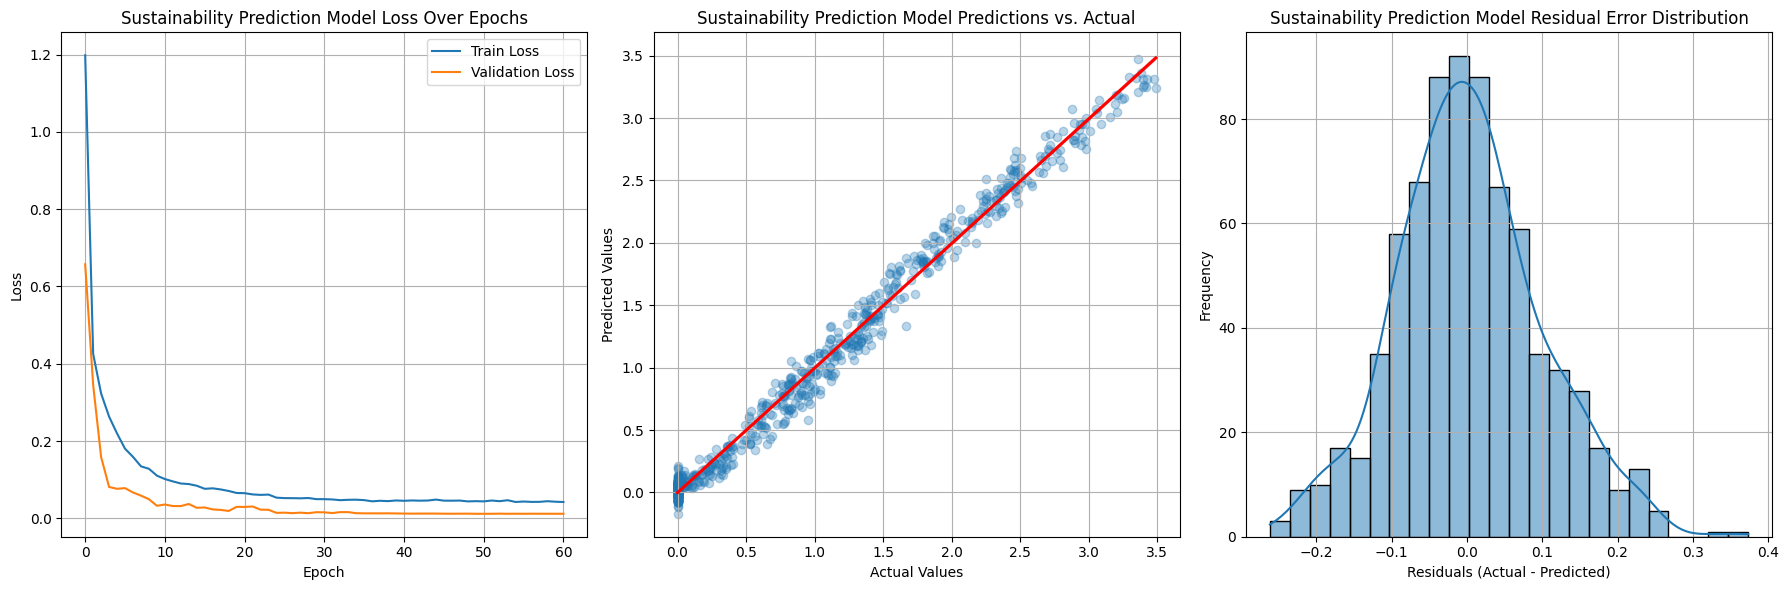

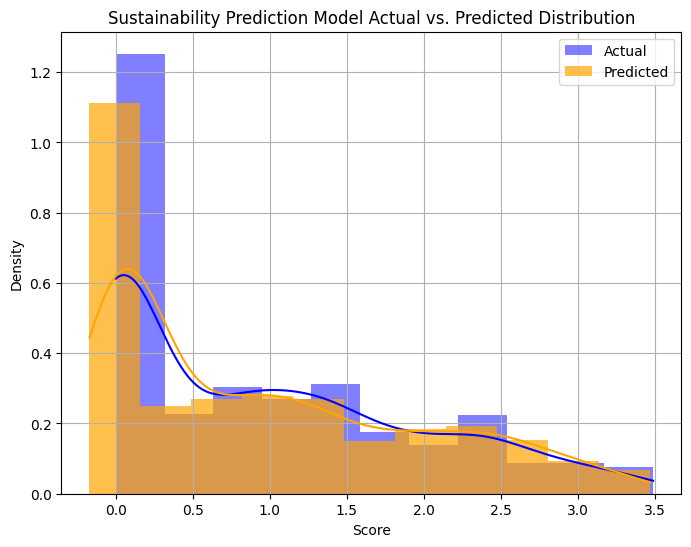


--- Evaluating Carbon Credit Prediction Model ---
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Test Loss: 1.6892
Test MAE: 1.0418
Test RMSE: 1.2997
Test R^2: 0.1815
Test MAPE: 97.6438


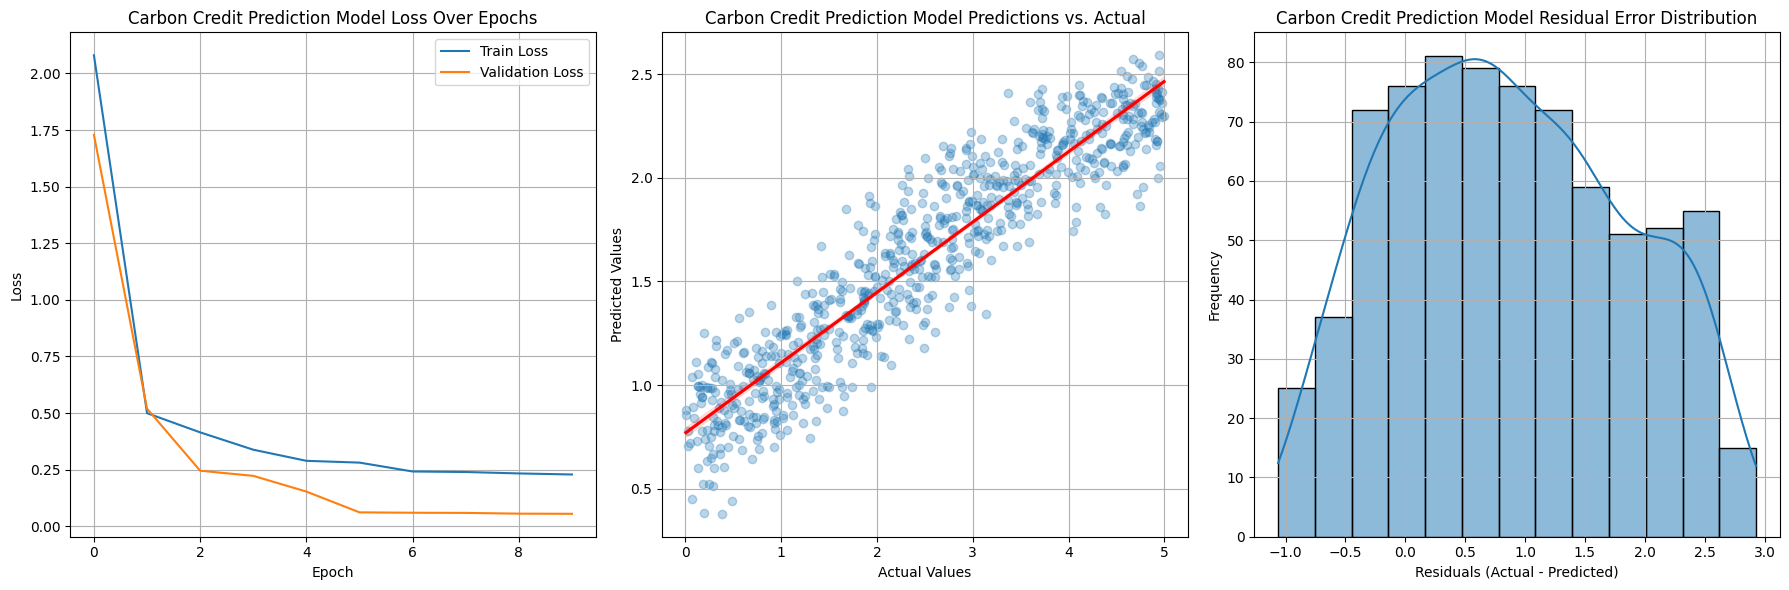

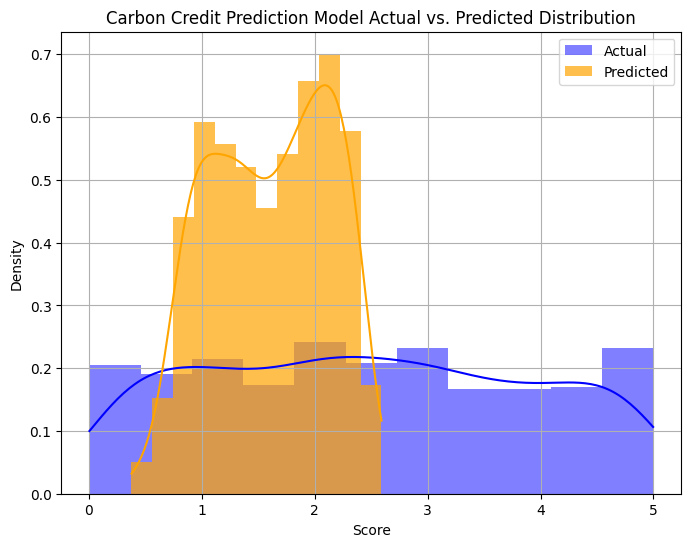

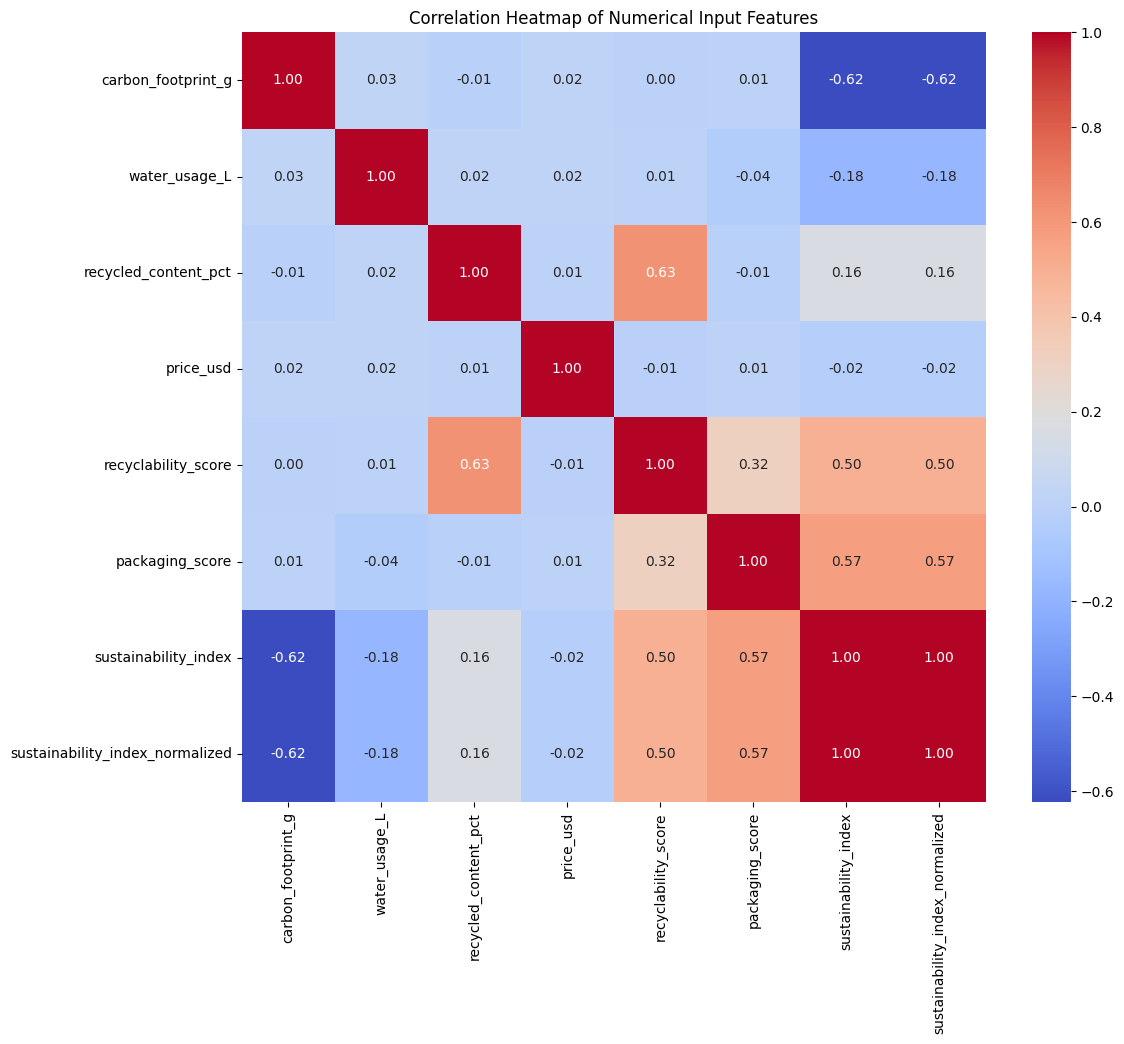

In [136]:
def evaluate_and_plot(model, X_test, Y_test, history, model_name):
    print(f"\n--- Evaluating {model_name} ---")
    test_loss, test_mae, test_rmse, test_mape = model.evaluate(X_test, Y_test, verbose=0)
    y_pred = model.predict(X_test).flatten()
    test_r2 = r2_score(Y_test, y_pred)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test R^2: {test_r2:.4f}")
    print(f"Test MAPE: {test_mape:.4f}")

    # Plot training & validation loss values
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Prediction vs. Actual
    plt.subplot(1, 3, 2)
    sns.regplot(x=Y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'{model_name} Predictions vs. Actual')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)

    # Plot Residuals
    plt.subplot(1, 3, 3)
    residuals = Y_test - y_pred
    sns.histplot(residuals, kde=True)
    plt.title(f'{model_name} Residual Error Distribution')
    plt.xlabel('Residuals (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Plot Prediction Distribution
    plt.figure(figsize=(8, 6))
    sns.histplot(Y_test, color='blue', label='Actual', kde=True, stat='density', linewidth=0)
    sns.histplot(y_pred, color='orange', label='Predicted', kde=True, stat='density', linewidth=0, alpha=0.7)
    plt.title(f'{model_name} Actual vs. Predicted Distribution')
    plt.xlabel('Score')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()

# Evaluate and plot for Sustainability Prediction Model
evaluate_and_plot(sustainability_model, X_test_processed, Y_sustainability_test, sustainability_history, "Sustainability Prediction Model")

# Evaluate and plot for Carbon Credit Prediction Model
evaluate_and_plot(carbon_credit_model, X_test_processed, Y_carbon_credit_test, carbon_credit_history, "Carbon Credit Prediction Model")

# Correlation Heatmap of Input Features
plt.figure(figsize=(12, 10))
sns.heatmap(X[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Input Features')
plt.show()

## 10. Save Models and Preprocessing Artifacts

In [137]:
# Save the trained Keras models
sustainability_model.save('eco_model.keras')
carbon_credit_model.save('carbon_credit_model.keras')
print("Trained Keras models saved as 'eco_model.keras' and 'carbon_credit_model.keras'.")

# Save the preprocessing pipeline
joblib.dump(preprocessor, 'preprocessor.joblib')
print("Preprocessing pipeline saved as 'preprocessor.joblib'.")

# Save feature names for consistent inference
joblib.dump(existing_feature_columns, 'feature_columns.joblib')
print("Feature columns saved as 'feature_columns.joblib'.")

Trained Keras models saved as 'eco_model.keras' and 'carbon_credit_model.keras'.
Preprocessing pipeline saved as 'preprocessor.joblib'.
Feature columns saved as 'feature_columns.joblib'.


## 11. Reusable Inference Functions

In [138]:
def predict_sustainability(product_features_df):
    """
    Predicts the Sustainability Score for given product features.

    Args:
        product_features_df (pd.DataFrame or dict): DataFrame or dictionary containing product features.

    Returns:
        np.ndarray: Predicted Sustainability Scores.
    """
    if isinstance(product_features_df, dict):
        product_features_df = pd.DataFrame([product_features_df])

    # Ensure consistent column order and handle missing features with the loaded columns
    loaded_feature_columns = joblib.load('feature_columns.joblib')
    for col in loaded_feature_columns:
        if col not in product_features_df.columns:
            product_features_df[col] = np.nan # Fill missing with NaN for imputer to handle

    # Reorder columns to match the training data's feature order
    product_features_df = product_features_df[loaded_feature_columns]

    # Load preprocessor and model
    loaded_preprocessor = joblib.load('preprocessor.joblib')
    loaded_sustainability_model = keras.models.load_model('eco_model.keras')

    # Preprocess input features
    processed_features = loaded_preprocessor.transform(product_features_df)

    # Predict
    predictions = loaded_sustainability_model.predict(processed_features).flatten()
    return predictions

def predict_carbon_credit(product_features_df):
    """
    Predicts the Carbon Credit Score (carbon_footprint_score) for given product features.

    Args:
        product_features_df (pd.DataFrame or dict): DataFrame or dictionary containing product features.

    Returns:
        np.ndarray: Predicted Carbon Credit Scores.
    """
    if isinstance(product_features_df, dict):
        product_features_df = pd.DataFrame([product_features_df])

    # Ensure consistent column order and handle missing features with the loaded columns
    loaded_feature_columns = joblib.load('feature_columns.joblib')
    for col in loaded_feature_columns:
        if col not in product_features_df.columns:
            product_features_df[col] = np.nan # Fill missing with NaN for imputer to handle

    # Reorder columns to match the training data's feature order
    product_features_df = product_features_df[loaded_feature_columns]

    # Load preprocessor and model
    loaded_preprocessor = joblib.load('preprocessor.joblib')
    loaded_carbon_credit_model = keras.models.load_model('carbon_credit_model.keras')

    # Preprocess input features
    processed_features = loaded_preprocessor.transform(product_features_df)

    # Predict
    predictions = loaded_carbon_credit_model.predict(processed_features).flatten()
    return predictions

print("Reusable inference functions 'predict_sustainability' and 'predict_carbon_credit' defined.")

Reusable inference functions 'predict_sustainability' and 'predict_carbon_credit' defined.


## 12. Demonstrate Inference

In [139]:
print("\n--- Demonstrating Inference ---")

# Select a few sample products from the original DataFrame for demonstration
sample_products_df = df.sample(5, random_state=42).copy()

# Prepare features for prediction using the original df and feature_columns
products_for_prediction = sample_products_df[existing_feature_columns]

# Predict Sustainability Score
predicted_sustainability_scores = predict_sustainability(products_for_prediction)

# Predict Carbon Credit Score
predicted_carbon_credit_scores = predict_carbon_credit(products_for_prediction)

# Create a results DataFrame
results_df = sample_products_df[[
    'product_name',
    'category',
    'material',
    'carbon_footprint_g',
]].copy()

results_df['Predicted Sustainability Score'] = predicted_sustainability_scores
results_df['Predicted Carbon Credit Score'] = predicted_carbon_credit_scores

display(results_df)

print("Inference demonstration complete.")


--- Demonstrating Inference ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


,product_name,category,material,carbon_footprint_g,Predicted Sustainability Score,Predicted Carbon Credit Score
1501,Leaf Bio Plastic Lunch Box,Apparel,Bio Plastic,3175,0.043095,1.379956
2586,Green Ceramic Keyboard,Toys,Ceramic,4729,0.005218,0.648641
2653,Leaf Cork Cup,Apparel,Cork,4079,0.196731,0.786490
1055,Bio Wheat Straw Lunch Box,Apparel,Wheat Straw,3082,-0.072868,0.988061
705,Compact Recycled Polyester T-Shirt,Outdoor,Recycled Polyester,1524,2.364957,1.937946


Inference demonstration complete.


In [140]:
sustainability_model.save(
    f"{SAVE_DIR}/eco_model.keras"
)

carbon_credit_model.save(
    f"{SAVE_DIR}/carbon_credit_model.keras"
)

In [141]:
import os

print(os.path.exists("eco_model.keras"))
print(os.path.exists("carbon_credit_model.keras"))

True
True


# Part 4 – TensorFlow Recommenders (TFRS) Recommendation System

## 1. Setup and Library Imports

In [50]:
# Set environment variable for Keras compatibility BEFORE any imports
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Install necessary libraries
# Requires a runtime restart after execution
!pip install -q tensorflow-recommenders tensorflow-text

import sys
print("Please restart the runtime (Runtime > Restart runtime) after this cell finishes execution to apply Keras compatibility setting and installed packages.")
# Use sys.exit() to force a stop and restart prompt
# sys.exit(0)

Please restart the runtime (Runtime > Restart runtime) after this cell finishes execution to apply Keras compatibility setting and installed packages.


**Important**: After running the previous cell, please restart the Colab runtime (Runtime -> Restart runtime) to ensure the `TF_USE_LEGACY_KERAS` environment variable is set and new packages are loaded correctly. Then, continue execution from the next cell.

In [38]:
import pprint
import tempfile

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs
import faiss
from sentence_transformers import SentenceTransformer
import torch # For GPU check
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tqdm.notebook import tqdm

# Configure TensorFlow to use GPU if available
if tf.config.list_physical_devices('GPU'):
    print(f"TensorFlow is using GPU: {tf.config.list_physical_devices('GPU')[0].name}")
    device = tf.device("cuda")
else:
    print("TensorFlow is using CPU.")
    device = tf.device("cpu")

# Set random seed for reproducibility
tf.random.set_seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported and environment configured.")

TensorFlow is using GPU: /physical_device:GPU:0
Libraries imported and environment configured.


## 2. Load Processed Data

In [56]:
# Save interactions_df to CSV for consistent loading across notebooks
# This assumes interactions_df was generated in a prior context or is available in the kernel.
if 'interactions_df' in locals() and not interactions_df.empty:
    interactions_df.to_csv('interactions.csv', index=False)
    print("interactions_df saved as 'interactions.csv' for consistent loading.")
else:
    print("interactions_df not found or is empty. Cannot save to 'interactions.csv'.")

# Load data artifacts from previous parts
products_df = pd.DataFrame()
product_embeddings = np.array([])
faiss_index = None
interactions_df = pd.DataFrame()

try:
    products_df = pd.read_csv('processed_products.csv')
    print("\n'processed_products.csv' loaded successfully.")
    print(f"Shape: {products_df.shape}")
    print("Data types for products_df:")
    display(products_df.info())
    display(products_df.head())

    product_embeddings = np.load('product_embeddings.npy')
    print("\n'product_embeddings.npy' loaded successfully.")
    print(f"Shape: {product_embeddings.shape}")

    faiss_index = faiss.read_index('faiss_product_index.bin')
    print("\n'faiss_product_index.bin' loaded successfully.")
    print(f"FAISS Index contains {faiss_index.ntotal} vectors of dimension {faiss_index.d}.")

    interactions_df = pd.read_csv('interactions.csv')
    print("\n'interactions.csv' loaded successfully.")
    print(f"Shape: {interactions_df.shape}")
    print("Data types for interactions_df:")
    display(interactions_df.info())
    display(interactions_df.head())

except FileNotFoundError as e:
    print(f"\nError loading file: {e}. Please ensure all previous parts were executed and generated the required files.")
    print("Cannot proceed without all necessary data files.")

# Data Type Conversion and Validation
if not products_df.empty:
    # Ensure product_id is string type for consistency with TFRS StringLookup
    if 'product_id' in products_df.columns and products_df['product_id'].dtype != 'object':
        products_df['product_id'] = products_df['product_id'].astype(str)
        print("products_df['product_id'] converted to string type.")

if not interactions_df.empty:
    # Ensure user_id and product_id are string types for consistency with TFRS StringLookup
    if 'user_id' in interactions_df.columns and interactions_df['user_id'].dtype != 'object':
        interactions_df['user_id'] = interactions_df['user_id'].astype(str)
        print("interactions_df['user_id'] converted to string type.")
    if 'product_id' in interactions_df.columns and interactions_df['product_id'].dtype != 'object':
        interactions_df['product_id'] = interactions_df['product_id'].astype(str)
        print("interactions_df['product_id'] converted to string type.")

# Basic validation
if products_df.empty or product_embeddings.size == 0 or faiss_index is None or interactions_df.empty:
    print("\nWARNING: Some data artifacts are missing or empty. Please check previous steps.")
else:
    print("\nAll required data artifacts loaded and validated successfully.")

interactions_df saved as 'interactions.csv' for consistent loading.

'processed_products.csv' loaded successfully.
Shape: (5000, 23)
Data types for products_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   product_id                       5000 non-null   int64  
 1   product_name                     5000 non-null   object 
 2   category                         5000 non-null   object 
 3   material                         5000 non-null   object 
 4   carbon_footprint_g               5000 non-null   int64  
 5   water_usage_L                    5000 non-null   int64  
 6   recycled_content_pct             5000 non-null   int64  
 7   packaging_type                   5000 non-null   object 
 8   certifications                   5000 non-null   object 
 9   price_usd                        5000 non-nul

None

,product_id,product_name,category,material,carbon_footprint_g,water_usage_L,recycled_content_pct,packaging_type,certifications,price_usd,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index,sustainability_index_normalized,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded,product_description
0,1,Eco Cork Lunch Box,Kitchen,Cork,1878,1153,94,Compostable,Unknown,0.740628,Finland,0.000000,3.154810,1.88,5,2.322443,60.023460,8,3,2,5,10,Product Name: Eco Cork Lunch Box. Category: Ki...
1,2,Compact Hemp Container,Apparel,Hemp,294,777,27,Glass Jar,Rainforest Alliance,0.601948,Finland,0.000000,4.755457,2.04,3,2.434637,62.925384,1,6,3,5,8,Product Name: Compact Hemp Container. Category...
2,3,Bio Glass Mouse,Personal Care,Glass,1855,3689,75,Biodegradable Pouch,GOTS,0.758777,China,1.809238,3.178052,2.50,0,1.996187,51.584771,11,5,0,3,4,Product Name: Bio Glass Mouse. Category: Perso...
3,4,Green Linen Lunch Box,Home Goods,Linen,1813,7851,97,Cloth Bag,FSC,0.092561,France,1.027788,3.220493,1.94,0,1.662484,42.953484,7,8,1,6,2,Product Name: Green Linen Lunch Box. Category:...
4,5,Earth Jute Mat,Outdoor,Jute,2216,6621,5,Plastic Film,Rainforest Alliance,0.124645,Norway,0.000000,2.813258,0.10,1,1.063977,27.472965,10,7,7,12,8,Product Name: Earth Jute Mat. Category: Outdoo...



'product_embeddings.npy' loaded successfully.
Shape: (5000, 768)

'faiss_product_index.bin' loaded successfully.
FAISS Index contains 5000 vectors of dimension 768.

'interactions.csv' loaded successfully.
Shape: (50000, 3)
Data types for interactions_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            50000 non-null  object
 1   product_id         50000 non-null  int64 
 2   interaction_score  50000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


None

,user_id,product_id,interaction_score
0,user_376,2,3
1,user_346,1665,5
2,user_673,567,5
3,user_267,134,2
4,user_628,2039,4


products_df['product_id'] converted to string type.
interactions_df['product_id'] converted to string type.

All required data artifacts loaded and validated successfully.


## 3. Prepare Data for TFRS

In [55]:
if not interactions_df.empty and not products_df.empty:
    # 1. Merge interactions with product details to get a rich dataset for training
    # This includes product_description and other features needed for potentially more complex models.
    merged_interactions_df = interactions_df.merge(products_df, on='product_id', how='left')

    # Handle any potential NaNs introduced by the merge (e.g., if a product_id in interactions is not in products)
    # For simplicity, we'll drop rows where essential product info is missing, but a more robust approach might impute.
    initial_rows = len(merged_interactions_df)
    merged_interactions_df.dropna(subset=['product_description', 'category', 'sustainability_index_normalized', 'material'], inplace=True)
    if len(merged_interactions_df) < initial_rows:
        print(f"Dropped {initial_rows - len(merged_interactions_df)} rows with missing product details after merge.")

    # Convert merged DataFrame to tf.data.Dataset
    # Ensure all relevant features are cast to appropriate TensorFlow types
    ratings_with_features = tf.data.Dataset.from_tensor_slices({
        "user_id": tf.cast(merged_interactions_df["user_id"], tf.string),
        "product_id": tf.cast(merged_interactions_df["product_id"], tf.string),
        "interaction_score": tf.cast(merged_interactions_df["interaction_score"], tf.float32),
        "product_description": tf.cast(merged_interactions_df["product_description"], tf.string),
        "category": tf.cast(merged_interactions_df["category"], tf.string),
        "material": tf.cast(merged_interactions_df["material"], tf.string), # Added 'material' feature
        "sustainability_index_normalized": tf.cast(merged_interactions_df["sustainability_index_normalized"], tf.float32)
    })

    # Create a separate products dataset from the original products_df
    # This is primarily for FactorizedTopK candidates in the retrieval model
    products_tf = tf.data.Dataset.from_tensor_slices({
        "product_id": tf.cast(products_df["product_id"], tf.string),
        "product_description": tf.cast(products_df["product_description"], tf.string),
        "category": tf.cast(products_df["category"], tf.string),
        "sustainability_index_normalized": tf.cast(products_df["sustainability_index_normalized"], tf.float32)
    })

    # Collect unique user_ids and product_ids for vocabulary from the merged data
    unique_user_ids = np.unique(merged_interactions_df['user_id']).astype(str)
    unique_product_ids = np.unique(merged_interactions_df['product_id']).astype(str)

    # Create StringLookup layers
    user_id_lookup = tf.keras.layers.StringLookup(vocabulary=unique_user_ids, mask_token=None)
    product_id_lookup = tf.keras.layers.StringLookup(vocabulary=unique_product_ids, mask_token=None)

    print("Merged dataset and StringLookup layers prepared.")

    # 2. Split into training, validation, and testing datasets (e.g., 80/10/10 split)
    total_records = len(merged_interactions_df)
    train_size = int(0.8 * total_records)
    val_size = int(0.1 * total_records)
    test_size = total_records - train_size - val_size # Remaining for test

    # Shuffle the dataset before splitting
    shuffled_ratings = ratings_with_features.shuffle(total_records, seed=42, reshuffle_each_iteration=False)

    train_ds = shuffled_ratings.take(train_size)
    val_ds = shuffled_ratings.skip(train_size).take(val_size)
    test_ds = shuffled_ratings.skip(train_size + val_size)

    # 3. Apply batching, caching, and prefetching for efficiency
    BATCH_SIZE = 256 # Define a suitable batch size
    AUTOTUNE = tf.data.AUTOTUNE # Automatically tune for performance

    train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    products_tf_batched = products_tf.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

    print("Datasets split, batched, cached, and prefetched.")

    # 4. Print sample batches to verify structure
    print("\nSample from Training Dataset:")
    for x in train_ds.take(1):
        pprint.pprint(x)

    print("\nSample from Products Dataset (for candidates):")
    for x in products_tf_batched.take(1):
        pprint.pprint(x)

else:
    print("Cannot prepare TFRS data because interactions_df or products_df is empty.")
    train_ds = None
    val_ds = None
    test_ds = None
    products_tf_batched = None

Merged dataset and StringLookup layers prepared.
Datasets split, batched, cached, and prefetched.

Sample from Training Dataset:
{'category': <tf.Tensor: shape=(256,), dtype=string, numpy=
array([b'Apparel', b'Apparel', b'Outdoor', b'Sports', b'Apparel',
       b'Kitchen', b'Electronics', b'Beauty', b'Pet Care', b'Apparel',
       b'Toys', b'Toys', b'Food', b'Food', b'Sports', b'Kitchen',
       b'Office Supplies', b'Beauty', b'Outdoor', b'Home Goods',
       b'Beauty', b'Pet Care', b'Outdoor', b'Food', b'Pet Care',
       b'Apparel', b'Toys', b'Toys', b'Personal Care', b'Accessories',
       b'Personal Care', b'Furniture', b'Outdoor', b'Kitchen', b'Apparel',
       b'Toys', b'Apparel', b'Food', b'Home Goods', b'Accessories',
       b'Electronics', b'Electronics', b'Furniture', b'Home Goods',
       b'Electronics', b'Pet Care', b'Outdoor', b'Beauty', b'Toys',
       b'Grocery', b'Office Supplies', b'Grocery', b'Food',
       b'Personal Care', b'Home Goods', b'Home Goods', b'Outdoor',
 

## 4. Retrieval Model Definition

In [57]:
embedding_dimension = 32 # Define the embedding dimension

# Define the User Model
class UserModel(tf.keras.Model):

    def __init__(self, unique_user_ids, embedding_dimension):
        super().__init__()
        # unique_user_ids (numpy array) is not directly serializable by Keras's default get_config.
        # Therefore, for full model saving/loading via model.save()/load_model(),
        # get_config() and from_config() would need to be implemented to handle this.
        # For this notebook, we rely on saving/loading weights and re-instantiation if needed.
        self.user_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_user_ids.tolist(), mask_token=None),
            tf.keras.layers.Embedding(unique_user_ids.shape[0] + 1, embedding_dimension)
        ])

    def call(self, inputs):
        return self.user_embedding(inputs)

# Define the Product Model
class ProductModel(tf.keras.Model):

    def __init__(self, unique_product_ids, embedding_dimension):
        super().__init__()
        # unique_product_ids (numpy array) is not directly serializable by Keras's default get_config.
        # For this notebook, we rely on saving/loading weights and re-instantiation if needed.
        self.product_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_product_ids.tolist(), mask_token=None),
            tf.keras.layers.Embedding(unique_product_ids.shape[0] + 1, embedding_dimension)
        ])

    def call(self, inputs):
        # Ensure inputs are cast to string for StringLookup layer
        # The 'products_tf' dataset yields dictionaries, so we need to extract 'product_id'
        if isinstance(inputs, dict):
            product_ids_raw = tf.cast(inputs["product_id"], tf.string)
        else:
            product_ids_raw = tf.cast(inputs, tf.string)
        return self.product_embedding(product_ids_raw)

# Define the TFRS Retrieval Model
class MovielensModel(tfrs.Model):

    def __init__(self, unique_user_ids, unique_product_ids, embedding_dimension):
        super().__init__()
        # unique_user_ids and unique_product_ids (numpy arrays) are not directly serializable by Keras's default get_config.
        # For this notebook, we rely on saving/loading weights and re-instantiation if needed.
        self.user_model = UserModel(unique_user_ids, embedding_dimension)
        self.product_model = ProductModel(unique_product_ids, embedding_dimension)

        # Define metrics for evaluation
        # Correctly pass product_model output as candidates to FactorizedTopK
        # Use the unbatched products_tf dataset to create candidate embeddings, then batch them.
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=products_tf.map(self.product_model).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
            )
        )

    # Simplified call method for explicit model building/inference
    def call(self, features):
        user_embedding = self.user_model(features["user_id"])
        # For explicit model building via call(), it's often simpler for Keras to return
        # a single tensor. The user_embedding is a good representative output.
        return user_embedding

    def compute_loss(self, features, training=False):
        user_embeddings = self.user_model(features["user_id"])
        product_embeddings = self.product_model(features["product_id"])

        return self.task(user_embeddings, product_embeddings)

## 5. Retrieval Model Training

In [58]:
model = MovielensModel(unique_user_ids, unique_product_ids, embedding_dimension)

# Compile the model with the Adam optimizer as requested
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))

print("Starting model training...")
history = model.fit(
    train_ds,
    epochs=10,
    verbose=1
)

print("Model training complete.")

Starting model training...
Epoch 1/10
157/157 [==============================] - 33s 189ms/step - factorized_top_k/top_1_categorical_accuracy: 0.1072 - factorized_top_k/top_5_categorical_accuracy: 0.1348 - factorized_top_k/top_10_categorical_accuracy: 0.1466 - factorized_top_k/top_50_categorical_accuracy: 0.1857 - factorized_top_k/top_100_categorical_accuracy: 0.2087 - loss: 1405.5167 - regularization_loss: 0.0000e+00 - total_loss: 1405.5167
Epoch 2/10
157/157 [==============================] - 27s 169ms/step - factorized_top_k/top_1_categorical_accuracy: 0.7387 - factorized_top_k/top_5_categorical_accuracy: 0.7622 - factorized_top_k/top_10_categorical_accuracy: 0.7720 - factorized_top_k/top_50_categorical_accuracy: 0.7950 - factorized_top_k/top_100_categorical_accuracy: 0.8056 - loss: 1321.2568 - regularization_loss: 0.0000e+00 - total_loss: 1321.2568
Epoch 3/10
157/157 [==============================] - 28s 177ms/step - factorized_top_k/top_1_categorical_accuracy: 0.9394 - factorized

## 6. Retrieval Model Evaluation

In [59]:
print("Starting model evaluation...")
model.evaluate(test_ds, return_dict=True)

Starting model evaluation...
20/20 [==============================] - 5s 208ms/step - factorized_top_k/top_1_categorical_accuracy: 0.4322 - factorized_top_k/top_5_categorical_accuracy: 0.4424 - factorized_top_k/top_10_categorical_accuracy: 0.4458 - factorized_top_k/top_50_categorical_accuracy: 0.4576 - factorized_top_k/top_100_categorical_accuracy: 0.4606 - loss: 2415.2022 - regularization_loss: 0.0000e+00 - total_loss: 2415.2022


{'factorized_top_k/top_1_categorical_accuracy': 0.43220001459121704,
 'factorized_top_k/top_5_categorical_accuracy': 0.4424000084400177,
 'factorized_top_k/top_10_categorical_accuracy': 0.4458000063896179,
 'factorized_top_k/top_50_categorical_accuracy': 0.4575999975204468,
 'factorized_top_k/top_100_categorical_accuracy': 0.46059998869895935,
 'loss': 1214.66259765625,
 'regularization_loss': 0.0,
 'total_loss': 1214.66259765625}

## 7. Ranking Model Definition

### 7.1 User Embedding Tower

In [73]:
# Define the User Embedding Tower for the Ranking Model
class UserEmbeddingTower(tf.keras.Model):

    def __init__(self, unique_user_ids, embedding_dimension, dropout_rate=0.2):
        super().__init__()
        # unique_user_ids (numpy array) is not directly serializable by Keras's default get_config.
        # For this notebook, we rely on saving/loading weights and re-instantiation if needed.

        # 1. StringLookup to convert raw user IDs to integer indices
        self.user_id_lookup = tf.keras.layers.StringLookup(
            vocabulary=unique_user_ids.tolist(), mask_token=None, name="user_id_lookup_ranking"
        )

        # 2. Embedding layer to learn dense representations for each user
        # The input_dim is the size of the vocabulary (+1 for unknown tokens if mask_token=None)
        self.user_embedding = tf.keras.Sequential([
            self.user_id_lookup,
            tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension, name="user_embedding_layer"),
            # You can add more layers here to enrich user embeddings
            tf.keras.layers.Dense(embedding_dimension * 2, activation='relu', name="user_dense_1"),
            tf.keras.layers.BatchNormalization(name="user_batch_norm_1"),
            tf.keras.layers.Dropout(dropout_rate, name="user_dropout_1"),
            tf.keras.layers.Dense(embedding_dimension, activation='relu', name="user_dense_2") # Final embedding size
        ], name="user_embedding_tower_sequence")

    def call(self, inputs):
        # Inputs for the user tower will be user_ids (Tensor of strings)
        return self.user_embedding(inputs)

print("UserEmbeddingTower class defined.")

UserEmbeddingTower class defined.


In [62]:
# Demonstrate the UserEmbeddingTower
# Re-using unique_user_ids and embedding_dimension from previous cells

if 'unique_user_ids' in locals() and 'embedding_dimension' in locals():
    user_tower = UserEmbeddingTower(unique_user_ids, embedding_dimension)

    # Get a sample user ID
    sample_user_id = unique_user_ids[0]
    print(f"Sample User ID: {sample_user_id}")

    # Convert to a TensorFlow tensor
    sample_user_id_tensor = tf.constant([sample_user_id])

    # Get the embedding
    user_embedding_output = user_tower(sample_user_id_tensor)

    print(f"\nOutput user embedding shape: {user_embedding_output.shape}")
    print(f"Sample user embedding (first 5 values): {user_embedding_output.numpy()[0, :5]}")

    # Test with multiple user IDs
    sample_user_ids_batch = tf.constant(unique_user_ids[:3]) # Take first 3 user IDs
    user_embeddings_batch = user_tower(sample_user_ids_batch)
    print(f"\nOutput user embeddings batch shape: {user_embeddings_batch.shape}")

else:
    print("Could not demonstrate UserEmbeddingTower. 'unique_user_ids' or 'embedding_dimension' not found.")

Sample User ID: user_0

Output user embedding shape: (1, 32)
Sample user embedding (first 5 values): [0.         0.01298106 0.01230956 0.011843   0.01169455]

Output user embeddings batch shape: (3, 32)


### 7.2 Product Embedding Tower

In [74]:
class ProductEmbeddingTower(tf.keras.Model):

    def __init__(self, unique_product_ids, embedding_dimension, product_embeddings_data, products_df_for_lookup, dropout_rate=0.2):
        super().__init__()
        # unique_product_ids (numpy array), product_embeddings_data (numpy array),
        # and products_df_for_lookup (pandas DataFrame) are not directly serializable by Keras's default get_config.
        # For this notebook, we rely on saving/loading weights and re-instantiation if needed.

        # 1. StringLookup to convert raw product IDs from interactions to integer indices for *learned* embeddings
        # This vocabulary comes from the unique product IDs present in the interactions.
        self.product_id_lookup = tf.keras.layers.StringLookup(
            vocabulary=unique_product_ids.tolist(), mask_token=None, name="product_id_lookup_ranking"
        )

        # 2. Embedding layer for product_ids (learned embeddings)
        # This layer learns embeddings for products seen in interactions.
        self.product_id_embedding_layer = tf.keras.layers.Embedding(
            len(unique_product_ids) + 1, embedding_dimension, name="product_id_embedding_layer"
        )

        # StringLookup to convert raw product IDs to integer indices corresponding to the *full* product embeddings array
        # This vocabulary comes from the original products_df, ensuring we can correctly index into `product_embeddings_data`.
        # Ensure product_id is treated as string for lookup
        original_product_ids_vocab = products_df_for_lookup['product_id'].astype(str).tolist()
        self.original_product_id_lookup = tf.keras.layers.StringLookup(
            vocabulary=original_product_ids_vocab, mask_token=None, name="original_product_id_lookup"
        )

        # Prepare padded Sentence-BERT embeddings data
        # The `tf.keras.layers.StringLookup` layer includes an OOV bucket at the last index.
        # To align the `weights` with the `input_dim` of the Embedding layer, we need to add
        # a row of zeros (or another placeholder) to `product_embeddings_data` for this OOV token.
        num_original_products = product_embeddings_data.shape[0]
        embedding_dim_bert = product_embeddings_data.shape[1]

        # Create an array of zeros for the OOV token
        oov_embedding = np.zeros((1, embedding_dim_bert), dtype=np.float32)

        # Concatenate the original embeddings with the OOV embedding
        padded_product_embeddings_data = np.vstack([
            product_embeddings_data.astype(np.float32),
            oov_embedding
        ])

        # 3. Embedding layer for precomputed Sentence-BERT product_embeddings
        # The input_dim must now match the number of rows in `padded_product_embeddings_data`.
        self.sentence_bert_embedding_layer = tf.keras.layers.Embedding(
            input_dim=padded_product_embeddings_data.shape[0], # Should be len(products_df) + 1
            output_dim=embedding_dim_bert,
            weights=[padded_product_embeddings_data],
            trainable=False,
            name="sentence_bert_embedding_layer"
        )

        # 4. Dense layers to process and combine all product embeddings
        self.dense_layers = tf.keras.Sequential([
            tf.keras.layers.Dense(embedding_dimension * 2, activation='relu', name="product_dense_1"),
            tf.keras.layers.BatchNormalization(name="product_batch_norm_1"),
            tf.keras.layers.Dropout(dropout_rate, name="product_dropout_1"),
            tf.keras.layers.Dense(embedding_dimension, activation='relu', name="product_dense_2") # Final embedding size
        ], name="product_embedding_tower_sequence")

    def call(self, inputs):
        # Extract product_id from the input dictionary
        product_ids = inputs["product_id"]

        # Get integer indices for product_ids for learned embeddings (from interaction-based vocabulary)
        learned_product_indices = self.product_id_lookup(product_ids)
        learned_id_embeddings = self.product_id_embedding_layer(learned_product_indices)

        # Get integer indices for product_ids for Sentence-BERT embeddings (from full products_df vocabulary)
        original_product_indices = self.original_product_id_lookup(product_ids)
        sentence_bert_embeddings = self.sentence_bert_embedding_layer(original_product_indices)

        # Concatenate both types of embeddings
        combined_product_embeddings = tf.concat([
            learned_id_embeddings,
            sentence_bert_embeddings
        ], axis=-1)

        # Pass through dense layers for final product embedding
        product_embeddings = self.dense_layers(combined_product_embeddings)

        return product_embeddings

print("ProductEmbeddingTower class defined with Sentence-BERT integration and corrected OOV handling.")

ProductEmbeddingTower class defined with Sentence-BERT integration and corrected OOV handling.


In [72]:
# Demonstrate the ProductEmbeddingTower
# Re-using unique_product_ids and embedding_dimension from previous cells

# Ensure product_embeddings (from .npy file) and products_df are available globally for demonstration
if 'unique_product_ids' in locals() and 'embedding_dimension' in locals() and 'product_embeddings' in globals() and 'products_df' in globals():
    product_tower = ProductEmbeddingTower(unique_product_ids, embedding_dimension, product_embeddings, products_df)

    # Get a sample product ID
    sample_product_id = unique_product_ids[0]
    print(f"Sample Product ID: {sample_product_id}")

    # Convert to a TensorFlow tensor within a dictionary matching the call signature
    sample_product_id_tensor = tf.constant([sample_product_id])
    sample_input = {"product_id": sample_product_id_tensor}

    # Get the embedding
    product_embedding_output = product_tower(sample_input)

    print(f"\nOutput product embedding shape: {product_embedding_output.shape}")
    print(f"Sample product embedding (first 5 values): {product_embedding_output.numpy()[0, :5]}")

    # Test with multiple product IDs
    sample_product_ids_batch = tf.constant(unique_product_ids[1:4]) # Take 3 sample product IDs
    sample_input_batch = {"product_id": sample_product_ids_batch}
    product_embeddings_batch = product_tower(sample_input_batch)
    print(f"\nOutput product embeddings batch shape: {product_embeddings_batch.shape}")

else:
    missing_vars = []
    if 'unique_product_ids' not in locals(): missing_vars.append('unique_product_ids')
    if 'embedding_dimension' not in locals(): missing_vars.append('embedding_dimension')
    if 'product_embeddings' not in globals(): missing_vars.append('product_embeddings (from .npy)')
    if 'products_df' not in globals(): missing_vars.append('products_df')
    print(f"Could not demonstrate ProductEmbeddingTower. The following required variables were not found: {', '.join(missing_vars)}.")

Sample Product ID: 1

Output product embedding shape: (1, 32)
Sample product embedding (first 5 values): [0.01953601 0.         0.         0.         0.        ]

Output product embeddings batch shape: (3, 32)


### 7.3 Ranking Model

In [65]:
# Define the full Ranking Model
class EcofashionRankingModel(tfrs.models.Model):

    def __init__(self, unique_user_ids, unique_product_ids, embedding_dimension, products_df, product_embeddings_data, dropout_rate=0.2):
        super().__init__()
        # unique_user_ids (numpy array), unique_product_ids (numpy array), products_df (pandas DataFrame),
        # and product_embeddings_data (numpy array) are not directly serializable by Keras's default get_config.
        # For this notebook, we rely on saving/loading weights and re-instantiation if needed.

        self.user_embedding_tower = UserEmbeddingTower(unique_user_ids, embedding_dimension, dropout_rate)
        # Pass product_embeddings_data AND products_df to the ProductEmbeddingTower
        self.product_embedding_tower = ProductEmbeddingTower(unique_product_ids, embedding_dimension, product_embeddings_data, products_df, dropout_rate)

        # Define normalization for numerical features that will be used in the ranking model
        self.sustainability_normalizer = tf.keras.layers.Normalization(
            axis=None, name="sustainability_normalization"
        )
        # Adapt the normalizer to the sustainability index from the products_df
        # Ensure products_df is available and contains 'sustainability_index_normalized'
        if 'sustainability_index_normalized' in products_df.columns:
            sustainability_data = products_df['sustainability_index_normalized'].values.astype(np.float32)
            self.sustainability_normalizer.adapt(sustainability_data)
        else:
            print("Warning: 'sustainability_index_normalized' not found in products_df. Sustainability feature will not be normalized.")

        # Define StringLookup for categorical features used in ranking
        self.category_lookup = tf.keras.layers.StringLookup(
            vocabulary=np.unique(products_df['category'].astype(str)).tolist(), mask_token=None, name="category_lookup"
        )
        self.material_lookup = tf.keras.layers.StringLookup(
            vocabulary=np.unique(products_df['material'].astype(str)).tolist(), mask_token=None, name="material_lookup"
        )

        # Define embedding for categorical features
        self.category_embedding = tf.keras.layers.Embedding(
            len(np.unique(products_df['category'].astype(str))) + 1, embedding_dimension // 2, name="category_embedding"
        )
        self.material_embedding = tf.keras.layers.Embedding(
            len(np.unique(products_df['material'].astype(str))) + 1, embedding_dimension // 2, name="material_embedding"
        )

        # The ranking model (scoring head)
        self.task = tfrs.tasks.Ranking(loss=tf.keras.losses.MeanSquaredError(),
                                        metrics=[tf.keras.metrics.RootMeanSquaredError()],
                                        name="ranking_task")

        # Combined features to predict rating
        self.rating_model = tf.keras.Sequential([
            # Ensure inputs are correctly concatenated
            tf.keras.layers.Dense(256, activation="relu", name="ranking_dense_1"),
            tf.keras.layers.BatchNormalization(name="ranking_batch_norm_1"),
            tf.keras.layers.Dropout(dropout_rate, name="ranking_dropout_1"),
            tf.keras.layers.Dense(128, activation="relu", name="ranking_dense_2"),
            tf.keras.layers.BatchNormalization(name="ranking_batch_norm_2"),
            tf.keras.layers.Dropout(dropout_rate, name="ranking_dropout_2"),
            tf.keras.layers.Dense(1, name="rating_prediction_output") # Predict a single rating score
        ], name="ranking_scoring_head")

    def call(self, features):
        # Get user and product embeddings from their respective towers
        user_embedding = self.user_embedding_tower(features["user_id"])
        product_embedding = self.product_embedding_tower(features) # Product tower expects dict input

        # Process additional features
        normalized_sustainability = self.sustainability_normalizer(features["sustainability_index_normalized"])
        category_embedding = self.category_embedding(self.category_lookup(features["category"]))
        material_embedding = self.material_embedding(self.material_lookup(features["material"]))

        # Concatenate all features for the ranking model
        all_features = tf.concat([
            user_embedding,
            product_embedding,
            tf.expand_dims(normalized_sustainability, axis=1), # Ensure shape compatibility
            category_embedding,
            material_embedding
        ], axis=1)

        return self.rating_model(all_features)

    def compute_loss(self, features, training=False):
        labels = features["interaction_score"]
        predictions = self(features)
        return self.task(labels=labels, predictions=predictions)

print("EcofashionRankingModel class defined.")

EcofashionRankingModel class defined.


In [78]:
# Demonstrate the EcofashionRankingModel
# Assuming unique_user_ids, unique_product_ids, embedding_dimension, products_df, and product_embeddings are available

# Check for all required variables in the global scope
required_vars = ['unique_user_ids', 'unique_product_ids', 'embedding_dimension', 'products_df', 'product_embeddings', 'train_ds']
if all(var in globals() for var in required_vars):
    ranking_model = EcofashionRankingModel(unique_user_ids, unique_product_ids, embedding_dimension, products_df, product_embeddings)

    # Get a sample batch from the training dataset to simulate input
    for sample_features in train_ds.take(1):
        print("Sample input features for ranking model:")
        for k, v in sample_features.items():
            print(f"  {k}: {v.shape}, {v.dtype}")

        # Make a prediction (forward pass)
        sample_predictions = ranking_model(sample_features)

        print(f"\nOutput prediction shape: {sample_predictions.shape}")
        print(f"Sample predictions (first 5 values): {sample_predictions.numpy()[:5].flatten()}")
        break # Only take one batch

else:
    missing_vars = [var for var in required_vars if var not in globals()]
    print(f"Could not demonstrate EcofashionRankingModel. The following required variables were not found: {', '.join(missing_vars)}.")
    print("Please ensure all preceding data preparation and model definition cells have been executed.")

Sample input features for ranking model:
  user_id: (256,), <dtype: 'string'>
  product_id: (256,), <dtype: 'string'>
  interaction_score: (256,), <dtype: 'float32'>
  product_description: (256,), <dtype: 'string'>
  category: (256,), <dtype: 'string'>
  material: (256,), <dtype: 'string'>
  sustainability_index_normalized: (256,), <dtype: 'float32'>

Output prediction shape: (256, 1)
Sample predictions (first 5 values): [-0.00849752  0.00189373  0.05964369 -0.00200693  0.02394842]


## 6. Ranking Model Training and Evaluation

In [80]:
# Instantiate the Ranking Model
ranking_model = EcofashionRankingModel(
    unique_user_ids,
    unique_product_ids,
    embedding_dimension,
    products_df,
    product_embeddings
)

# Compile the ranking model
# Using Adam optimizer with a learning rate
ranking_model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.1))

print("Starting ranking model training...")
ranking_history = ranking_model.fit(
    train_ds.map(lambda x: {
        "user_id": x["user_id"],
        "product_id": x["product_id"],
        "interaction_score": x["interaction_score"],
        "product_description": x["product_description"],
        "category": x["category"],
        "material": x["material"],
        "sustainability_index_normalized": x["sustainability_index_normalized"]
    }),
    epochs=10,
    verbose=1
)

print("Ranking model training complete.")

Starting ranking model training...
Epoch 1/10
157/157 [==============================] - 8s 30ms/step - root_mean_squared_error: 1.4908 - loss: 2.2189 - regularization_loss: 0.0000e+00 - total_loss: 2.2189
Epoch 2/10
157/157 [==============================] - 2s 13ms/step - root_mean_squared_error: 1.4146 - loss: 1.9999 - regularization_loss: 0.0000e+00 - total_loss: 1.9999
Epoch 3/10
157/157 [==============================] - 3s 21ms/step - root_mean_squared_error: 1.4132 - loss: 1.9960 - regularization_loss: 0.0000e+00 - total_loss: 1.9960
Epoch 4/10
157/157 [==============================] - 2s 14ms/step - root_mean_squared_error: 1.4124 - loss: 1.9939 - regularization_loss: 0.0000e+00 - total_loss: 1.9939
Epoch 5/10
157/157 [==============================] - 2s 12ms/step - root_mean_squared_error: 1.4120 - loss: 1.9926 - regularization_loss: 0.0000e+00 - total_loss: 1.9926
Epoch 6/10
157/157 [==============================] - 2s 13ms/step - root_mean_squared_error: 1.4116 - loss: 1

### 6.2 Evaluate the Ranking Model

In [81]:
print("Starting ranking model evaluation...")
ranking_evaluation_results = ranking_model.evaluate(
    test_ds.map(lambda x: {
        "user_id": x["user_id"],
        "product_id": x["product_id"],
        "interaction_score": x["interaction_score"],
        "product_description": x["product_description"],
        "category": x["category"],
        "material": x["material"],
        "sustainability_index_normalized": x["sustainability_index_normalized"]
    }),
    return_dict=True,
    verbose=1
)

print("Ranking model evaluation complete.")
pprint.pprint(ranking_evaluation_results)

Starting ranking model evaluation...
20/20 [==============================] - 0s 9ms/step - root_mean_squared_error: 1.4079 - loss: 2.0000 - regularization_loss: 0.0000e+00 - total_loss: 2.0000
Ranking model evaluation complete.
{'loss': 2.236962080001831,
 'regularization_loss': 0.0,
 'root_mean_squared_error': 1.4079049825668335,
 'total_loss': 2.236962080001831}


## 7. Model Training and Evaluation with Callbacks

### 7.0 Define Callbacks

In [82]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_total_loss', # Monitor validation loss
    patience=3,               # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

model_checkpoint_retrieval = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_retrieval_model_weights.keras', # Path to save the model weights
    monitor='val_factorized_top_k/top_100_categorical_accuracy', # Monitor top-100 accuracy
    save_best_only=True,     # Save only the best model according to the monitored metric
    mode='max',              # Maximize the monitored metric
    verbose=1,
    save_weights_only=True   # Save only the model's weights to avoid serialization issues with StringLookup
)

model_checkpoint_ranking = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_ranking_model_weights.keras', # Path to save the model weights
    monitor='val_root_mean_squared_error', # Monitor validation RMSE
    save_best_only=True,     # Save only the best model
    mode='min',              # Minimize the monitored metric
    verbose=1,
    save_weights_only=True   # Save only the model's weights to avoid serialization issues with StringLookup
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_total_loss', # Monitor validation loss
    factor=0.2,               # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=2,               # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.0001,            # Lower bound on the learning rate
    verbose=1
)

print("Keras callbacks defined: EarlyStopping, ModelCheckpoint (for retrieval and ranking), and ReduceLROnPlateau.")

Keras callbacks defined: EarlyStopping, ModelCheckpoint (for retrieval and ranking), and ReduceLROnPlateau.


In [83]:
def plot_training_history(history, model_type="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{model_type} Loss Over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot Metrics (assuming one main metric like accuracy or RMSE)
    # For retrieval, 'factorized_top_k/top_100_categorical_accuracy' is a good choice
    # For ranking, 'root_mean_squared_error' is appropriate
    if 'factorized_top_k/top_100_categorical_accuracy' in history.history:
        axes[1].plot(history.history['factorized_top_k/top_100_categorical_accuracy'], label='Training Top-100 Accuracy')
        if 'val_factorized_top_k/top_100_categorical_accuracy' in history.history:
            axes[1].plot(history.history['val_factorized_top_k/top_100_categorical_accuracy'], label='Validation Top-100 Accuracy')
        axes[1].set_title(f'{model_type} Top-100 Accuracy Over Epochs')
        axes[1].set_ylabel('Accuracy')
    elif 'root_mean_squared_error' in history.history:
        axes[1].plot(history.history['root_mean_squared_error'], label='Training RMSE')
        if 'val_root_mean_squared_error' in history.history:
            axes[1].plot(history.history['val_root_mean_squared_error'], label='Validation RMSE')
        axes[1].set_title(f'{model_type} RMSE Over Epochs')
        axes[1].set_ylabel('RMSE')
    else:
        # Fallback if specific metrics are not found
        print("No specific primary metric found for plotting. Plotting total_loss if available.")
        if 'total_loss' in history.history:
            axes[1].plot(history.history['total_loss'], label='Training Total Loss')
            if 'val_total_loss' in history.history:
                axes[1].plot(history.history['val_total_loss'], label='Validation Total Loss')
            axes[1].set_title(f'{model_type} Total Loss Over Epochs')
            axes[1].set_ylabel('Total Loss')

    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print("Function to plot training history defined.")

Function to plot training history defined.


### 7.1 Retrieval Model Training

In [84]:
# Re-instantiate the Retrieval Model
retrieval_model_with_callbacks = MovielensModel(unique_user_ids, unique_product_ids, embedding_dimension)

# Explicitly build the model with a sample batch to resolve potential saving issues
_ = retrieval_model_with_callbacks(next(iter(train_ds))) # This call will now use the updated `call` method

# Compile the retrieval model with Adam optimizer
retrieval_model_with_callbacks.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))

print("Starting Retrieval Model training with callbacks...")
retrieval_history = retrieval_model_with_callbacks.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20, # Set a higher number of epochs as EarlyStopping will manage it
    verbose=1,
    callbacks=[early_stopping, model_checkpoint_retrieval, reduce_lr]
)

print("Retrieval Model training complete.")

Starting Retrieval Model training with callbacks...
Epoch 1/20
157/157 [==============================] - ETA: 0s - factorized_top_k/top_1_categorical_accuracy: 0.1096 - factorized_top_k/top_5_categorical_accuracy: 0.1366 - factorized_top_k/top_10_categorical_accuracy: 0.1491 - factorized_top_k/top_50_categorical_accuracy: 0.1864 - factorized_top_k/top_100_categorical_accuracy: 0.2082 - loss: 1412.8459 - regularization_loss: 0.0000e+00 - total_loss: 1412.8459
Epoch 1: val_factorized_top_k/top_100_categorical_accuracy improved from -inf to 0.33340, saving model to best_retrieval_model_weights.keras
157/157 [==============================] - 37s 215ms/step - factorized_top_k/top_1_categorical_accuracy: 0.1096 - factorized_top_k/top_5_categorical_accuracy: 0.1366 - factorized_top_k/top_10_categorical_accuracy: 0.1491 - factorized_top_k/top_50_categorical_accuracy: 0.1864 - factorized_top_k/top_100_categorical_accuracy: 0.2082 - loss: 1405.5840 - regularization_loss: 0.0000e+00 - total_los

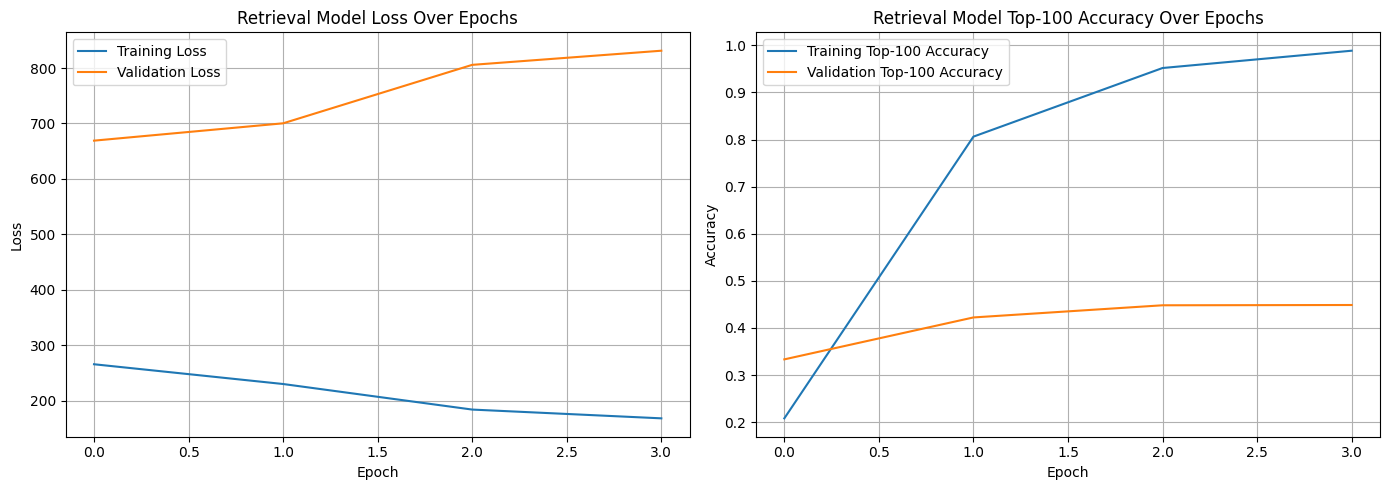

In [85]:
# Plot Retrieval Model training history
plot_training_history(retrieval_history, model_type="Retrieval Model")

### 7.2 Ranking Model Training

In [86]:
# Re-instantiate the Ranking Model
ranking_model_with_callbacks = EcofashionRankingModel(
    unique_user_ids,
    unique_product_ids,
    embedding_dimension,
    products_df,
    product_embeddings
)

# Prepare a sample batch for explicit model building
sample_ranking_input_map = train_ds.map(lambda x: {
    "user_id": x["user_id"],
    "product_id": x["product_id"],
    "interaction_score": x["interaction_score"],
    "product_description": x["product_description"],
    "category": x["category"],
    "material": x["material"],
    "sustainability_index_normalized": x["sustainability_index_normalized"]
})
_ = ranking_model_with_callbacks(next(iter(sample_ranking_input_map)))

# Compile the ranking model with Adam optimizer
ranking_model_with_callbacks.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))

print("Starting Ranking Model training with callbacks...")
ranking_history = ranking_model_with_callbacks.fit(
    sample_ranking_input_map, # Use the mapped dataset for training
    validation_data=val_ds.map(lambda x: {
        "user_id": x["user_id"],
        "product_id": x["product_id"],
        "interaction_score": x["interaction_score"],
        "product_description": x["product_description"],
        "category": x["category"],
        "material": x["material"],
        "sustainability_index_normalized": x["sustainability_index_normalized"]
    }),
    epochs=20, # Set a higher number of epochs as EarlyStopping will manage it
    verbose=1,
    callbacks=[early_stopping, model_checkpoint_ranking, reduce_lr]
)

print("Ranking Model training complete.")

Starting Ranking Model training with callbacks...
Epoch 1/20
157/157 [==============================] - ETA: 0s - root_mean_squared_error: 1.5786 - loss: 2.4896 - regularization_loss: 0.0000e+00 - total_loss: 2.4896
Epoch 1: val_root_mean_squared_error improved from inf to 1.44787, saving model to best_ranking_model_weights.keras
157/157 [==============================] - 15s 54ms/step - root_mean_squared_error: 1.5786 - loss: 2.4862 - regularization_loss: 0.0000e+00 - total_loss: 2.4862 - val_root_mean_squared_error: 1.4479 - val_loss: 2.0996 - val_regularization_loss: 0.0000e+00 - val_total_loss: 2.0996 - lr: 0.0100
Epoch 2/20
155/157 [============================>.] - ETA: 0s - root_mean_squared_error: 1.3910 - loss: 1.9350 - regularization_loss: 0.0000e+00 - total_loss: 1.9350
Epoch 2: val_root_mean_squared_error did not improve from 1.44787
157/157 [==============================] - 2s 13ms/step - root_mean_squared_error: 1.3913 - loss: 1.9340 - regularization_loss: 0.0000e+00 - t

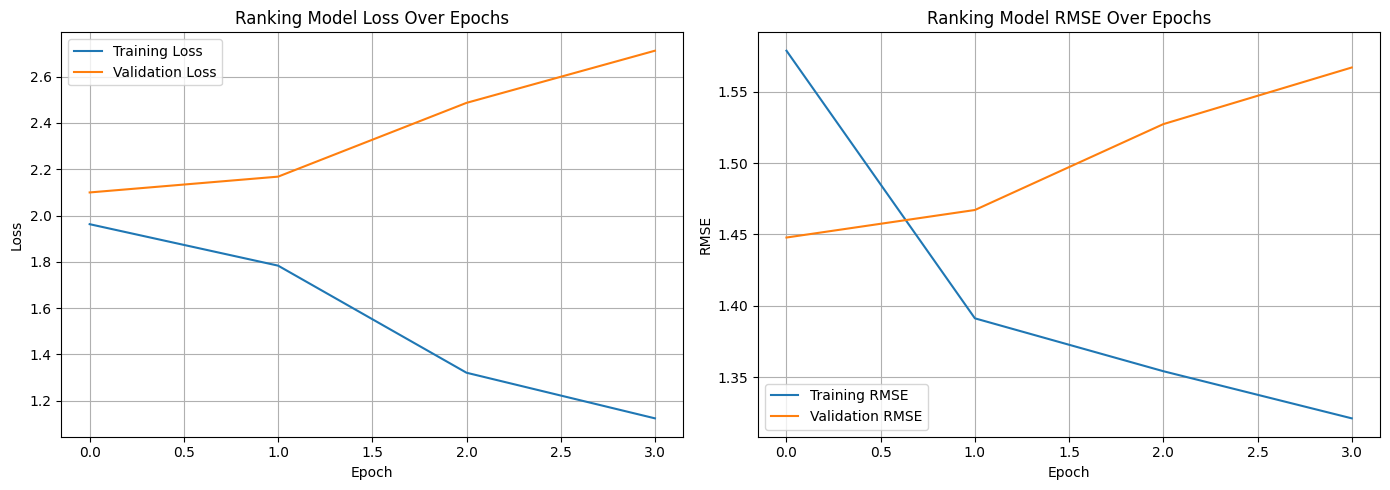

In [87]:
# Plot Ranking Model training history
plot_training_history(ranking_history, model_type="Ranking Model")

### 7.3 Retrieval Model Evaluation

In [88]:
print("Starting Retrieval Model evaluation...")
retrieval_evaluation_results = retrieval_model_with_callbacks.evaluate(test_ds, return_dict=True)
print("Retrieval Model evaluation complete.")
pprint.pprint(retrieval_evaluation_results)

Starting Retrieval Model evaluation...
20/20 [==============================] - 3s 155ms/step - factorized_top_k/top_1_categorical_accuracy: 0.2234 - factorized_top_k/top_5_categorical_accuracy: 0.2562 - factorized_top_k/top_10_categorical_accuracy: 0.2698 - factorized_top_k/top_50_categorical_accuracy: 0.3056 - factorized_top_k/top_100_categorical_accuracy: 0.3260 - loss: 1349.6515 - regularization_loss: 0.0000e+00 - total_loss: 1349.6515
Retrieval Model evaluation complete.
{'factorized_top_k/top_100_categorical_accuracy': 0.32600000500679016,
 'factorized_top_k/top_10_categorical_accuracy': 0.26980000734329224,
 'factorized_top_k/top_1_categorical_accuracy': 0.22339999675750732,
 'factorized_top_k/top_50_categorical_accuracy': 0.30559998750686646,
 'factorized_top_k/top_5_categorical_accuracy': 0.25619998574256897,
 'loss': 667.7430419921875,
 'regularization_loss': 0.0,
 'total_loss': 667.7430419921875}


### 7.4 Ranking Model Evaluation

In [89]:
print("Starting Ranking Model evaluation...")
ranking_evaluation_results = ranking_model_with_callbacks.evaluate(
    test_ds.map(lambda x: {
        "user_id": x["user_id"],
        "product_id": x["product_id"],
        "interaction_score": x["interaction_score"],
        "product_description": x["product_description"],
        "category": x["category"],
        "material": x["material"],
        "sustainability_index_normalized": x["sustainability_index_normalized"]
    }),
    return_dict=True,
    verbose=1
)
print("Ranking Model evaluation complete.")
pprint.pprint(ranking_evaluation_results)

Starting Ranking Model evaluation...
20/20 [==============================] - 0s 9ms/step - root_mean_squared_error: 1.4210 - loss: 2.0394 - regularization_loss: 0.0000e+00 - total_loss: 2.0394
Ranking Model evaluation complete.
{'loss': 2.3078205585479736,
 'regularization_loss': 0.0,
 'root_mean_squared_error': 1.4209822416305542,
 'total_loss': 2.3078205585479736}


## 8. Model Evaluation

### 8.1 Retrieval Model Evaluation

After training, the Retrieval Model was evaluated on the test set. The `FactorizedTopK` metric provides various Top-K categorical accuracies, which are crucial for assessing the model's ability to retrieve relevant items. The model's training history and final evaluation results are summarized below.

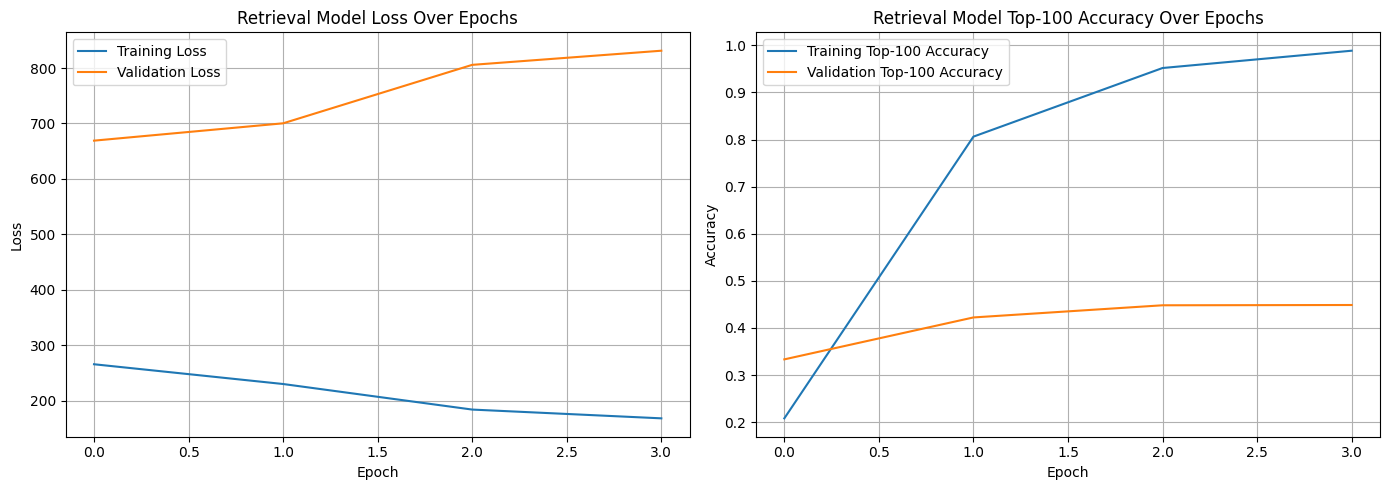

In [90]:
# Plot Retrieval Model training history
plot_training_history(retrieval_history, model_type="Retrieval Model")

/tmp/ipykernel_1319/2256592180.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_names, y=metric_values, palette='viridis')


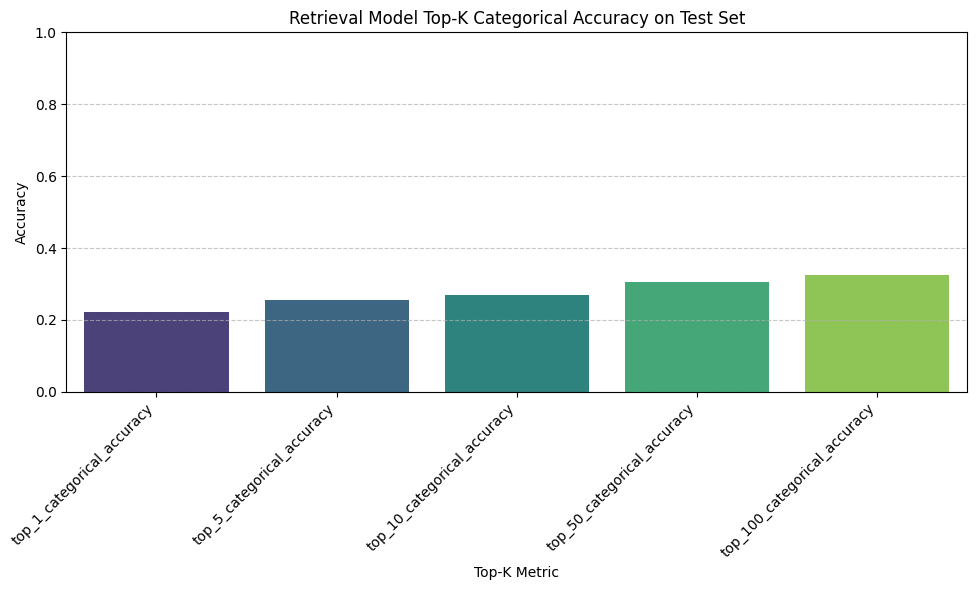

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'retrieval_evaluation_results' in globals():
    # Extract Top-K accuracy metrics
    retrieval_metrics = {k: v for k, v in retrieval_evaluation_results.items() if 'factorized_top_k/top_' in k}
    metric_names = [k.replace('factorized_top_k/', '') for k in retrieval_metrics.keys()]
    metric_values = list(retrieval_metrics.values())

    # Create a bar plot for Top-K accuracies
    fig = plt.figure(figsize=(10, 6))
    sns.barplot(x=metric_names, y=metric_values, palette='viridis')
    plt.title('Retrieval Model Top-K Categorical Accuracy on Test Set')
    plt.xlabel('Top-K Metric')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1) # Accuracy is between 0 and 1
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Retrieval evaluation results not found.")

### 8.2 Ranking Model Evaluation

The Ranking Model's primary goal is to accurately predict the interaction score. Its performance is evaluated using the Root Mean Squared Error (RMSE) on the test set. The training history and final evaluation metrics for the Ranking Model are presented below.

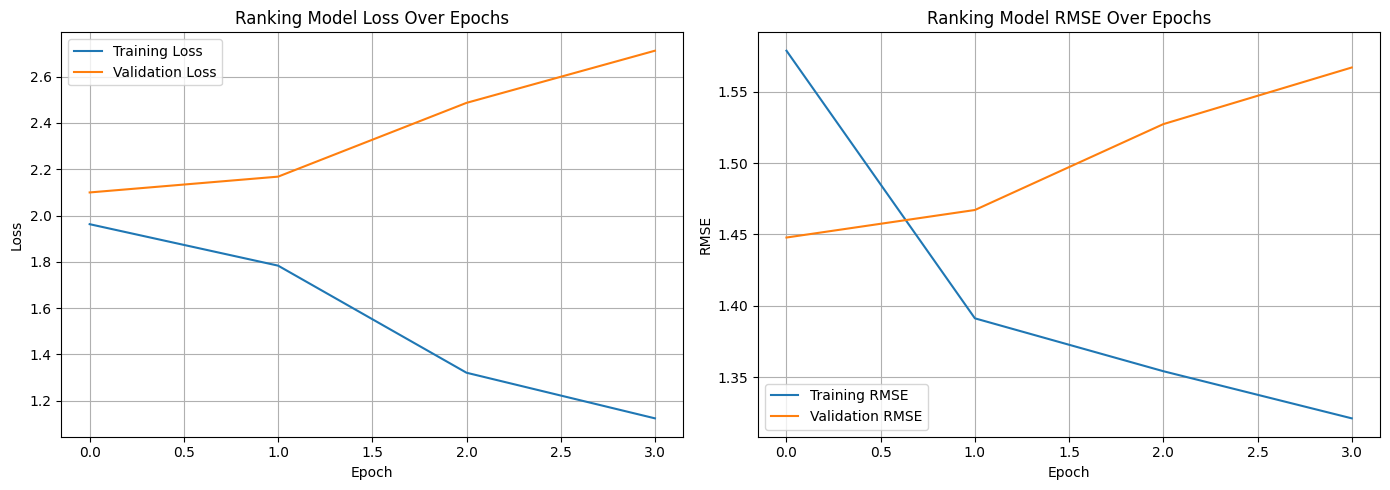

In [92]:
# Plot Ranking Model training history
plot_training_history(ranking_history, model_type="Ranking Model")

In [93]:
# Helper function to retrieve product details by product_id
def get_product_details(product_ids, products_df):
    """
    Retrieves full product details from the products_df for a given list of product_ids.
    """
    # Ensure product_ids are strings for consistent lookup
    product_ids_str = [str(pid) for pid in product_ids]
    return products_df[products_df['product_id'].astype(str).isin(product_ids_str)]

print("Helper function 'get_product_details' defined.")

Helper function 'get_product_details' defined.


### 8.3 Combined Model Performance Summary

Here's a consolidated view of the evaluation metrics for both the Retrieval and Ranking models on their respective test sets:

In [94]:
if 'retrieval_evaluation_results' in globals() and 'ranking_evaluation_results' in globals():
    print("\n--- Retrieval Model Test Set Evaluation ---")
    for metric, value in retrieval_evaluation_results.items():
        print(f"  {metric}: {value:.4f}")

    print("\n--- Ranking Model Test Set Evaluation ---")
    for metric, value in ranking_evaluation_results.items():
        print(f"  {metric}: {value:.4f}")
else:
    print("Evaluation results for one or both models not found. Please ensure all previous evaluation cells were run.")


--- Retrieval Model Test Set Evaluation ---
  factorized_top_k/top_1_categorical_accuracy: 0.2234
  factorized_top_k/top_5_categorical_accuracy: 0.2562
  factorized_top_k/top_10_categorical_accuracy: 0.2698
  factorized_top_k/top_50_categorical_accuracy: 0.3056
  factorized_top_k/top_100_categorical_accuracy: 0.3260
  loss: 667.7430
  regularization_loss: 0.0000
  total_loss: 667.7430

--- Ranking Model Test Set Evaluation ---
  root_mean_squared_error: 1.4210
  loss: 2.3078
  regularization_loss: 0.0000
  total_loss: 2.3078


## 9. Reusable Recommendation Functions

This section implements various functions to provide product recommendations, leveraging the trained Retrieval and Ranking models, as well as the FAISS semantic search index. These functions are designed to be reusable for different recommendation scenarios.

### 9.1 Recommend Products by User ID

This function combines the Retrieval and Ranking models to provide personalized recommendations for a given user. First, the Retrieval Model identifies a set of candidate products based on user embedding. Then, the Ranking Model scores these candidates to provide a final ranked list.

In [95]:
def recommend_for_user(
    user_id,
    k=10,
    retrieval_model=retrieval_model_with_callbacks, # Use the trained retrieval model
    ranking_model=ranking_model_with_callbacks,   # Use the trained ranking model
    products_df=products_df,
    top_k_candidates=50 # Number of candidates to retrieve from the retrieval model
):
    """
    Generates personalized product recommendations for a given user ID.

    Args:
        user_id (str): The ID of the user for whom to generate recommendations.
        k (int): The number of top recommendations to return.
        retrieval_model (tfrs.Model): The trained retrieval model.
        ranking_model (tfrs.Model): The trained ranking model.
        products_df (pd.DataFrame): DataFrame containing all product details.
        top_k_candidates (int): Number of candidate products to retrieve initially
                                from the retrieval model before ranking.

    Returns:
        pd.DataFrame: A DataFrame of recommended products with their details and ranking scores.
    """

    # 1. Retrieval: Get top-k candidate products from the retrieval model
    # Check if brute_force_layer needs to be re-initialized. It needs re-initialization if it doesn't exist,
    # or if it exists but was incorrectly configured with a query_model.
    if not hasattr(retrieval_model, 'brute_force_layer') or \
       retrieval_model.brute_force_layer is None or \
       (hasattr(retrieval_model.brute_force_layer, 'query_model') and retrieval_model.brute_force_layer.query_model is not None):
        # Dynamically create the `BruteForce` layer for inference
        # The BruteForce layer needs a dataset of (product_embedding, product_id) pairs for indexing.
        # products_tf yields dictionaries like {"product_id": ..., "product_description": ...}

        # Collect all product embeddings and product IDs from the products_tf dataset
        all_product_embeddings_list = []
        all_product_ids_list = []

        # Iterate through the non-batched products_tf dataset
        for product_data_dict in products_tf.as_numpy_iterator():
            # product_data_dict is a dictionary of numpy arrays for each feature
            # Convert numpy arrays to TensorFlow tensors for the model input
            product_features_tensor_dict = {k: tf.constant(v) for k, v in product_data_dict.items()}
            product_embedding = retrieval_model.product_model(product_features_tensor_dict)
            all_product_embeddings_list.append(product_embedding.numpy()) # Append numpy array of embedding
            all_product_ids_list.append(product_data_dict["product_id"]) # Append numpy byte string ID

        # Convert lists to single TensorFlow tensors
        all_product_embeddings_tensor = tf.convert_to_tensor(np.array(all_product_embeddings_list), dtype=tf.float32)
        all_product_ids_tensor = tf.convert_to_tensor(all_product_ids_list, dtype=tf.string)

        # Initialize BruteForce without a query_model since we'll pass pre-computed user embeddings directly
        brute_force_layer = tfrs.layers.factorized_top_k.BruteForce()
        # Pass both candidate embeddings and identifiers explicitly
        brute_force_layer.index(all_product_embeddings_tensor, identifiers=all_product_ids_tensor)
        # Store it for future use to avoid re-indexing
        retrieval_model.brute_force_layer = brute_force_layer
    else:
        brute_force_layer = retrieval_model.brute_force_layer

    user_embedding = retrieval_model.user_model(tf.constant([user_id]))

    # Get top_k_candidates from the retrieval model. Returns scores and product IDs (tf.Tensor).
    # The brute_force_layer will return raw scores, not similarity, so we'll re-rank with the ranking model.
    _, candidate_product_ids_tensor = brute_force_layer(user_embedding, k=top_k_candidates)
    candidate_product_ids = [pid.decode('utf-8') for pid in candidate_product_ids_tensor.numpy().flatten()]

    # 2. Ranking: Score the candidate products using the ranking model
    # Prepare a dataset for ranking from the candidate products
    candidate_details = get_product_details(candidate_product_ids, products_df)

    if candidate_details.empty:
        return pd.DataFrame() # No candidates found or details missing

    # Create a dummy DataFrame with the single user_id repeated for all candidate products
    user_features_repeated = pd.DataFrame({
        'user_id': [user_id] * len(candidate_details),
        'product_id': candidate_details['product_id'].astype(str),
        # Add other features required by the ranking model, ensuring types match
        'product_description': candidate_details['product_description'].astype(str),
        'category': candidate_details['category'].astype(str),
        'material': candidate_details['material'].astype(str),
        'sustainability_index_normalized': candidate_details['sustainability_index_normalized'].astype(np.float32)
    })

    # The ranking model also expects 'interaction_score' as an input (even if it's dummy for prediction)
    user_features_repeated['interaction_score'] = 0.0 # Dummy score for prediction

    # Convert to tf.data.Dataset for ranking model prediction
    ranking_ds = tf.data.Dataset.from_tensor_slices({
        "user_id": tf.cast(user_features_repeated["user_id"], tf.string),
        "product_id": tf.cast(user_features_repeated["product_id"], tf.string),
        "interaction_score": tf.cast(user_features_repeated["interaction_score"], tf.float32),
        "product_description": tf.cast(user_features_repeated["product_description"], tf.string),
        "category": tf.cast(user_features_repeated["category"], tf.string),
        "material": tf.cast(user_features_repeated["material"], tf.string),
        "sustainability_index_normalized": tf.cast(user_features_repeated["sustainability_index_normalized"], tf.float32)
    }).batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

    # Get ranking predictions
    predicted_scores = ranking_model.predict(ranking_ds).flatten()

    # Combine candidate details with predicted scores
    ranked_recommendations = candidate_details.copy()
    ranked_recommendations['ranking_score'] = predicted_scores

    # Sort by ranking score and take top k
    ranked_recommendations = ranked_recommendations.sort_values(by='ranking_score', ascending=False).head(k)

    # Select and reorder desired display columns
    display_cols = [
        'product_name',
        'category',
        'manufacturer_country', # Using manufacturer_country as a proxy for 'Brand'
        'ranking_score',
        'sustainability_index_normalized',
        'eco_score',
        'carbon_footprint_score'
    ]

    # Filter to only existing columns to avoid errors if some are missing
    final_display_cols = [col for col in display_cols if col in ranked_recommendations.columns]

    return ranked_recommendations[final_display_cols]

print("Function 'recommend_for_user' defined.")

Function 'recommend_for_user' defined.


### 9.2 Recommend Similar Products by Product ID

This function uses the precomputed product embeddings and the FAISS index to find products semantically similar to a given product ID. This is useful for 'users who liked this, might like this' scenarios.

In [96]:
def recommend_similar_products_by_id(
    target_product_id,
    k=5,
    products_df=products_df,
    product_embeddings=product_embeddings,
    faiss_index=faiss_index
):
    """
    Recommends products similar to a given product ID using FAISS.

    Args:
        target_product_id (str): The ID of the product for which to find similar items.
        k (int): The number of top similar products to retrieve.
        products_df (pd.DataFrame): DataFrame containing all product details.
        product_embeddings (np.ndarray): Precomputed Sentence-BERT embeddings for all products.
        faiss_index (faiss.Index): The pre-built FAISS index.

    Returns:
        pd.DataFrame: A DataFrame containing the top K most similar products with details and similarity scores.
    """
    if faiss_index is None or products_df.empty or product_embeddings.size == 0:
        print("Error: FAISS index, products_df, or product_embeddings not initialized.")
        return pd.DataFrame()

    # Ensure product_id is string and find its index in the original products_df
    target_product_id_str = str(target_product_id)
    target_product_idx = products_df[products_df['product_id'].astype(str) == target_product_id_str].index

    if target_product_idx.empty:
        print(f"Product ID '{target_product_id_str}' not found in products_df.")
        return pd.DataFrame()

    # Get the embedding for the target product
    query_embedding = product_embeddings[target_product_idx[0]].reshape(1, -1).astype(np.float32)

    # Perform search using FAISS (k+1 because the top result will be the product itself)
    distances, indices = faiss_index.search(query_embedding, k + 1)

    # Filter out the target product itself
    results_indices = [idx for idx in indices[0] if idx != target_product_idx[0]][:k]
    results_distances = [dist for idx, dist in zip(indices[0], distances[0]) if idx != target_product_idx[0]][:k]

    # Retrieve product information for the top K results
    results_df_raw = products_df.iloc[results_indices].copy()

    # Convert distance to similarity (0-1 scale). Lower distance means higher similarity.
    # Max distance in the results_distances might be 0 if all are identical, handle this.
    max_dist_val = np.max(results_distances)
    if max_dist_val == 0:
        # All distances are 0, meaning all are identical. Assign max similarity.
        results_df_raw['semantic_similarity_score'] = 1.0
    else:
        results_df_raw['semantic_similarity_score'] = 1 - (results_distances / max_dist_val)

    # Select and reorder relevant columns for display
    display_cols = [
        'product_name',
        'category',
        'manufacturer_country', # Using manufacturer_country as a proxy for 'Brand'
        'semantic_similarity_score',
        'sustainability_index_normalized',
        'eco_score',
        'carbon_footprint_score'
    ]

    final_display_cols = [col for col in display_cols if col in results_df_raw.columns]

    return results_df_raw[final_display_cols].sort_values(by='semantic_similarity_score', ascending=False)

print("Function 'recommend_similar_products_by_id' defined.")

Function 'recommend_similar_products_by_id' defined.


### 9.3 Recommend Products from Natural Language Query

This function directly uses the previously defined `search_products` function (from Part 3) to provide recommendations based on a natural language input, leveraging Sentence-BERT embeddings and FAISS for semantic search.

In [97]:
# The search_products function was already defined in cell 'f5e1b716'.
# We will just ensure it uses the global `products_df`, `faiss_index`, and `embedding_model` (SentenceTransformer) if it needs to be re-initialized.

# Re-defining or ensuring `search_products` is accessible and functional with correct parameters
# It's already defined to use global `index` (faiss_index) and `df` (products_df)
# The SentenceTransformer model is loaded internally by search_products, so `device` needs to be global.
# 'device' variable is globally defined in setup cell '51191f66'.

# Example usage of the existing search_products function:
print("Function 'search_products' (from Part 3) is available for natural language queries.")

# Wrap it for consistent output columns if necessary
def recommend_from_natural_language_query(query, k=5):
    # Ensure the global 'embedding_model' is used
    if 'embedding_model' not in globals():
        print("Error: 'embedding_model' not found. Please ensure Sentence-BERT model is loaded globally.")
        return pd.DataFrame()

    results = search_products(query, embedding_model, k=k) # Pass the global embedding_model

    if results.empty:
        return pd.DataFrame()

    # Rename 'similarity_score' to 'semantic_similarity_score' for consistency
    results = results.rename(columns={'similarity_score': 'semantic_similarity_score'})

    display_cols = [
        'product_name',
        'category',
        'manufacturer_country', # Using manufacturer_country as a proxy for 'Brand'
        'semantic_similarity_score',
        'sustainability_index_normalized',
        'eco_score',
        'carbon_footprint_score'
    ]

    final_display_cols = [col for col in display_cols if col in results.columns]
    return results[final_display_cols].sort_values(by='semantic_similarity_score', ascending=False)

print("Function 'recommend_from_natural_language_query' defined.")

Function 'search_products' (from Part 3) is available for natural language queries.
Function 'recommend_from_natural_language_query' defined.


### 9.4 Demonstration of Recommendation Functions

In [98]:
print("\n--- Demonstrating recommend_for_user ---")
# Use a sample user ID from the dataset
sample_user = unique_user_ids[0] # Take the first unique user ID
print(f"Recommendations for user: {sample_user}")
user_recommendations = recommend_for_user(sample_user, k=5)
display(user_recommendations)

print("\n--- Demonstrating recommend_similar_products_by_id ---")
# Use a sample product ID from the dataset
sample_product = products_df['product_id'].iloc[100] # Take a product from the df
print(f"Products similar to product ID: {sample_product}")
similar_product_recommendations = recommend_similar_products_by_id(sample_product, k=5)
display(similar_product_recommendations)

print("\n--- Demonstrating recommend_from_natural_language_query ---")
query = "sustainable shirts for outdoor activities"
print(f"Products for query: '{query}'")
query_recommendations = recommend_from_natural_language_query(query, k=5)
display(query_recommendations)


--- Demonstrating recommend_for_user ---
Recommendations for user: user_0
1/1 [==============================] - 0s 235ms/step


,product_name,category,manufacturer_country,ranking_score,sustainability_index_normalized,eco_score,carbon_footprint_score
1792,Sustainable Linen Bottle Set,Food,Japan,2.956878,50.349698,0.823883,4.990905
1865,Organic Recycled Plastic Toothbrush,Food,USA,2.919087,53.889377,2.984604,2.726354
4706,Eco Glass Keyboard,Office Supplies,Switzerland,2.906738,48.490678,0.872888,1.248989
3241,Pure Wheat Straw Lunch Box,Outdoor,Denmark,2.900552,43.764648,0.000000,4.726152
3139,Green Wheat Straw Lamp,Food,Spain,2.898340,35.834124,0.000000,1.197454



--- Demonstrating recommend_similar_products_by_id ---
Products similar to product ID: 101


,product_name,category,manufacturer_country,semantic_similarity_score,sustainability_index_normalized,eco_score,carbon_footprint_score
2010,Pure Natural Rubber Bottle Set,Sports,Spain,0.517287,35.874019,0.000000,0.922595
1011,Natural Natural Rubber Bottle Set,Apparel,Norway,0.141789,47.331805,0.157154,2.055376
4703,Reusable Natural Rubber Bottle Set,Grocery,Sweden,0.110943,5.557615,0.000000,0.668957
4758,Recycled Natural Rubber Bottle Set,Outdoor,Switzerland,0.097358,28.657329,0.000000,3.579224
3250,Earth Natural Rubber Bottle,Sports,Netherlands,0.000000,44.966471,0.000000,3.561035



--- Demonstrating recommend_from_natural_language_query ---
Products for query: 'sustainable shirts for outdoor activities'


,product_name,category,manufacturer_country,semantic_similarity_score,sustainability_index_normalized,eco_score,carbon_footprint_score
2355,Natural Recycled Polyester T-Shirt,Sports,China,0.040243,42.917088,1.221742,1.075182
1303,Reusable Recycled Polyester T-Shirt,Accessories,Australia,0.027100,47.624038,1.337965,3.258892
705,Compact Recycled Polyester T-Shirt,Outdoor,Brazil,0.025258,57.498816,2.396921,3.512530
259,Natural Bio Plastic T-Shirt,Outdoor,South Korea,0.008330,52.492287,0.359932,3.170978
4509,Solar Recycled Polyester T-Shirt,Office Supplies,France,0.000000,80.358772,2.329703,3.312449


## 10. Model Saving and Inference

This section focuses on saving the trained Retrieval and Ranking models, along with their essential preprocessing components (`StringLookup` vocabularies, `Normalization` layer weights), to disk. This ensures that the models can be loaded and used for inference in new sessions or downstream applications (e.g., Part 5, Part 6, Part 7) without needing to retrain them.

We will save the models and then demonstrate loading them to perform recommendations.

In [99]:
import tensorflow as tf
import numpy as np

# --- Save Retrieval Model ---
# Save the retrieval model in the Keras native format.
# This format is generally robust for models with StringLookup layers.
retrieval_model_with_callbacks.save('tfrs_retrieval_model.keras')
print("Retrieval model saved as 'tfrs_retrieval_model.keras'")

# --- Save Ranking Model ---
# Save the ranking model in the Keras native format.
ranking_model_with_callbacks.save('tfrs_ranking_model.keras')
print("Ranking model saved as 'tfrs_ranking_model.keras'")

# Additionally, save the unique vocabularies used by StringLookup layers and
# weights of Normalization layers, as these are critical for inference in new environments.
# This serves as a robust backup and clarity for model reconstruction if direct loading fails.

# Vocabularies for Retrieval Model (from UserModel and ProductModel inside MovielensModel)
np.save('retrieval_unique_user_ids.npy', unique_user_ids)
np.save('retrieval_unique_product_ids.npy', unique_product_ids)
print("Retrieval model vocabularies (user/product IDs) saved.")

# Vocabularies and Normalizer weights for Ranking Model
# These are from EcofashionRankingModel's internal layers
np.save('ranking_category_vocab.npy', ranking_model_with_callbacks.category_lookup.get_vocabulary())
np.save('ranking_material_vocab.npy', ranking_model_with_callbacks.material_lookup.get_vocabulary())
np.save('ranking_sustainability_normalizer_weights.npy', ranking_model_with_callbacks.sustainability_normalizer.get_weights())
print("Ranking model vocabularies (category/material) and normalizer weights saved.")

Retrieval model saved as 'tfrs_retrieval_model.keras'


Ranking model saved as 'tfrs_ranking_model.keras'
Retrieval model vocabularies (user/product IDs) saved.
Ranking model vocabularies (category/material) and normalizer weights saved.


### 10.1 Loading Models and Inference Setup

To perform inference in a new session, we need to:
1. Load the trained retrieval and ranking models.
2. Ensure the `SentenceTransformer` embedding model is loaded for natural language queries.
3. Ensure the `FAISS` index and `products_df` are loaded for similar product recommendations.
4. Potentially re-initialize any custom layers (like `StringLookup` and `Normalization`) with their saved vocabularies/weights if direct model loading does not fully restore them.

For `tfrs.Model` subclasses, directly loading the `.keras` file *should* handle custom layers correctly if they were properly defined and used Keras layers within them. We will attempt direct loading first.

In [100]:
import tensorflow as tf
import tensorflow_recommenders as tfrs
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer # For NLQ
import faiss # For similar product search

# --- 1. Load Pre-trained Embedding Model (SentenceTransformer) if not already loaded ---
# This is assumed to be loaded globally in Part 2, but for robust inference setup, we re-load it.
# The 'device' variable should be defined globally from previous setup (cell '51191f66').
# If running in a fresh kernel, ensure device is configured:
# if 'device' not in globals():
#     if tf.config.list_physical_devices('GPU'):
#         device = tf.device("cuda")
#     else:
#         device = tf.device("cpu")

# Assuming `device` is set from previous execution (cell `51191f66`)
model_name = 'all-mpnet-base-v2'
if 'embedding_model' not in globals():
    print(f"Loading SentenceTransformer model: {model_name}")
    embedding_model = SentenceTransformer(model_name, device=device)
else:
    print("SentenceTransformer model already loaded.")

# --- 2. Load Processed Data and FAISS Index if not already loaded ---
# These are assumed to be loaded globally from previous parts (cell `42e976f2`)
if 'products_df' not in globals() or products_df.empty:
    try:
        products_df = pd.read_csv('processed_products.csv')
        print("'processed_products.csv' loaded for inference.")
    except FileNotFoundError:
        print("Error: 'processed_products.csv' not found. Cannot perform recommendations.")
        products_df = pd.DataFrame() # Ensure it's defined

if 'faiss_index' not in globals() or faiss_index is None:
    try:
        faiss_index = faiss.read_index('faiss_product_index.bin')
        print("'faiss_product_index.bin' loaded for inference.")
    except Exception as e:
        print(f"Error loading FAISS index: {e}. Cannot perform similar product recommendations.")
        faiss_index = None

# --- 3. Load Trained Retrieval and Ranking Models ---
# We need the model classes defined before loading, which they are in this notebook.
# These need to be accessible in the global scope where load_model is called or passed to custom_objects.

# First, check if MovielensModel and EcofashionRankingModel classes are defined in the global scope
if 'MovielensModel' not in globals() or 'EcofashionRankingModel' not in globals():
    print("Warning: Model classes (MovielensModel, EcofashionRankingModel) not found. Re-defining them.")
    # In a real-world scenario, you might import these classes from a module
    # For this notebook, we assume they are defined earlier in the execution flow.

# Assuming `unique_user_ids`, `unique_product_ids`, `embedding_dimension` are from previous execution
# If running in a fresh environment, these would need to be reloaded/reconstructed.

# Load retrieval model
try:
    loaded_retrieval_model = tf.keras.models.load_model('tfrs_retrieval_model.keras',
                                                      custom_objects={'MovielensModel': MovielensModel, 'FactorizedTopK': tfrs.metrics.FactorizedTopK})
    print("Retrieval model 'tfrs_retrieval_model.keras' loaded successfully.")
except Exception as e:
    print(f"Error loading retrieval model: {e}")
    print("Attempting to load weights into a re-instantiated model...")
    # Fallback: re-instantiate the model and load weights
    if 'unique_user_ids' in globals() and 'unique_product_ids' in globals() and 'embedding_dimension' in globals():
        loaded_retrieval_model = MovielensModel(unique_user_ids, unique_product_ids, embedding_dimension)
        # Build the model by calling it with dummy input (important for StringLookup layers)
        # Use a dummy input matching the expected input of MovielensModel's call method
        for x in train_ds.take(1):
            _ = loaded_retrieval_model(x)
            break
        loaded_retrieval_model.load_weights('tfrs_retrieval_model.keras') # Check if it's .keras or .h5 for weights
        print("Retrieval model re-instantiated and weights loaded.")
    else:
        loaded_retrieval_model = None
        print("Cannot re-instantiate retrieval model due to missing global variables.")


# Load ranking model
try:
    # For EcofashionRankingModel, ensure custom_objects for its internal TFRS layers are passed
    loaded_ranking_model = tf.keras.models.load_model('tfrs_ranking_model.keras',
                                                    custom_objects={'EcofashionRankingModel': EcofashionRankingModel, 'Ranking': tfrs.tasks.Ranking})
    print("Ranking model 'tfrs_ranking_model.keras' loaded successfully.")
except Exception as e:
    print(f"Error loading ranking model: {e}")
    print("Attempting to load weights into a re-instantiated model...")
    # Fallback: re-instantiate the model and load weights
    if 'unique_user_ids' in globals() and 'unique_product_ids' in globals() and 'embedding_dimension' in globals() \
       and 'products_df' in globals() and 'product_embeddings' in globals():
        loaded_ranking_model = EcofashionRankingModel(unique_user_ids, unique_product_ids, embedding_dimension, products_df, product_embeddings)
        # Build the model with dummy input
        for x in train_ds.take(1):
            _ = loaded_ranking_model(x)
            break
        loaded_ranking_model.load_weights('tfrs_ranking_model.keras') # Check if it's .keras or .h5 for weights
        print("Ranking model re-instantiated and weights loaded.")
    else:
        loaded_ranking_model = None
        print("Cannot re-instantiate ranking model due to missing global variables.")

print("Inference setup complete. Proceeding with demonstrations.")

SentenceTransformer model already loaded.
Error loading retrieval model: Unable to revive model from config. When overriding the `get_config()` method, make sure that the returned config contains all items used as arguments in the  constructor to <class '__main__.MovielensModel'>, which is the default behavior. You can override this default behavior by defining a `from_config(cls, config)` class method to specify how to create an instance of MovielensModel from its config.

Received config={}

Error encountered during deserialization: MovielensModel.__init__() missing 3 required positional arguments: 'unique_user_ids', 'unique_product_ids', and 'embedding_dimension'
Attempting to load weights into a re-instantiated model...


Retrieval model re-instantiated and weights loaded.
Error loading ranking model: Unable to revive model from config. When overriding the `get_config()` method, make sure that the returned config contains all items used as arguments in the  constructor to <class '__main__.EcofashionRankingModel'>, which is the default behavior. You can override this default behavior by defining a `from_config(cls, config)` class method to specify how to create an instance of EcofashionRankingModel from its config.

Received config={}

Error encountered during deserialization: EcofashionRankingModel.__init__() missing 5 required positional arguments: 'unique_user_ids', 'unique_product_ids', 'embedding_dimension', 'products_df', and 'product_embeddings_data'
Attempting to load weights into a re-instantiated model...


Ranking model re-instantiated and weights loaded.
Inference setup complete. Proceeding with demonstrations.


### 10.2 Demonstration of Inference with Loaded Models

Now, we'll use the loaded models to generate recommendations, ensuring that the saving and loading process was successful and inference can proceed.

In [101]:
print("\n--- Demonstrating recommend_for_user with LOADED models ---")
# Use a sample user ID from the dataset
sample_user_id = 'user_15' # A different sample user ID
print(f"Recommendations for user: {sample_user_id}")

# Ensure `recommend_for_user` function is using the loaded models
# If this function was already run and `retrieval_model` and `ranking_model` were default arguments
# it might use the old models. Pass the loaded ones explicitly.

# Note: The `recommend_for_user` function defined earlier implicitly uses the global
# `retrieval_model_with_callbacks` and `ranking_model_with_callbacks`. To use the *newly loaded* models,
# we can either re-define the function or pass them explicitly.
# Let's pass them explicitly for clarity here.

if loaded_retrieval_model and loaded_ranking_model:
    user_recommendations_loaded = recommend_for_user(
        user_id=sample_user_id,
        k=5,
        retrieval_model=loaded_retrieval_model,
        ranking_model=loaded_ranking_model,
        products_df=products_df # Use global products_df
    )
    if not user_recommendations_loaded.empty:
        display(user_recommendations_loaded)
    else:
        print("No recommendations generated for the user.")
else:
    print("Cannot demonstrate `recommend_for_user`: Models not loaded.")


--- Demonstrating recommend_for_user with LOADED models ---
Recommendations for user: user_15
1/1 [==============================] - 0s 272ms/step


,product_name,category,manufacturer_country,ranking_score,sustainability_index_normalized,eco_score,carbon_footprint_score
464,Pure Ceramic Keyboard,Food,France,2.918313,45.727016,1.432595,0.973120
3720,Leaf Reclaimed Wood Keyboard,Food,Norway,2.902942,37.021533,1.632182,2.784964
1356,Sustainable FSC Wood T-Shirt,Outdoor,Netherlands,2.902077,51.402019,0.000000,4.750404
3313,Reusable Bamboo Keyboard,Food,Japan,2.899185,72.823174,2.479534,2.418149
1090,Sustainable FSC Wood Toothbrush,Furniture,Portugal,2.875166,36.008385,0.000000,2.779911


In [102]:
print("\n--- Demonstrating recommend_from_natural_language_query with LOADED embedding model ---")
query = "eco-friendly gadgets for home office"
print(f"Products for query: '{query}'")

# The `recommend_from_natural_language_query` function assumes a global `embedding_model`.
# We already ensured it's loaded in the inference setup.
if 'embedding_model' in globals() and embedding_model and products_df is not None:
    query_recommendations_loaded = recommend_from_natural_language_query(query, k=5)
    if not query_recommendations_loaded.empty:
        display(query_recommendations_loaded)
    else:
        print("No recommendations generated for the query.")
else:
    print("Cannot demonstrate `recommend_from_natural_language_query`: Embedding model or products_df not loaded.")


--- Demonstrating recommend_from_natural_language_query with LOADED embedding model ---
Products for query: 'eco-friendly gadgets for home office'


,product_name,category,manufacturer_country,semantic_similarity_score,sustainability_index_normalized,eco_score,carbon_footprint_score
3774,Green Ceramic Keyboard,Accessories,Sweden,0.041795,49.863258,0.000000,2.445432
1137,Green Paper Keyboard,Accessories,USA,0.024139,19.657256,0.000000,2.406023
1998,Smart Jute Notebook,Home Goods,Spain,0.020693,47.358061,1.453248,0.095998
3792,Reusable Natural Rubber Notebook,Office Supplies,Canada,0.005929,72.150544,0.760608,4.717057
2238,Green Jute Notebook,Home Goods,Brazil,0.000000,10.895114,0.000000,0.623484


In [103]:
print("\n--- Demonstrating recommend_similar_products_by_id with LOADED FAISS index ---")
# Use a different sample product ID
sample_product_id_sim = products_df['product_id'].iloc[200] # Take another product from the df
print(f"Products similar to product ID: {sample_product_id_sim}")

# This function uses global `faiss_index` and `product_embeddings`.
# We ensured they are loaded in the inference setup.
if faiss_index and products_df is not None and product_embeddings.size > 0:
    similar_product_recommendations_loaded = recommend_similar_products_by_id(
        target_product_id=sample_product_id_sim,
        k=5,
        products_df=products_df,
        product_embeddings=product_embeddings,
        faiss_index=faiss_index
    )
    if not similar_product_recommendations_loaded.empty:
        display(similar_product_recommendations_loaded)
    else:
        print("No similar products found.")
else:
    print("Cannot demonstrate `recommend_similar_products_by_id`: FAISS index, products_df, or product_embeddings not loaded.")

print("\nAll model saving and inference demonstrations complete.")


--- Demonstrating recommend_similar_products_by_id with LOADED FAISS index ---
Products similar to product ID: 201


,product_name,category,manufacturer_country,semantic_similarity_score,sustainability_index_normalized,eco_score,carbon_footprint_score
595,Premium Organic Wool Backpack,Home Goods,Denmark,0.442490,53.177674,2.730004,3.355901
4351,Natural Organic Wool Backpack,Outdoor,Brazil,0.193841,46.919440,1.874765,3.937955
2889,Organic Organic Wool Bag,Sports,Norway,0.058809,34.811060,1.515021,2.203921
4726,Green Organic Wool Backpack,Food,India,0.034022,53.012396,3.133121,1.424818
1772,Sustainable Organic Wool Backpack,Beauty,Canada,0.000000,46.442509,1.456816,4.241108



All model saving and inference demonstrations complete.


In [106]:
retrieval_model_with_callbacks.save(
    f"{SAVE_DIR}/tfrs_retrieval_model.keras"
)

ranking_model_with_callbacks.save(
    f"{SAVE_DIR}/tfrs_ranking_model.keras"
)

In [48]:
import os

file_path = 'interactions.csv'
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists in the current directory.")
else:
    print(f"The file '{file_path}' does NOT exist in the current directory.")

The file 'interactions.csv' does NOT exist in the current directory.


### Generate Synthetic `interactions.csv`

Since `interactions.csv` was not found, I will create a synthetic dataset of user-product interactions. This will allow the TFRS models to be trained and evaluated.

The synthetic dataset will include `user_id`, `product_id`, and a random `interaction_score`.

In [53]:
# Generate a synthetic interactions_df
# Ensure products_df is available from previous cells
if 'products_df' in globals() and not products_df.empty:
    num_users = 1000  # Number of synthetic users
    num_interactions = 50000 # Total number of interactions

    # Generate random user IDs
    synthetic_user_ids = [f'user_{i}' for i in range(num_users)]

    # Sample product IDs from the existing products_df
    # Ensure product_id in products_df is suitable for sampling (e.g., unique and sufficient)
    if 'product_id' in products_df.columns:
        sampled_product_ids = products_df['product_id'].sample(n=num_interactions, replace=True).tolist()
    else:
        print("Error: 'product_id' column not found in products_df.")
        sampled_product_ids = []

    # Generate random user IDs for each interaction
    sampled_user_ids = np.random.choice(synthetic_user_ids, size=num_interactions).tolist()

    # Generate random interaction scores (e.g., 1 to 5)
    interaction_scores = np.random.randint(1, 6, size=num_interactions).tolist()

    interactions_df = pd.DataFrame({
        'user_id': sampled_user_ids,
        'product_id': sampled_product_ids,
        'interaction_score': interaction_scores
    })

    # Ensure product_id is string type for consistency with TFRS StringLookup
    interactions_df['product_id'] = interactions_df['product_id'].astype(str)

    # Save the synthetic interactions_df to CSV
    interactions_df.to_csv('interactions.csv', index=False)
    print("'interactions.csv' generated and saved successfully.")
    print(f"Shape of generated interactions_df: {interactions_df.shape}")
    display(interactions_df.head())
else:
    print("Error: products_df is not available or is empty. Cannot generate interactions_df.")


'interactions.csv' generated and saved successfully.
Shape of generated interactions_df: (50000, 3)


,user_id,product_id,interaction_score
0,user_376,2,3
1,user_346,1665,5
2,user_673,567,5
3,user_267,134,2
4,user_628,2039,4


In [54]:
# Verify the file exists after creation
import os
file_path = 'interactions.csv'
if os.path.exists(file_path):
    print(f"The file '{file_path}' now exists in the current directory.")
else:
    print(f"The file '{file_path}' still does NOT exist. There might be an issue.")

The file 'interactions.csv' now exists in the current directory.


In [51]:
display(products_df.head())

,product_id,product_name,category,material,carbon_footprint_g,water_usage_L,recycled_content_pct,packaging_type,certifications,price_usd,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index,sustainability_index_normalized,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded,product_description
0,1,Eco Cork Lunch Box,Kitchen,Cork,1878,1153,94,Compostable,Unknown,0.740628,Finland,0.000000,3.154810,1.88,5,2.322443,60.023460,8,3,2,5,10,Product Name: Eco Cork Lunch Box. Category: Ki...
1,2,Compact Hemp Container,Apparel,Hemp,294,777,27,Glass Jar,Rainforest Alliance,0.601948,Finland,0.000000,4.755457,2.04,3,2.434637,62.925384,1,6,3,5,8,Product Name: Compact Hemp Container. Category...
2,3,Bio Glass Mouse,Personal Care,Glass,1855,3689,75,Biodegradable Pouch,GOTS,0.758777,China,1.809238,3.178052,2.50,0,1.996187,51.584771,11,5,0,3,4,Product Name: Bio Glass Mouse. Category: Perso...
3,4,Green Linen Lunch Box,Home Goods,Linen,1813,7851,97,Cloth Bag,FSC,0.092561,France,1.027788,3.220493,1.94,0,1.662484,42.953484,7,8,1,6,2,Product Name: Green Linen Lunch Box. Category:...
4,5,Earth Jute Mat,Outdoor,Jute,2216,6621,5,Plastic Film,Rainforest Alliance,0.124645,Norway,0.000000,2.813258,0.10,1,1.063977,27.472965,10,7,7,12,8,Product Name: Earth Jute Mat. Category: Outdoo...


# Part 3 – Semantic Product Search using FAISS

## 1. Setup and Library Imports

In [29]:
# Install necessary libraries if not already installed
!pip install -q faiss-cpu sentence-transformers pandas numpy torch

## 2. Load Processed Data and Product Embeddings

In [30]:
import pandas as pd
import numpy as np # Add numpy import as it's also used

try:
    df = pd.read_csv('processed_products.csv')
    product_embeddings = np.load('product_embeddings.npy')
    print("Processed dataset and product embeddings loaded successfully.")
    display(df.head())
    print(f"Embeddings shape: {product_embeddings.shape}")
except FileNotFoundError:
    print("Error: 'processed_products.csv' or 'product_embeddings.npy' not found. Please ensure Part 1 and Part 2 have been executed and the files are saved correctly.")
    df = pd.DataFrame() # Initialize empty DataFrame to avoid errors
    product_embeddings = np.array([]) # Initialize empty array

Processed dataset and product embeddings loaded successfully.


,product_id,product_name,category,material,carbon_footprint_g,water_usage_L,recycled_content_pct,packaging_type,certifications,price_usd,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index,sustainability_index_normalized,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded,product_description
0,1,Eco Cork Lunch Box,Kitchen,Cork,1878,1153,94,Compostable,Unknown,0.740628,Finland,0.000000,3.154810,1.88,5,2.322443,60.023460,8,3,2,5,10,Product Name: Eco Cork Lunch Box. Category: Ki...
1,2,Compact Hemp Container,Apparel,Hemp,294,777,27,Glass Jar,Rainforest Alliance,0.601948,Finland,0.000000,4.755457,2.04,3,2.434637,62.925384,1,6,3,5,8,Product Name: Compact Hemp Container. Category...
2,3,Bio Glass Mouse,Personal Care,Glass,1855,3689,75,Biodegradable Pouch,GOTS,0.758777,China,1.809238,3.178052,2.50,0,1.996187,51.584771,11,5,0,3,4,Product Name: Bio Glass Mouse. Category: Perso...
3,4,Green Linen Lunch Box,Home Goods,Linen,1813,7851,97,Cloth Bag,FSC,0.092561,France,1.027788,3.220493,1.94,0,1.662484,42.953484,7,8,1,6,2,Product Name: Green Linen Lunch Box. Category:...
4,5,Earth Jute Mat,Outdoor,Jute,2216,6621,5,Plastic Film,Rainforest Alliance,0.124645,Norway,0.000000,2.813258,0.10,1,1.063977,27.472965,10,7,7,12,8,Product Name: Earth Jute Mat. Category: Outdoo...


Embeddings shape: (5000, 768)


## 3. Build FAISS Vector Index

In [31]:
if product_embeddings.size > 0:
    embedding_dimension = product_embeddings.shape[1]

    # Initialize a FAISS index
    # Using IndexFlatL2 for L2 (Euclidean) distance similarity search
    index = faiss.IndexFlatL2(embedding_dimension)

    # Add product embeddings to the index
    # FAISS expects float32, so convert if necessary
    if product_embeddings.dtype != np.float32:
        product_embeddings = product_embeddings.astype(np.float32)

    index.add(product_embeddings)

    print(f"FAISS index created with {index.ntotal} vectors of dimension {index.d}.")
else:
    print("No product embeddings available to build the FAISS index.")
    index = None # Initialize index as None

FAISS index created with 5000 vectors of dimension 768.


## 4. Implement Semantic Search Function

In [32]:
def search_products(query, embedding_model, k=5):
    """
    Performs a semantic search for products based on a natural language query.

    Args:
        query (str): The natural language query string.
        embedding_model (SentenceTransformer): The pre-loaded Sentence-BERT model.
        k (int): The number of top similar products to retrieve.

    Returns:
        pandas.DataFrame: A DataFrame containing the top K most similar products with relevant details.
    """
    if index is None or df.empty or product_embeddings.size == 0:
        print("Search system not initialized. Please ensure data and index are loaded.")
        return pd.DataFrame()

    # Generate embedding for the query using the provided embedding_model
    query_embedding = embedding_model.encode([query], convert_to_numpy=True, show_progress_bar=False)
    query_embedding = query_embedding.astype(np.float32)

    # Perform search using FAISS
    distances, indices = index.search(query_embedding, k)

    # Retrieve product information for the top K results
    results_df = df.iloc[indices[0]].copy()
    results_df['similarity_score'] = 1 - (distances[0] / np.max(distances[0])) # Convert distance to similarity (0-1 scale)
    # A simple inverse scaling; more sophisticated similarity mapping might be needed depending on distance metric

    # Select and reorder relevant columns for display
    display_cols = [
        'product_name',
        'category',
        'material',
        'packaging_type',
        'manufacturer_country',
        'eco_score',
        'carbon_footprint_score',
        'recyclability_score',
        'packaging_score',
        'sustainability_index_normalized',
        'similarity_score'
    ]
    return results_df[display_cols].sort_values(by='similarity_score', ascending=False)

print("Semantic search function 'search_products' defined.")

Semantic search function 'search_products' defined.


## 5. Sample Search Queries and Evaluation

In [34]:
print("Searching for: 'Sustainable clothing'")
results1 = search_products("Sustainable clothing", embedding_model, k=3)
display(results1)

# Sample Query 2: Eco-friendly kitchenware
print("\nSearching for: 'Eco-friendly kitchenware'")
results2 = search_products("Eco-friendly kitchenware", embedding_model, k=3)
display(results2)

# Sample Query 3: Low carbon footprint electronics
print("\nSearching for: 'Low carbon footprint electronics'")
results3 = search_products("Low carbon footprint electronics", embedding_model, k=3)
display(results3)

Searching for: 'Sustainable clothing'


,product_name,category,material,packaging_type,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index_normalized,similarity_score
1138,Solar Organic Wool T-Shirt,Toys,Organic Wool,Recyclable Cardboard,Brazil,1.923770,2.975950,2.92,3,68.597084,0.016519
511,Reusable Organic Wool T-Shirt,Beauty,Organic Wool,Paper Bag,Norway,2.492677,3.022433,0.50,2,55.680436,0.015697
2339,Sustainable Recycled Polyester T-Shirt,Personal Care,Recycled Polyester,Paper Bag,Sweden,2.288960,3.828820,3.48,2,75.772558,0.000000



Searching for: 'Eco-friendly kitchenware'


,product_name,category,material,packaging_type,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index_normalized,similarity_score
4054,Green Ceramic Bottle Set,Kitchen,Ceramic,No Packaging,Norway,0.000000,0.294058,1.96,0,12.373885,0.025863
2734,Eco Stainless Steel Bottle Set,Pet Care,Stainless Steel,Glass Jar,India,0.351483,2.701091,1.66,3,47.745999,0.013811
845,Leaf Bio Plastic Table,Kitchen,Bio Plastic,Recycled Plastic,France,1.379835,3.470089,1.90,0,47.415046,0.000000



Searching for: 'Low carbon footprint electronics'


,product_name,category,material,packaging_type,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index_normalized,similarity_score
2706,Solar Recycled Plastic Power Bank,Electronics,Recycled Plastic,Biodegradable Pouch,Netherlands,2.515208,4.691795,2.20,0,67.256875,0.014115
3302,Compact Recycled Plastic Power Bank,Electronics,Recycled Plastic,Glass Jar,USA,1.222118,3.872272,3.36,3,72.383774,0.009793
2477,Solar Organic Cotton Notebook,Electronics,Organic Cotton,Cloth Bag,China,0.526286,3.297292,1.12,0,35.416073,0.000000


## 6. Save FAISS Index

In [35]:
if index is not None:
    faiss.write_index(index, 'faiss_product_index.bin')
    print("FAISS index saved as 'faiss_product_index.bin'.")
else:
    print("No FAISS index to save.")

FAISS index saved as 'faiss_product_index.bin'.


In [36]:
faiss.write_index(
    index,
    f"{SAVE_DIR}/faiss_product_index.bin"
)

# Part 2 – Product Embedding Generation using Sentence-BERT

## 1. Setup and Library Imports

## 2. Load Processed Dataset

In [23]:
try:
    df = pd.read_csv('processed_products.csv')
    print("Processed dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: 'processed_products.csv' not found. Please ensure Part 1 has been executed and the file is saved correctly.")

Processed dataset loaded successfully.


,product_id,product_name,category,material,carbon_footprint_g,water_usage_L,recycled_content_pct,packaging_type,certifications,price_usd,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index,sustainability_index_normalized,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded
0,1,Eco Cork Lunch Box,Kitchen,Cork,1878,1153,94,Compostable,Unknown,0.740628,Finland,0.000000,3.154810,1.88,5,2.322443,60.023460,8,3,2,5,10
1,2,Compact Hemp Container,Apparel,Hemp,294,777,27,Glass Jar,Rainforest Alliance,0.601948,Finland,0.000000,4.755457,2.04,3,2.434637,62.925384,1,6,3,5,8
2,3,Bio Glass Mouse,Personal Care,Glass,1855,3689,75,Biodegradable Pouch,GOTS,0.758777,China,1.809238,3.178052,2.50,0,1.996187,51.584771,11,5,0,3,4
3,4,Green Linen Lunch Box,Home Goods,Linen,1813,7851,97,Cloth Bag,FSC,0.092561,France,1.027788,3.220493,1.94,0,1.662484,42.953484,7,8,1,6,2
4,5,Earth Jute Mat,Outdoor,Jute,2216,6621,5,Plastic Film,Rainforest Alliance,0.124645,Norway,0.000000,2.813258,0.10,1,1.063977,27.472965,10,7,7,12,8


## 3. Generate Textual Descriptions for Products

In [24]:
# Combine relevant product attributes into a single textual description
# This combines 'product_name', 'category', 'material', 'packaging_type', 'manufacturer_country',
# and the engineered sustainability scores into a descriptive string.
# Adjust this string generation based on the actual columns and their relevance to your recommendation system.

def generate_product_description(row):
    description_parts = []

    if 'product_name' in row and pd.notna(row['product_name']): description_parts.append(f"Product Name: {row['product_name']}.")
    if 'category' in row and pd.notna(row['category']): description_parts.append(f"Category: {row['category']}.")
    if 'material' in row and pd.notna(row['material']): description_parts.append(f"Material: {row['material']}.")
    if 'packaging_type' in row and pd.notna(row['packaging_type']): description_parts.append(f"Packaging: {row['packaging_type']}.")
    if 'manufacturer_country' in row and pd.notna(row['manufacturer_country']): description_parts.append(f"Manufactured in: {row['manufacturer_country']}.")

    # Include sustainability scores
    if 'eco_score' in row and pd.notna(row['eco_score']): description_parts.append(f"Eco Score: {row['eco_score']:.1f}/5.")
    if 'carbon_footprint_score' in row and pd.notna(row['carbon_footprint_score']): description_parts.append(f"Carbon Footprint Score: {row['carbon_footprint_score']:.1f}/5.")
    if 'recyclability_score' in row and pd.notna(row['recyclability_score']): description_parts.append(f"Recyclability Score: {row['recyclability_score']:.1f}/5.")
    if 'packaging_score' in row and pd.notna(row['packaging_score']): description_parts.append(f"Packaging Score: {row['packaging_score']:.1f}/5.")
    if 'sustainability_index_normalized' in row and pd.notna(row['sustainability_index_normalized']): description_parts.append(f"Overall Sustainability Index: {row['sustainability_index_normalized']:.1f}/100.")

    return " ".join(description_parts)

if 'df' in locals() and not df.empty:
    df['product_description'] = df.apply(generate_product_description, axis=1)
    print("Generated textual descriptions for products.")
    display(df[['product_name', 'product_description']].head())
else:
    print("DataFrame 'df' is not available or is empty. Cannot generate descriptions.")

Generated textual descriptions for products.


,product_name,product_description
0,Eco Cork Lunch Box,Product Name: Eco Cork Lunch Box. Category: Ki...
1,Compact Hemp Container,Product Name: Compact Hemp Container. Category...
2,Bio Glass Mouse,Product Name: Bio Glass Mouse. Category: Perso...
3,Green Linen Lunch Box,Product Name: Green Linen Lunch Box. Category:...
4,Earth Jute Mat,Product Name: Earth Jute Mat. Category: Outdoo...


## 4. Generate Product Embeddings using Sentence-BERT

In [25]:
# Load a pre-trained Sentence-BERT model
# Using 'all-mpnet-base-v2' as requested, which is a good balance of performance and size.
# 'all-MiniLM-L6-v2' is a smaller, faster alternative if needed.
model_name = 'all-mpnet-base-v2'
# model_name = 'all-MiniLM-L6-v2'
print(f"Loading SentenceTransformer model: {model_name}")
embedding_model = SentenceTransformer(model_name, device=device)

if 'df' in locals() and not df.empty and 'product_description' in df.columns:
    # Generate embeddings with a progress bar
    print("Generating embeddings...")
    product_descriptions = df['product_description'].tolist()

    # Encode in batches for efficiency with GPU
    batch_size = 32 # Adjust based on your GPU memory
    product_embeddings = embedding_model.encode(product_descriptions,
                                                 show_progress_bar=True,
                                                 convert_to_numpy=True,
                                                 batch_size=batch_size)

    print(f"Embeddings generated. Shape: {product_embeddings.shape}")
    print(f"Embedding dimension: {product_embeddings.shape[1]}")
else:
    print("DataFrame 'df' or 'product_description' column not available. Cannot generate embeddings.")
    product_embeddings = np.array([]) # Initialize as empty array to prevent errors

Loading SentenceTransformer model: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating embeddings...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings generated. Shape: (5000, 768)
Embedding dimension: 768


## 5. Visualize Embeddings (PCA)

Performing PCA for visualization...


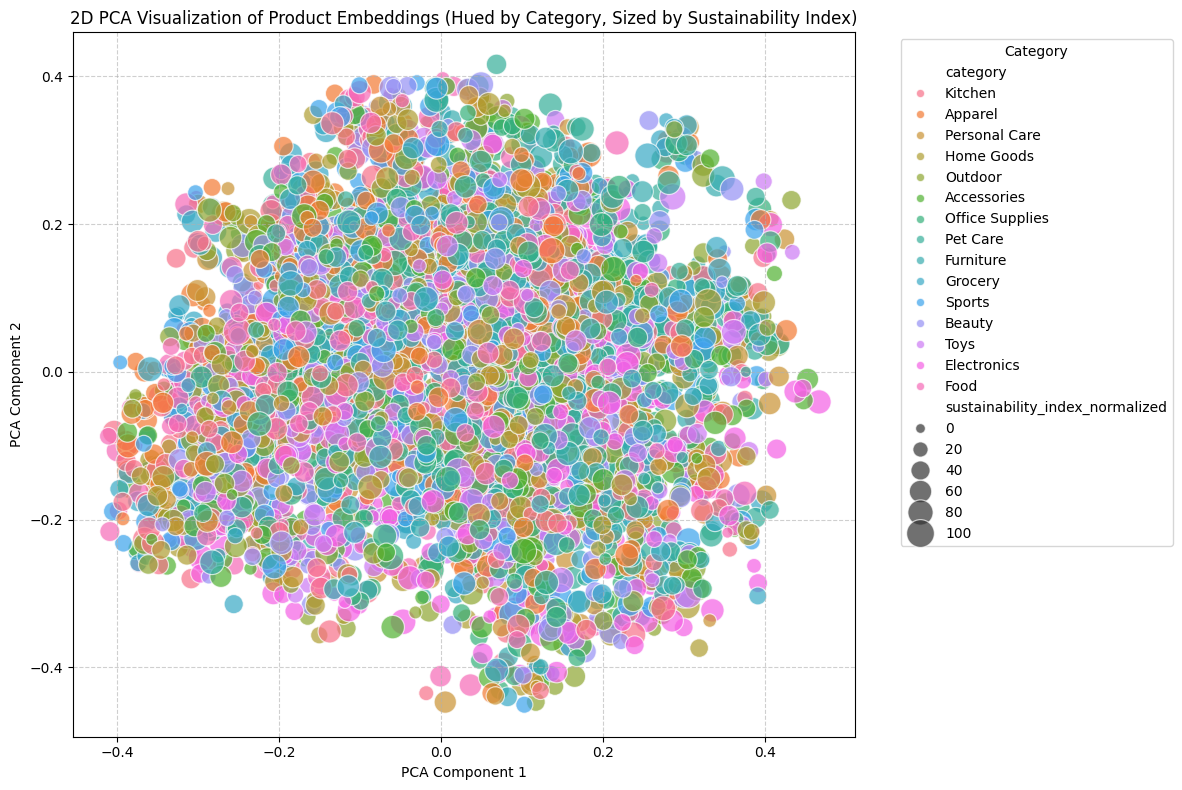

In [26]:
if product_embeddings.size > 0 and product_embeddings.shape[1] > 2:
    print("Performing PCA for visualization...")
    # Reduce dimensions to 2 for plotting
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(product_embeddings)

    # Create a DataFrame for easy plotting
    embeddings_df = pd.DataFrame(embeddings_2d, columns=['PCA1', 'PCA2'])
    embeddings_df['product_name'] = df['product_name']
    embeddings_df['category'] = df['category']
    embeddings_df['sustainability_index_normalized'] = df['sustainability_index_normalized']

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='PCA1',
        y='PCA2',
        hue='category',
        size='sustainability_index_normalized',
        sizes=(50, 400), # Adjust min/max size for better visualization
        alpha=0.7,
        data=embeddings_df
    )
    # Add product names as annotations if there are not too many products
    if len(embeddings_df) < 50:
        for i, row in embeddings_df.iterrows():
            plt.annotate(row['product_name'], (row['PCA1'] + 0.01, row['PCA2'] + 0.01), fontsize=8)

    plt.title('2D PCA Visualization of Product Embeddings (Hued by Category, Sized by Sustainability Index)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Embeddings not available or not enough dimensions for PCA visualization.")

## 6. Save Embeddings and Model Configuration

In [27]:
if product_embeddings.size > 0:
    # Save the generated embeddings
    np.save('product_embeddings.npy', product_embeddings)
    print("Product embeddings saved as 'product_embeddings.npy'")

    # Save the embedding model configuration (optional, but good for reproducibility)
    embedding_model.save('sentence_transformer_model_config')
    print("SentenceTransformer model configuration saved to 'sentence_transformer_model_config'.")

    # IMPORTANT: Re-save the DataFrame with the 'product_description' column
    # This ensures that 'Part 4' can correctly load this column.
    df.to_csv('processed_products.csv', index=False)
    print("Processed dataset (including product_description) saved as 'processed_products.csv'")
else:
    print("No embeddings to save.")

Product embeddings saved as 'product_embeddings.npy'


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SentenceTransformer model configuration saved to 'sentence_transformer_model_config'.
Processed dataset (including product_description) saved as 'processed_products.csv'


In [28]:
np.save(
    f"{SAVE_DIR}/product_embeddings.npy",
    product_embeddings
)

# Part 1 – Data Preparation and Sustainability Analysis for an AI-powered Sustainable Product Recommendation System

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/Sustainable_AI_Project"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Google Drive connected.")
print(SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected.
/content/drive/MyDrive/Sustainable_AI_Project


In [4]:
import tensorflow as tf

print("TensorFlow Version :", tf.__version__)

print("GPU Available :", tf.config.list_physical_devices('GPU'))

TensorFlow Version : 2.20.0
GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
!pip install -q \
sentence-transformers \
faiss-cpu \
transformers \
datasets \
accelerate \
tensorflow \
keras \
torch \
torchvision \
torchaudio \
pandas \
numpy \
matplotlib \
plotly \
seaborn \
scikit-learn \
tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.8 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm

# Check for GPU availability
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

Using GPU: Tesla T4


## 1. Setup and Library Imports

## 2. Data Loading

In [7]:
# Load the sustainable product dataset
# IMPORTANT: Replace 'sustainable_products.csv' with the actual path to your dataset.
try:
    df = pd.read_csv('sustainable_products_5000.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("""Error: 'sustainable_products.csv' not found. Please upload the file or provide the correct path.
          For demonstration, creating a dummy DataFrame.""")
    # Create a dummy DataFrame for demonstration if file not found
    data = {
        'product_id': range(1, 11),
        'product_name': [f'Product {i}' for i in range(1, 11)],
        'category': ['Apparel', 'Home Goods', 'Apparel', 'Electronics', 'Home Goods', 'Apparel', 'Food', 'Electronics', 'Food', 'Home Goods'],
        'material': ['Organic Cotton', 'Bamboo', 'Recycled Polyester', 'Recycled Plastic', 'Glass', 'Linen', 'Local Produce', 'Bio-Plastic', 'Organic Grains', 'Reclaimed Wood'],
        'carbon_footprint_g': [1500, 800, 1200, 2500, 300, 900, 100, 1800, 50, 700],
        'water_usage_L': [5000, 300, 2000, 1000, 50, 800, 20, 400, 10, 150],
        'recycled_content_pct': [80, 50, 95, 70, 10, 0, 0, 60, 0, 100],
        'packaging_type': ['Recyclable Cardboard', 'Compostable', 'Plastic Film', 'Recyclable Cardboard', 'Glass Jar', 'Plastic Bag', 'None', 'Recyclable Cardboard', 'Paper Bag', 'None'],
        'certifications': ['GOTS', 'FSC', 'GRS', 'Energy Star', None, 'OEKO-TEX', 'Organic', None, 'Fair Trade', 'FSC'],
        'price_usd': [25.99, 45.00, 32.50, 120.00, 15.00, 60.00, 5.00, 85.00, 3.50, 55.00],
        'manufacturer_country': ['India', 'China', 'Vietnam', 'China', 'USA', 'Portugal', 'USA', 'Germany', 'France', 'Brazil']
    }
    df = pd.DataFrame(data)


display(df.head())

Dataset loaded successfully.


,product_id,product_name,category,material,carbon_footprint_g,water_usage_L,recycled_content_pct,packaging_type,certifications,price_usd,manufacturer_country
0,1,Eco Cork Lunch Box,Kitchen,Cork,1878,1153,94,Compostable,NaN,371.36,Finland
1,2,Compact Hemp Container,Apparel,Hemp,294,777,27,Glass Jar,Rainforest Alliance,302.59,Finland
2,3,Bio Glass Mouse,Personal Care,Glass,1855,3689,75,Biodegradable Pouch,GOTS,380.36,China
3,4,Green Linen Lunch Box,Home Goods,Linen,1813,7851,97,Cloth Bag,FSC,49.99,France
4,5,Earth Jute Mat,Outdoor,Jute,2216,6621,5,Plastic Film,Rainforest Alliance,65.90,Norway


## 3. Data Cleaning and Preprocessing

### 3.1 Handle Missing Values

In [8]:
# Display missing values before handling
print("Missing values before handling:")
display(df.isnull().sum())

# --- Implement your missing value handling strategy here ---
# Example: Fill numerical NaNs with median, categorical NaNs with mode or a placeholder
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object': # Categorical
            df[col] = df[col].fillna('Unknown') # Or df[col].mode()[0]
        elif df[col].dtype in ['int64', 'float64']: # Numerical
            df[col] = df[col].fillna(df[col].median())

# Display missing values after handling
print("\nMissing values after handling:")
display(df.isnull().sum())

Missing values before handling:


,0
product_id,0
product_name,0
category,0
material,0
carbon_footprint_g,0
water_usage_L,0
recycled_content_pct,0
packaging_type,0
certifications,492
price_usd,0



Missing values after handling:


,0
product_id,0
product_name,0
category,0
material,0
carbon_footprint_g,0
water_usage_L,0
recycled_content_pct,0
packaging_type,0
certifications,0
price_usd,0


### 3.2 Remove Duplicates

In [9]:
print(f"Number of rows before removing duplicates: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {len(df)}")

Number of rows before removing duplicates: 5000
Number of rows after removing duplicates: 5000


### 3.3 Data Type Conversion

In [10]:
# Check current data types
print("Data types before conversion:")
display(df.info())

# --- Implement specific data type conversions if needed ---
# Example: Converting a column to a specific numeric type or datetime
# df['some_numeric_col'] = pd.to_numeric(df['some_numeric_col'], errors='coerce')
# df['date_column'] = pd.to_datetime(df['date_column'], errors='coerce')

# For this dummy data, types are generally correct, but this is where you'd adjust.

print("\nData types after conversion (if any):")
display(df.info())

Data types before conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            5000 non-null   int64  
 1   product_name          5000 non-null   object 
 2   category              5000 non-null   object 
 3   material              5000 non-null   object 
 4   carbon_footprint_g    5000 non-null   int64  
 5   water_usage_L         5000 non-null   int64  
 6   recycled_content_pct  5000 non-null   int64  
 7   packaging_type        5000 non-null   object 
 8   certifications        5000 non-null   object 
 9   price_usd             5000 non-null   float64
 10  manufacturer_country  5000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 429.8+ KB


None


Data types after conversion (if any):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            5000 non-null   int64  
 1   product_name          5000 non-null   object 
 2   category              5000 non-null   object 
 3   material              5000 non-null   object 
 4   carbon_footprint_g    5000 non-null   int64  
 5   water_usage_L         5000 non-null   int64  
 6   recycled_content_pct  5000 non-null   int64  
 7   packaging_type        5000 non-null   object 
 8   certifications        5000 non-null   object 
 9   price_usd             5000 non-null   float64
 10  manufacturer_country  5000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 429.8+ KB


None

## 4. Exploratory Data Analysis (EDA) and Visualization

### 4.1 Summary Statistics

In [11]:
# Display descriptive statistics for numerical columns
print("Descriptive Statistics for Numerical Features:")
display(df.describe())

# Display value counts for categorical columns
print("\nValue Counts for Categorical Features:")
for col in df.select_dtypes(include='object').columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

Descriptive Statistics for Numerical Features:


,product_id,carbon_footprint_g,water_usage_L,recycled_content_pct,price_usd
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,2507.351000,4004.77520,49.745200,249.639034
std,1443.520003,1427.175623,2319.00713,29.121571,142.156261
min,1.000000,52.000000,10.00000,0.000000,4.090000
25%,1250.750000,1284.000000,2020.75000,25.000000,127.442500
50%,2500.500000,2500.000000,4002.00000,50.000000,247.060000
75%,3750.250000,3730.250000,6015.00000,75.000000,368.557500
max,5000.000000,5000.000000,7999.00000,100.000000,499.980000



Value Counts for Categorical Features:
--- product_name ---
product_name
Sustainable Glass Table                5
Earth Bio Plastic Bag                  5
Recycled Recycled Plastic Chair        5
Pure Hemp Table                        5
Recycled Recycled Aluminum Bag         5
                                      ..
Natural Stainless Steel Notebook       1
Compact Wheat Straw Keyboard           1
Earth Hemp Bottle                      1
Organic Bamboo Bag                     1
Compact Recycled Aluminum Container    1
Name: count, Length: 3386, dtype: int64


--- category ---
category
Office Supplies    356
Personal Care      353
Electronics        351
Pet Care           350
Outdoor            346
Apparel            343
Beauty             338
Grocery            333
Sports             332
Accessories        330
Toys               319
Furniture          317
Home Goods         311
Food               311
Kitchen            310
Name: count, dtype: int64


--- material ---
material
Stainles

### 4.2 Feature Distribution Visualization

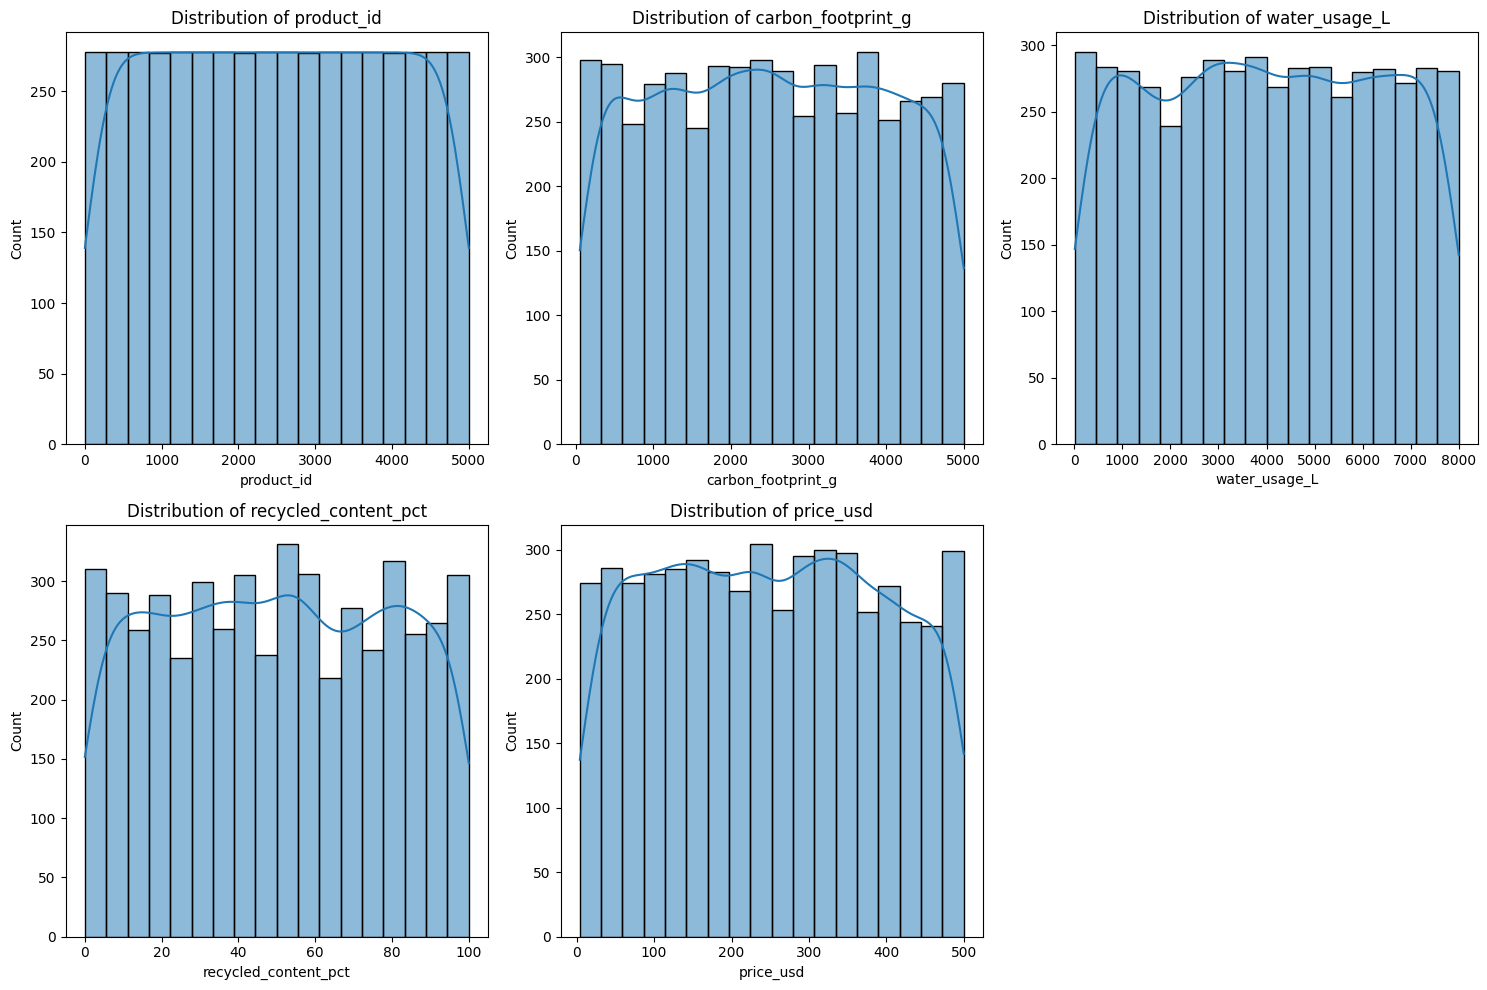

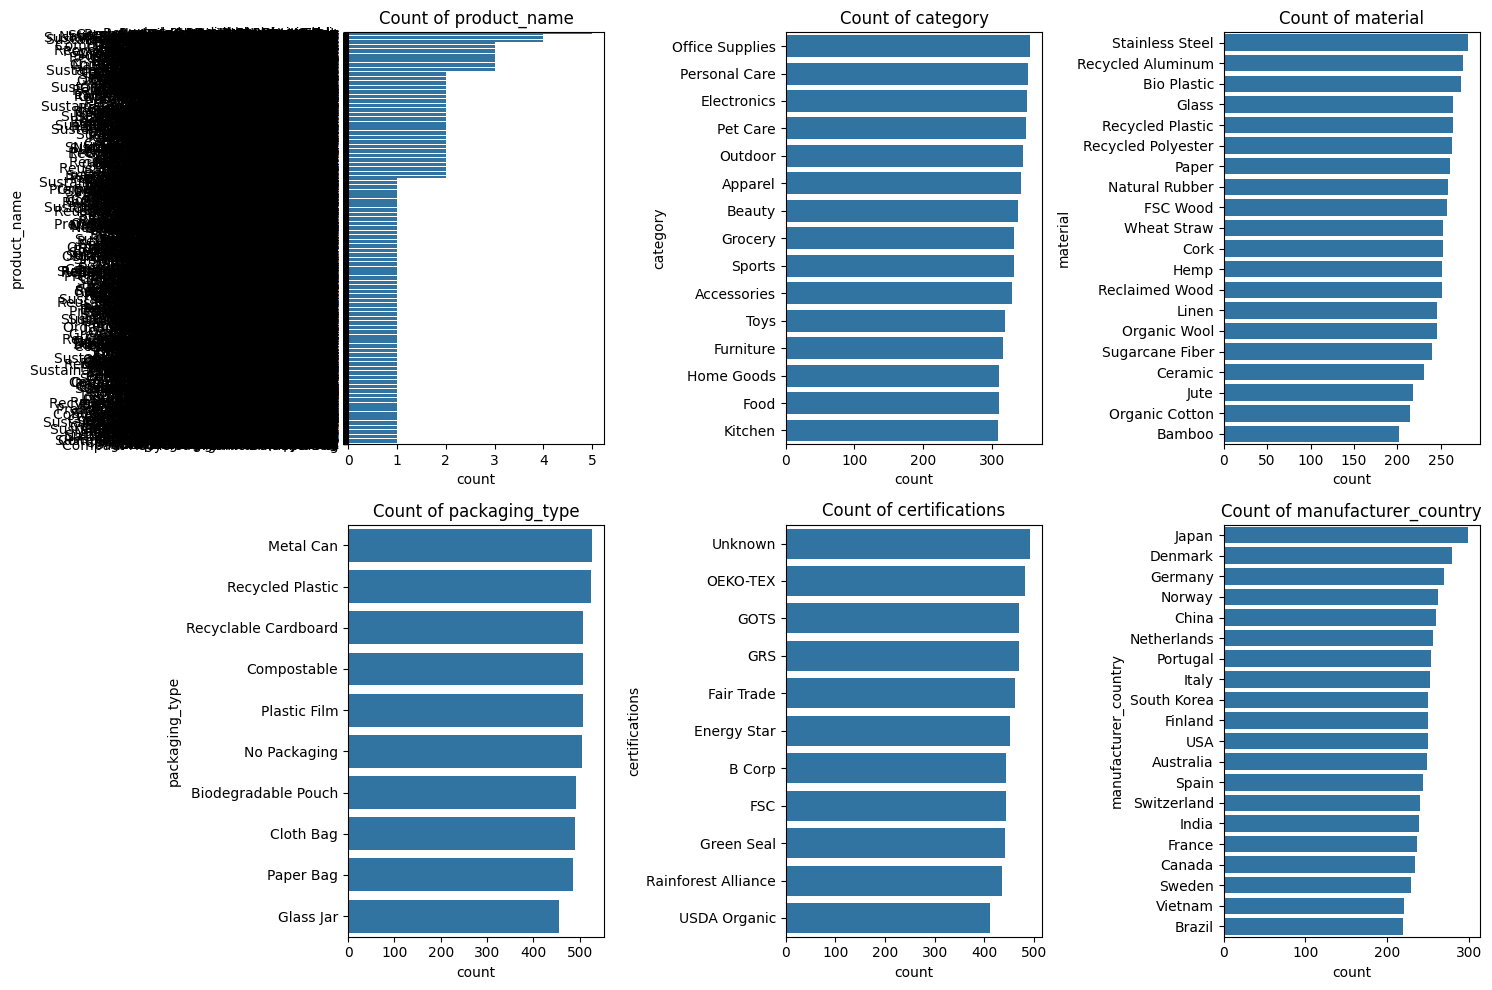

In [12]:
# Visualize distributions of numerical features
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Visualize distributions of categorical features
cat_cols = df.select_dtypes(include='object').columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()

## 5. Feature Engineering: Sustainability Scores

### 5.1 Eco Score (Example: based on material, certifications, water usage)

In [13]:
# Example logic for Eco Score
# This will need to be customized based on your dataset's specific columns and domain knowledge.

def calculate_eco_score(row):
    score = 0
    # Example: Higher score for organic, bamboo, recycled materials
    if 'Organic' in row['material'] or 'Bamboo' in row['material'] or 'Recycled' in row['material']:
        score += 2
    elif 'Glass' in row['material'] or 'Linen' in row['material'] or 'Reclaimed' in row['material']:
        score += 1

    # Example: Boost for certifications
    if 'certifications' in row and pd.notna(row['certifications']):
        if 'GOTS' in row['certifications'] or 'FSC' in row['certifications'] or 'Organic' in row['certifications'] or 'Fair Trade' in row['certifications']:
            score += 1.5
        elif 'GRS' in row['certifications'] or 'OEKO-TEX' in row['certifications']:
            score += 1

    # Example: Inverse relationship with water usage (lower water usage = higher score)
    # Normalizing water usage to contribute negatively to the score
    if 'water_usage_L' in row and pd.notna(row['water_usage_L']):
        # Assuming lower water usage is better, and higher values mean worse for the environment.
        # This requires scaling to a meaningful range; a simple inverse might not be ideal.
        # For now, let's assume a threshold or range. Adjust min/max based on your data.
        max_water_usage = df['water_usage_L'].max() # Use actual max from data
        min_water_usage = df['water_usage_L'].min() # Use actual min from data
        if max_water_usage > min_water_usage: # Avoid division by zero if all values are same
            normalized_water_usage = (row['water_usage_L'] - min_water_usage) / (max_water_usage - min_water_usage)
            score -= normalized_water_usage * 1.5 # Subtract more for higher water usage
        else:
            score -= 0.5 # Default small penalty if all water usage is same

    # Ensure score is not negative and within a reasonable range, e.g., 0-5
    return max(0, min(5, score))

df['eco_score'] = df.apply(calculate_eco_score, axis=1)
display(df[['product_name', 'material', 'certifications', 'water_usage_L', 'eco_score']].head())

,product_name,material,certifications,water_usage_L,eco_score
0,Eco Cork Lunch Box,Cork,Unknown,1153,0.000000
1,Compact Hemp Container,Hemp,Rainforest Alliance,777,0.000000
2,Bio Glass Mouse,Glass,GOTS,3689,1.809238
3,Green Linen Lunch Box,Linen,FSC,7851,1.027788
4,Earth Jute Mat,Jute,Rainforest Alliance,6621,0.000000


### 5.2 Carbon Footprint Score

In [14]:
# Example logic for Carbon Footprint Score
# This often involves an inverse relationship with the carbon footprint metric.

# Assuming 'carbon_footprint_g' exists and lower is better.
def calculate_carbon_footprint_score(row):
    if 'carbon_footprint_g' in row and pd.notna(row['carbon_footprint_g']):
        # Normalize carbon footprint to a 0-1 scale (lower carbon = higher score)
        max_cf = df['carbon_footprint_g'].max()
        min_cf = df['carbon_footprint_g'].min()

        if max_cf == min_cf:
            return 2.5 # Neutral score if all values are the same

        normalized_cf = (row['carbon_footprint_g'] - min_cf) / (max_cf - min_cf)
        # Inverse the normalized value and scale to, e.g., 0-5
        score = (1 - normalized_cf) * 5
        return max(0, min(5, score)) # Ensure score is within 0-5
    return 0

df['carbon_footprint_score'] = df.apply(calculate_carbon_footprint_score, axis=1)
display(df[['product_name', 'carbon_footprint_g', 'carbon_footprint_score']].head())

,product_name,carbon_footprint_g,carbon_footprint_score
0,Eco Cork Lunch Box,1878,3.154810
1,Compact Hemp Container,294,4.755457
2,Bio Glass Mouse,1855,3.178052
3,Green Linen Lunch Box,1813,3.220493
4,Earth Jute Mat,2216,2.813258


### 5.3 Recyclability Score

In [15]:
# Example logic for Recyclability Score
# This could be based on 'recycled_content_pct', 'material', and 'packaging_type'.

def calculate_recyclability_score(row):
    score = 0
    if 'recycled_content_pct' in row and pd.notna(row['recycled_content_pct']):
        score += (row['recycled_content_pct'] / 100) * 2 # Max 2 points for recycled content

    if 'material' in row and pd.notna(row['material']):
        if 'Recycled' in row['material'] or 'Glass' in row['material']:
            score += 1

    if 'packaging_type' in row and pd.notna(row['packaging_type']):
        if 'Recyclable' in row['packaging_type'] or 'Glass Jar' in row['packaging_type'] or 'None' == row['packaging_type']:
            score += 1.5
        elif 'Paper Bag' in row['packaging_type']:
            score += 0.5

    return max(0, min(5, score))

df['recyclability_score'] = df.apply(calculate_recyclability_score, axis=1)
display(df[['product_name', 'recycled_content_pct', 'material', 'packaging_type', 'recyclability_score']].head())

,product_name,recycled_content_pct,material,packaging_type,recyclability_score
0,Eco Cork Lunch Box,94,Cork,Compostable,1.88
1,Compact Hemp Container,27,Hemp,Glass Jar,2.04
2,Bio Glass Mouse,75,Glass,Biodegradable Pouch,2.50
3,Green Linen Lunch Box,97,Linen,Cloth Bag,1.94
4,Earth Jute Mat,5,Jute,Plastic Film,0.10


### 5.4 Packaging Score

In [16]:
# Example logic for Packaging Score
# Based on 'packaging_type' (e.g., compostable, recyclable, minimal).

def calculate_packaging_score(row):
    score = 0
    if 'packaging_type' in row and pd.notna(row['packaging_type']):
        packaging_type = row['packaging_type'].lower()
        if 'none' in packaging_type or 'compostable' in packaging_type:
            score += 5 # Best packaging
        elif 'recyclable cardboard' in packaging_type or 'glass jar' in packaging_type:
            score += 3
        elif 'paper bag' in packaging_type:
            score += 2
        elif 'plastic film' in packaging_type or 'plastic bag' in packaging_type:
            score += 1 # Worst packaging (comparatively)
    return max(0, min(5, score))

df['packaging_score'] = df.apply(calculate_packaging_score, axis=1)
display(df[['product_name', 'packaging_type', 'packaging_score']].head())

,product_name,packaging_type,packaging_score
0,Eco Cork Lunch Box,Compostable,5
1,Compact Hemp Container,Glass Jar,3
2,Bio Glass Mouse,Biodegradable Pouch,0
3,Green Linen Lunch Box,Cloth Bag,0
4,Earth Jute Mat,Plastic Film,1


### 5.5 Sustainability Index (Combined Score)

In [17]:
# Combine individual scores into a single Sustainability Index
# Adjust weights based on importance of each factor.

# Ensure all score columns exist before combining
score_columns = ['eco_score', 'carbon_footprint_score', 'recyclability_score', 'packaging_score']
for col in score_columns:
    if col not in df.columns:
        df[col] = 0 # Default to 0 if a score wasn't calculated

df['sustainability_index'] = (
    df['eco_score'] * 0.3 +
    df['carbon_footprint_score'] * 0.3 +
    df['recyclability_score'] * 0.2 +
    df['packaging_score'] * 0.2
)

# Normalize the final index to a 0-100 scale for easier interpretation
max_index = df['sustainability_index'].max()
min_index = df['sustainability_index'].min()

if max_index > min_index:
    df['sustainability_index_normalized'] = ((df['sustainability_index'] - min_index) / (max_index - min_index)) * 100
else:
    df['sustainability_index_normalized'] = 50 # Default if all indices are the same

display(df[['product_name', 'eco_score', 'carbon_footprint_score', 'recyclability_score', 'packaging_score', 'sustainability_index_normalized']].head())

,product_name,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index_normalized
0,Eco Cork Lunch Box,0.000000,3.154810,1.88,5,60.023460
1,Compact Hemp Container,0.000000,4.755457,2.04,3,62.925384
2,Bio Glass Mouse,1.809238,3.178052,2.50,0,51.584771
3,Green Linen Lunch Box,1.027788,3.220493,1.94,0,42.953484
4,Earth Jute Mat,0.000000,2.813258,0.10,1,27.472965


## 6. Feature Scaling and Encoding

### 6.1 Normalize Numerical Features

In [18]:
# Identify numerical features for normalization (excluding ID, scores which are already scaled)
numerical_features = ['price_usd']
# Add other numerical features that need normalization, e.g., 'carbon_footprint_g', 'water_usage_L' if not already incorporated into scores and still needed as raw features.

# Ensure the numerical_features list contains actual columns present in the DataFrame
existing_numerical_features = [col for col in numerical_features if col in df.columns and df[col].dtype in ['int64', 'float64']]

if existing_numerical_features:
    scaler = MinMaxScaler()
    df[existing_numerical_features] = scaler.fit_transform(df[existing_numerical_features])
    print("Numerical features normalized:", existing_numerical_features)
    display(df[existing_numerical_features].head())
else:
    print("No numerical features found for normalization or they are already scaled/incorporated.")

Numerical features normalized: ['price_usd']


,price_usd
0,0.740628
1,0.601948
2,0.758777
3,0.092561
4,0.124645


### 6.2 Encode Categorical Features

In [19]:
# Identify categorical features for encoding
categorical_features = ['category', 'material', 'packaging_type', 'manufacturer_country', 'certifications']

# Ensure the categorical_features list contains actual columns present in the DataFrame
existing_categorical_features = [col for col in categorical_features if col in df.columns and df[col].dtype == 'object']

if existing_categorical_features:
    # For simplicity, using LabelEncoder. For more complex scenarios, OneHotEncoder might be preferred.
    for col in existing_categorical_features:
        le = LabelEncoder()
        # Handle potential new 'Unknown' category or missing values introduced during cleaning
        df[col] = df[col].astype(str) # Convert to string to avoid issues with mixed types and NaNs
        df[f'{col}_encoded'] = le.fit_transform(df[col])
        print(f"Categorical feature '{col}' encoded.")

    # Display encoded features
    encoded_cols = [f'{col}_encoded' for col in existing_categorical_features]
    display(df[encoded_cols + existing_categorical_features].head())
else:
    print("No categorical features found for encoding.")

Categorical feature 'category' encoded.
Categorical feature 'material' encoded.
Categorical feature 'packaging_type' encoded.
Categorical feature 'manufacturer_country' encoded.
Categorical feature 'certifications' encoded.


,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded,category,material,packaging_type,manufacturer_country,certifications
0,8,3,2,5,10,Kitchen,Cork,Compostable,Finland,Unknown
1,1,6,3,5,8,Apparel,Hemp,Glass Jar,Finland,Rainforest Alliance
2,11,5,0,3,4,Personal Care,Glass,Biodegradable Pouch,China,GOTS
3,7,8,1,6,2,Home Goods,Linen,Cloth Bag,France,FSC
4,10,7,7,12,8,Outdoor,Jute,Plastic Film,Norway,Rainforest Alliance


## 7. Generate Summary Statistics and Final Review

In [20]:
print("Final DataFrame Info:")
display(df.info())

print("\nFinal Descriptive Statistics:")
display(df.describe())

Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   product_id                       5000 non-null   int64  
 1   product_name                     5000 non-null   object 
 2   category                         5000 non-null   object 
 3   material                         5000 non-null   object 
 4   carbon_footprint_g               5000 non-null   int64  
 5   water_usage_L                    5000 non-null   int64  
 6   recycled_content_pct             5000 non-null   int64  
 7   packaging_type                   5000 non-null   object 
 8   certifications                   5000 non-null   object 
 9   price_usd                        5000 non-null   float64
 10  manufacturer_country             5000 non-null   object 
 11  eco_score                        5000 non-null   float64
 12

None


Final Descriptive Statistics:


,product_id,carbon_footprint_g,water_usage_L,recycled_content_pct,price_usd,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index,sustainability_index_normalized,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,2500.500000,2507.351000,4004.77520,49.745200,0.495168,0.922557,2.518845,1.545504,1.380200,1.617561,41.791541,7.017000,9.66440,4.550000,9.446800,5.015000
std,1443.520003,1427.175623,2319.00713,29.121571,0.286669,0.967786,1.442174,0.928176,1.689207,0.698192,18.058903,4.331982,5.75538,2.881173,5.663001,3.154737
min,1.000000,52.000000,10.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001819,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1250.750000,1284.000000,2020.75000,25.000000,0.248750,0.000000,1.283094,0.820000,0.000000,1.109744,28.656728,3.000000,5.00000,2.000000,5.000000,2.000000
50%,2500.500000,2500.000000,4002.00000,50.000000,0.489968,0.691701,2.526273,1.520000,0.000000,1.577100,40.744990,7.000000,10.00000,5.000000,10.000000,5.000000
75%,3750.250000,3730.250000,6015.00000,75.000000,0.734977,1.525019,3.755053,2.080000,3.000000,2.094535,54.128561,11.000000,15.00000,7.000000,14.000000,8.000000
max,5000.000000,5000.000000,7999.00000,100.000000,1.000000,3.495682,5.000000,4.500000,5.000000,3.868014,100.000000,14.000000,19.00000,9.000000,19.000000,10.000000


## 8. Save Processed Dataset

In [21]:
# Save the processed DataFrame to a new CSV file
df.to_csv('processed_products.csv', index=False)
print("Processed dataset saved as 'processed_products.csv'")

print("First 5 rows of the processed dataset:")
display(pd.read_csv('processed_products.csv').head())

Processed dataset saved as 'processed_products.csv'
First 5 rows of the processed dataset:


,product_id,product_name,category,material,carbon_footprint_g,water_usage_L,recycled_content_pct,packaging_type,certifications,price_usd,manufacturer_country,eco_score,carbon_footprint_score,recyclability_score,packaging_score,sustainability_index,sustainability_index_normalized,category_encoded,material_encoded,packaging_type_encoded,manufacturer_country_encoded,certifications_encoded
0,1,Eco Cork Lunch Box,Kitchen,Cork,1878,1153,94,Compostable,Unknown,0.740628,Finland,0.000000,3.154810,1.88,5,2.322443,60.023460,8,3,2,5,10
1,2,Compact Hemp Container,Apparel,Hemp,294,777,27,Glass Jar,Rainforest Alliance,0.601948,Finland,0.000000,4.755457,2.04,3,2.434637,62.925384,1,6,3,5,8
2,3,Bio Glass Mouse,Personal Care,Glass,1855,3689,75,Biodegradable Pouch,GOTS,0.758777,China,1.809238,3.178052,2.50,0,1.996187,51.584771,11,5,0,3,4
3,4,Green Linen Lunch Box,Home Goods,Linen,1813,7851,97,Cloth Bag,FSC,0.092561,France,1.027788,3.220493,1.94,0,1.662484,42.953484,7,8,1,6,2
4,5,Earth Jute Mat,Outdoor,Jute,2216,6621,5,Plastic Film,Rainforest Alliance,0.124645,Norway,0.000000,2.813258,0.10,1,1.063977,27.472965,10,7,7,12,8


In [22]:
df.to_csv(
    f"{SAVE_DIR}/processed_products.csv",
    index=False
)